# Fake data

In [2]:
# Chỉ xóa /kaggle/working khi chủ động cần dọn file cũ.
# !rm -rf /kaggle/working/*


In [3]:
!pip install -q h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.6 MB/s eta 0:00:0000:0100:01


In [4]:
# !pip uninstall -y lightgbm

# !pip install --no-cache-dir \
#     --no-binary lightgbm \
#     --config-settings=cmake.define.USE_CUDA=ON \
#     lightgbm

In [5]:
#check version
import h3
import numpy as np
import pandas as pd
import pyarrow as pa
import scipy

print("h3:", h3.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("pyarrow:", pa.__version__)
print("scipy:", scipy.__version__)

h3: 4.5.0
numpy: 2.0.2
pandas: 2.3.3
pyarrow: 24.0.0
scipy: 1.16.3


In [6]:
from pathlib import Path
import gc

import h3
import holidays
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from scipy.ndimage import gaussian_filter1d
from scipy.optimize import least_squares
try:
    from IPython.display import display
except ImportError:
    def display(frame):
        print(frame.to_string(index=False))

SEED = 20260916
LOCAL_TIMEZONE = "Asia/Ho_Chi_Minh"

LOCAL_START = pd.Timestamp(
    "2026-05-01 00:00:00",
    tz=LOCAL_TIMEZONE,
)
LOCAL_END = pd.Timestamp(
    "2026-09-11 00:00:00",
    tz=LOCAL_TIMEZONE,
)

# Lịch nghỉ lễ Việt Nam. observed=True bao gồm ngày nghỉ bù do thư viện cung cấp.
VN_HOLIDAYS = holidays.country_holidays(
    "VN",
    years=range(LOCAL_START.year, LOCAL_END.year + 1),
    observed=True,
    language="vi",
)


VALID_MODES = ("Car", "Motorcycle")

# Mỗi ngày có 144 bucket 10 phút
SLOTS_PER_DAY = 24 * 6
N_DAYS = (LOCAL_END - LOCAL_START).days
N_TIME = N_DAYS * SLOTS_PER_DAY

ALL_LOCAL_DATES = pd.date_range(
    start=LOCAL_START.normalize(),
    periods=N_DAYS,
    freq="D",
)

IS_HOLIDAY_BY_DAY = np.asarray(
    [int(ts.date() in VN_HOLIDAYS) for ts in ALL_LOCAL_DATES],
    dtype=np.int8,
)

HOLIDAY_NAME_BY_DAY = np.asarray(
    [VN_HOLIDAYS.get(ts.date(), "") for ts in ALL_LOCAL_DATES],
    dtype=object,
)

HOLIDAY_DATES_IN_RANGE = pd.DataFrame({
    "date": ALL_LOCAL_DATES.date,
    "is_holiday": IS_HOLIDAY_BY_DAY,
    "holiday_name": HOLIDAY_NAME_BY_DAY,
})
HOLIDAY_DATES_IN_RANGE = HOLIDAY_DATES_IN_RANGE[
    HOLIDAY_DATES_IN_RANGE["is_holiday"] == 1
].reset_index(drop=True)

print("Holiday dates inside fake-data range:")
display(HOLIDAY_DATES_IN_RANGE)

HCM_CENTER = (10.7769, 106.7009)
H3_RESOLUTION = 7
H3_K_RING = 8

# Preserve the notebook's existing 217 H3 IDs and spatial footprint. A radius
# around the city center does not certify membership of the HCMC boundary;
# replace COMMON_HEX with a verified operations H3 list if one is available.
HCM_CENTER_HEX = h3.latlng_to_cell(
    *HCM_CENTER,
    H3_RESOLUTION,
)

COMMON_HEX = sorted(
    h3.grid_disk(HCM_CENTER_HEX, H3_K_RING)
)

N_HEX = len(COMMON_HEX)


def km_to(point, lat, lng):
    """Local equirectangular distance (adequate for this ~40 km footprint)."""
    return np.hypot(
        (lat - point[0]) * 111.1,
        (lng - point[1]) * 109.2,
    )


def make_hex_metadata():
    """Geographic priors: these area labels are synthetic, not actual POIs."""
    coords = np.asarray([h3.cell_to_latlng(h) for h in COMMON_HEX])
    lat, lng = coords[:, 0], coords[:, 1]
    anchor = {
        "central": (10.7769, 106.7009),
        "airport": (10.8188, 106.6519),
        "west": (10.7510, 106.6550),
        "south": (10.7295, 106.7219),
        "east": (10.8506, 106.7719),
    }
    distance = {key: km_to(value, lat, lng) for key, value in anchor.items()}
    near = {key: np.exp(-0.5 * (d / 3.8) ** 2) for key, d in distance.items()}
    outer = np.minimum.reduce([distance[key] for key in anchor]) > 6.2
    zone_score = np.column_stack([
        1.40 * near["central"],
        1.20 * near["airport"],
        near["west"],
        near["south"],
        near["east"],
    ])
    zone = np.array(["central", "airport", "west", "south", "east"], dtype=object)[
        zone_score.argmax(axis=1)
    ]
    zone[outer] = "outer"
    # A shared coarse H3 effect keeps neighboring hexes more similar.
    parent = [h3.cell_to_parent(h, 5) for h in COMMON_HEX]
    parent_code = pd.factorize(np.asarray(parent), sort=True)[0]
    rng = np.random.default_rng(SEED + 402)
    coarse = rng.normal(0, 0.18, size=parent_code.max() + 1)
    local = rng.normal(0, 0.075, size=N_HEX)
    spatial_log = (
        0.72 * near["central"]
        + 0.38 * near["airport"]
        + 0.26 * near["west"]
        + 0.24 * near["south"]
        + 0.22 * near["east"]
        - 0.018 * distance["central"]
        - 0.43 * outer
        + coarse[parent_code]
        + local
    )
    return pd.DataFrame({
        "hex_id_7": COMMON_HEX,
        "center_lat": lat,
        "center_lng": lng,
        "synthetic_zone": zone,
        "spatial_log_weight": spatial_log.astype(np.float32),
    })


HEX_METADATA = make_hex_metadata()
ZONE = HEX_METADATA["synthetic_zone"].to_numpy()
SPATIAL_LOG_WEIGHT = HEX_METADATA["spatial_log_weight"].to_numpy()

# Zero chỉ xuất hiện hiếm ở các active hex. Tỷ lệ nhỏ để không phá
# n/mean/std/p50/p95/p99/max được hiệu chỉnh từ thống kê thực.
ZERO_RATE_BY_MODE = {
    "Car": 0.003,         # khoảng 0.30% số bucket
    "Motorcycle": 0.002,  # khoảng 0.20% số bucket
}
ZERO_CANDIDATE_SHARE = 0.26

CONTRACT = {
    "Car": {
        "n": 2_863_718,
        "mean": 9.75,
        "std": 17.37,
        "p50": 4,
        "p95": 40,
        "p99": 86,
        "max": 1_000,
        "bucket_rows": [
            615_688,
            1_525_941,
            618_033,
            104_056,
        ],
        "bucket_volume_pct": [
            0.022,
            0.227,
            0.454,
            0.298,
        ],
    },
    "Motorcycle": {
        "n": 2_540_812,
        "mean": 16.96,
        "std": 29.29,
        "p50": 6,
        "p95": 73,
        "p99": 144,
        "max": 914,
        "bucket_rows": [
            480_508,
            1_069_539,
            770_448,
            220_316,
        ],
        "bucket_volume_pct": [
            0.011,
            0.108,
            0.400,
            0.481,
        ],
    },
}

OUTPUT_ROOT = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path.cwd()
)

OUTPUT_DIR = OUTPUT_ROOT / "xanhsm_smooth_bucket_v9"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMAND_PATH = (
    OUTPUT_DIR
    / "xanhsm_hcm_smooth_10min_bucket_v9.parquet"
)

# ------------------------------------------------------------
# HÀM TẠO PHÂN PHỐI DEMAND ĐÚNG CONTRACT
# ------------------------------------------------------------
def largest_remainder_counts(weights, total):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    expected = weights * total
    counts = np.floor(expected).astype(np.int64)

    remainder = total - counts.sum()

    if remainder:
        order = np.argsort(
            -(expected - counts),
            kind="stable",
        )
        counts[order[:remainder]] += 1

    return counts


def bucket_counts_for_mode(mode):
    spec = CONTRACT[mode]

    counts = np.asarray(
        spec["bucket_rows"],
        dtype=np.int64,
    ).copy()

    # Motorcycle thiếu một dòng trong thống kê nguồn
    counts[-1] += spec["n"] - counts.sum()

    return counts


def maxent_discrete(
    support,
    feature_functions,
    targets,
):
    support = np.asarray(support, dtype=float)

    features = np.column_stack([
        function(support)
        for function in feature_functions
    ])

    targets = np.asarray(targets, dtype=float)

    def probabilities(theta):
        logits = features @ theta
        logits -= logits.max()

        probability = np.exp(logits)
        return probability / probability.sum()

    result = least_squares(
        lambda theta:
        probabilities(theta) @ features - targets,
        np.zeros(features.shape[1]),
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
        max_nfev=20_000,
    )

    probability = probabilities(result.x)

    error = np.max(
        np.abs(
            probability @ features - targets
        )
    )

    if error > 2e-7:
        raise RuntimeError(
            f"Calibration failed: {error}"
        )

    return probability


def calibrated_segments(mode):
    spec = CONTRACT[mode]

    n = spec["n"]
    mean = float(spec["mean"])
    std = float(spec["std"])
    max_value = int(spec["max"])

    bucket_counts = bucket_counts_for_mode(mode)
    bucket_probability = bucket_counts / n

    exact_one_share = (
        bucket_counts[0] / (n * mean)
    )

    remaining_share = np.asarray(
        spec["bucket_volume_pct"][1:],
        dtype=float,
    )

    remaining_share *= (
        1.0 - exact_one_share
    ) / remaining_share.sum()

    volume_share = np.r_[
        exact_one_share,
        remaining_share,
    ]

    conditional_mean = (
        mean
        * volume_share
        / bucket_probability
    )

    delta = max(0.0002, 3.0 / n)

    supports = [
        np.asarray([1], dtype=np.int16)
    ]
    probabilities = [
        np.asarray([1.0])
    ]

    # Bucket 2–9
    q50 = int(spec["p50"])
    support = np.arange(2, 10)

    probability = maxent_discrete(
        support,
        [
            lambda x: x / 9.0,
            lambda x:
            (x <= q50 - 1).astype(float),
            lambda x:
            (x <= q50).astype(float),
        ],
        [
            conditional_mean[1] / 9.0,
            (
                0.50
                - delta
                - bucket_probability[0]
            ) / bucket_probability[1],
            (
                0.50
                + delta
                - bucket_probability[0]
            ) / bucket_probability[1],
        ],
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    # Bucket 10–49
    support = np.arange(10, 50)

    functions = [
        lambda x: x / 49.0
    ]
    targets = [
        conditional_mean[2] / 49.0
    ]

    q95 = int(spec["p95"])

    if q95 <= 49:
        functions.extend([
            lambda x:
            (x <= q95 - 1).astype(float),
            lambda x:
            (x <= q95).astype(float),
        ])

        targets.extend([
            (
                0.95
                - delta
                - bucket_probability[:2].sum()
            ) / bucket_probability[2],
            (
                0.95
                + delta
                - bucket_probability[:2].sum()
            ) / bucket_probability[2],
        ])

    probability = maxent_discrete(
        support,
        functions,
        targets,
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    # Bucket 50+
    population_second_moment = (
        std**2 * (n - 1) / n
        + mean**2
    )

    lower_second_moment = sum(
        bucket_probability[index]
        * float(
            probabilities[index]
            @ supports[index].astype(float) ** 2
        )
        for index in range(3)
    )

    tail_second_moment = (
        population_second_moment
        - lower_second_moment
    ) / bucket_probability[3]

    support = np.arange(
        50,
        max_value + 1,
    )

    functions = [
        lambda x: x / max_value,
        lambda x:
        (x / max_value) ** 2,
    ]

    targets = [
        conditional_mean[3] / max_value,
        tail_second_moment / max_value**2,
    ]

    for percentile, quantile_value in [
        (0.95, int(spec["p95"])),
        (0.99, int(spec["p99"])),
    ]:
        if quantile_value >= 50:
            functions.extend([
                lambda x, q=quantile_value:
                (x <= q - 1).astype(float),
                lambda x, q=quantile_value:
                (x <= q).astype(float),
            ])

            targets.extend([
                (
                    percentile
                    - delta
                    - bucket_probability[:3].sum()
                ) / bucket_probability[3],
                (
                    percentile
                    + delta
                    - bucket_probability[:3].sum()
                ) / bucket_probability[3],
            ])

    probability = maxent_discrete(
        support,
        functions,
        targets,
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    return (
        bucket_counts,
        supports,
        probabilities,
    )


def repair_integer_moments(values, mode):
    spec = CONTRACT[mode]

    max_value = int(spec["max"])
    q99 = int(spec["p99"])

    counts = np.bincount(
        values.astype(np.int64),
        minlength=max_value + 1,
    ).astype(np.int64)

    support = np.arange(
        max_value + 1,
        dtype=np.int64,
    )

    n = counts.sum()

    target_sum = int(
        np.rint(n * spec["mean"])
    )

    target_sumsq_float = (
        (n - 1) * spec["std"] ** 2
        + target_sum**2 / n
    )

    target_sumsq = int(
        np.rint(target_sumsq_float)
    )

    if (target_sumsq - target_sum) % 2:
        candidates = (
            target_sumsq - 1,
            target_sumsq + 1,
        )

        target_sumsq = min(
            candidates,
            key=lambda x:
            abs(x - target_sumsq_float),
        )

    current_sum = int(counts @ support)
    sum_deficit = target_sum - current_sum

    if sum_deficit > 0:
        for value in range(
            q99 + 1,
            max_value,
        ):
            if sum_deficit == 0:
                break

            move = min(
                sum_deficit,
                int(counts[value]),
            )

            counts[value] -= move
            counts[value + 1] += move
            sum_deficit -= move

    elif sum_deficit < 0:
        remaining = -sum_deficit

        for value in range(
            max_value,
            q99 + 1,
            -1,
        ):
            if remaining == 0:
                break

            movable = int(counts[value])

            if value == max_value:
                movable = max(
                    0,
                    movable - 1,
                )

            move = min(
                remaining,
                movable,
            )

            counts[value] -= move
            counts[value - 1] += move
            remaining -= move

        sum_deficit = -remaining

    if sum_deficit != 0:
        raise RuntimeError(
            f"Cannot repair mean for {mode}"
        )

    current_sumsq = int(
        counts @ (support * support)
    )

    square_deficit = (
        target_sumsq - current_sumsq
    )

    iterations = 0

    while square_deficit > 0:
        iterations += 1

        if iterations > 100_000:
            break

        max_gap = square_deficit // 2 - 1

        if max_gap < 1:
            break

        available_low = (
            np.flatnonzero(
                counts[q99 + 2:max_value] > 0
            )
            + q99
            + 2
        )

        available_high = (
            np.flatnonzero(
                counts[q99 + 1:max_value] > 0
            )
            + q99
            + 1
        )

        best = None

        for low in available_low:
            high_limit = min(
                max_value - 1,
                int(low) + max_gap,
            )

            candidates = available_high[
                (available_high > low)
                & (available_high <= high_limit)
            ]

            if len(candidates):
                high = int(candidates[-1])
                gap = high - int(low)

                if best is None or gap > best[0]:
                    best = (
                        gap,
                        int(low),
                        high,
                    )

        if best is None:
            break

        gap, low, high = best
        delta_per_pair = 2 * gap + 2

        move = min(
            int(counts[low]),
            int(counts[high]),
            square_deficit // delta_per_pair,
        )

        if move <= 0:
            break

        counts[low] -= move
        counts[low - 1] += move
        counts[high] -= move
        counts[high + 1] += move

        square_deficit -= (
            move * delta_per_pair
        )

    while square_deficit < 0:
        iterations += 1

        if iterations > 100_000:
            break

        remaining = -square_deficit
        max_gap = remaining // 2 + 1

        if max_gap < 2:
            break

        available_low = (
            np.flatnonzero(
                counts[q99 + 1:max_value] > 0
            )
            + q99
            + 1
        )

        high_capacity = counts.copy()
        high_capacity[max_value] = max(
            0,
            high_capacity[max_value] - 1,
        )

        available_high = (
            np.flatnonzero(
                high_capacity[
                    q99 + 2:max_value + 1
                ] > 0
            )
            + q99
            + 2
        )

        best = None

        for low in available_low:
            high_limit = min(
                max_value,
                int(low) + max_gap,
            )

            candidates = available_high[
                (available_high >= low + 2)
                & (available_high <= high_limit)
            ]

            if len(candidates):
                high = int(candidates[-1])
                gap = high - int(low)

                if best is None or gap > best[0]:
                    best = (
                        gap,
                        int(low),
                        high,
                    )

        if best is None:
            break

        gap, low, high = best
        delta_per_pair = 2 * gap - 2

        movable_high = int(counts[high])

        if high == max_value:
            movable_high = max(
                0,
                movable_high - 1,
            )

        move = min(
            int(counts[low]),
            movable_high,
            remaining // delta_per_pair,
        )

        if move <= 0:
            break

        counts[low] -= move
        counts[low + 1] += move
        counts[high] -= move
        counts[high - 1] += move

        square_deficit += (
            move * delta_per_pair
        )

    actual_sum = int(counts @ support)
    actual_sumsq = int(
        counts @ (support * support)
    )

    if (
        actual_sum != target_sum
        or actual_sumsq != target_sumsq
    ):
        raise RuntimeError(
            f"Moment repair failed for {mode}"
        )

    return np.repeat(
        support,
        counts,
    ).astype(np.int16)


def create_calibrated_marks(mode, rng):
    spec = CONTRACT[mode]
    n = spec["n"]

    (
        bucket_counts,
        supports,
        probabilities,
    ) = calibrated_segments(mode)

    pieces = []

    for count, support, probability in zip(
        bucket_counts,
        supports,
        probabilities,
    ):
        value_counts = largest_remainder_counts(
            probability,
            int(count),
        )

        pieces.append(
            np.repeat(
                support,
                value_counts,
            ).astype(np.int16)
        )

    values = np.concatenate(pieces)

    max_value = int(spec["max"])

    if not np.any(values == max_value):
        tail_start = bucket_counts[:3].sum()
        tail = values[tail_start:]

        replacement_value = int(
            np.argmax(
                np.bincount(
                    tail.astype(np.int64)
                )
            )
        )

        candidate = np.flatnonzero(
            tail == replacement_value
        )[0]

        tail[candidate] = max_value
        values[tail_start:] = tail

    # Đổi một phần rất nhỏ demand=1 thành demand=0. Sau đó repair lại
    # tổng và tổng bình phương nên mean/std mục tiêu vẫn được giữ.
    zero_count = int(np.rint(n * ZERO_RATE_BY_MODE[mode]))
    one_positions = np.flatnonzero(values == 1)

    if zero_count > len(one_positions):
        raise RuntimeError(
            f"Not enough demand=1 rows to create zeros for {mode}"
        )

    zero_mark_positions = rng.choice(
        one_positions,
        size=zero_count,
        replace=False,
    )
    values[zero_mark_positions] = 0

    values = repair_integer_moments(
        values,
        mode,
    )

    rng.shuffle(values)

    assert len(values) == n
    return values


def assign_marks_with_sparse_zeros(
    marks,
    propensity,
    hex_index,
    time_index,
    rng,
):
    """Gán marks theo propensity và không để zero liên tiếp/cùng hex."""
    n_rows = len(marks)
    zero_count = int(np.count_nonzero(marks == 0))

    if zero_count == 0:
        order = np.argsort(propensity, kind="stable")
        demand = np.empty(n_rows, dtype=np.int16)
        demand[order] = np.sort(marks)
        return demand

    # Zero is sparse globally, mostly overnight in low-activity cells;
    # choose within the bottom propensity band so zero never lands at a peak.
    candidate_count = min(
        n_rows,
        max(
            zero_count * 20,
            int(np.ceil(n_rows * ZERO_CANDIDATE_SHARE)),
        ),
    )

    low_candidates = np.argpartition(
        propensity,
        candidate_count - 1,
    )[:candidate_count]
    slot = time_index[low_candidates] % SLOTS_PER_DAY
    overnight = (slot < 30) | (slot >= 138)
    night_candidates = low_candidates[overnight]
    other_candidates = low_candidates[~overnight]
    rng.shuffle(night_candidates)
    rng.shuffle(other_candidates)

    selected = []
    selected_keys = set()

    night_target = int(np.rint(0.85 * zero_count))
    for candidates, target in (
        (night_candidates, night_target),
        (other_candidates, zero_count),
        (night_candidates, zero_count),
    ):
        if len(selected) >= zero_count:
            break
        for row_index in candidates:
            hex_value = int(hex_index[row_index])
            time_value = int(time_index[row_index])
            key = hex_value * N_TIME + time_value
            if key in selected_keys or key - 1 in selected_keys or key + 1 in selected_keys:
                continue
            selected.append(int(row_index))
            selected_keys.add(key)
            if len(selected) >= target:
                break

    if len(selected) != zero_count:
        raise RuntimeError(
            f"Cannot place sparse zeros: selected={len(selected)}, "
            f"target={zero_count}, night_candidates={len(night_candidates)}, "
            f"other_candidates={len(other_candidates)}"
        )

    zero_positions = np.asarray(selected, dtype=np.int64)
    zero_mask = np.zeros(n_rows, dtype=bool)
    zero_mask[zero_positions] = True

    demand = np.empty(n_rows, dtype=np.int16)
    demand[zero_positions] = 0

    positive_positions = np.flatnonzero(~zero_mask)
    positive_order = positive_positions[
        np.argsort(
            propensity[positive_positions],
            kind="stable",
        )
    ]
    demand[positive_order] = np.sort(marks[marks > 0])

    return demand


def validate_generated_demand(
    demand,
    mode,
    hex_index,
    time_index,
):
    """Fail-fast nếu zero hoặc thống kê sinh ra lệch contract thực."""
    spec = CONTRACT[mode]
    expected_zero_count = int(
        np.rint(spec["n"] * ZERO_RATE_BY_MODE[mode])
    )

    actual_quantiles = np.quantile(
        demand,
        [0.50, 0.95, 0.99],
    )

    if len(demand) != spec["n"]:
        raise AssertionError(f"Invalid n for {mode}")
    if not np.isclose(demand.mean(), spec["mean"], atol=5e-7):
        raise AssertionError(f"Invalid mean for {mode}")
    if not np.isclose(demand.std(ddof=1), spec["std"], atol=5e-7):
        raise AssertionError(f"Invalid std for {mode}")
    if not np.array_equal(
        actual_quantiles,
        [spec["p50"], spec["p95"], spec["p99"]],
    ):
        raise AssertionError(f"Invalid quantiles for {mode}")
    if int(demand.max()) != spec["max"]:
        raise AssertionError(f"Invalid max for {mode}")
    if int(np.count_nonzero(demand == 0)) != expected_zero_count:
        raise AssertionError(f"Invalid zero count for {mode}")

    slot = time_index % SLOTS_PER_DAY
    zero = demand == 0
    overnight = (slot < 30) | (slot >= 138)
    if zero.any() and np.mean(overnight[zero]) < 0.80:
        raise AssertionError(f"Too few overnight zero rows for {mode}")
    if np.mean(demand[(slot >= 42) & (slot < 54)]) <= 2 * np.mean(
        demand[(slot >= 6) & (slot < 24)]
    ):
        raise AssertionError(f"Morning is not above overnight for {mode}")
    if np.mean(demand[(slot >= 102) & (slot < 120)]) <= 2 * np.mean(
        demand[(slot >= 6) & (slot < 24)]
    ):
        raise AssertionError(f"Evening is not above overnight for {mode}")
    valid_neighbors = (np.diff(hex_index) == 0) & (np.diff(time_index) == 1)
    if valid_neighbors.mean() < 0.995:
        raise AssertionError(f"Too many holes in observed cell histories for {mode}")

    actual_bucket_rows = np.asarray([
        np.count_nonzero((demand >= 0) & (demand <= 1)),
        np.count_nonzero((demand >= 2) & (demand <= 9)),
        np.count_nonzero((demand >= 10) & (demand <= 49)),
        np.count_nonzero(demand >= 50),
    ])

    if not np.array_equal(
        actual_bucket_rows,
        bucket_counts_for_mode(mode),
    ):
        raise AssertionError(f"Invalid bucket rows for {mode}")

    zero_positions = np.flatnonzero(demand == 0)
    zero_keys = np.sort(
        hex_index[zero_positions].astype(np.int64) * N_TIME
        + time_index[zero_positions].astype(np.int64)
    )

    if len(zero_keys) > 1:
        same_hex = (
            zero_keys[1:] // N_TIME
            == zero_keys[:-1] // N_TIME
        )
        consecutive = same_hex & (np.diff(zero_keys) == 1)

        if np.any(consecutive):
            raise AssertionError(
                f"Consecutive zero buckets detected for {mode}"
            )

# ------------------------------------------------------------
# CHỌN CHÍNH XÁC N VỊ TRÍ HEX × BUCKET
# Mỗi hex có tối đa một đoạn ngày không quan sát, bù nhau giữa các hex.
# ------------------------------------------------------------
def select_bucket_positions(n_rows, rng, mode):
    full_days, remainder = divmod(
        n_rows,
        SLOTS_PER_DAY,
    )
    min_days = 42
    if not N_HEX * min_days <= full_days <= N_HEX * N_DAYS:
        raise ValueError("n_rows cannot support the requested continuous history")

    # This controls observation coverage only; it does not change the
    # frequency of zero within the rows that are actually observed.
    mode_weight = (1.0 if mode == "Car" else 0.91)
    weights = np.exp(mode_weight * (SPATIAL_LOG_WEIGHT - SPATIAL_LOG_WEIGHT.mean()))
    days = np.full(N_HEX, min_days, dtype=np.int32)
    remaining = full_days - int(days.sum())
    while remaining:
        eligible = days < N_DAYS
        proportions = weights[eligible] / weights[eligible].sum()
        extra = np.minimum(N_DAYS - days[eligible], np.floor(remaining * proportions).astype(int))
        if not extra.any():
            indices = np.flatnonzero(eligible)
            priority = np.argsort(-proportions, kind="stable")
            extra[priority[:remaining]] = 1
        days[eligible] += extra
        remaining = full_days - int(days.sum())

    # Spread the missing interval evenly around the circular date axis. This
    # prevents a large artificial loss of hex coverage at the edges of the
    # four-month window; each hex has at most one absence interval.
    permuted_rank = rng.permutation(N_HEX)
    missing_starts = (
        (permuted_rank * N_DAYS // N_HEX)
        + int(rng.integers(0, N_DAYS))
    ) % N_DAYS
    hex_parts = []
    time_parts = []
    observed_days_by_hex = []
    for cell_idx, n_days in enumerate(days):
        missing_length = N_DAYS - int(n_days)
        observed_days = np.flatnonzero(
            ((np.arange(N_DAYS) - missing_starts[cell_idx]) % N_DAYS)
            >= missing_length
        )
        observed_days_by_hex.append(observed_days)
        size = len(observed_days) * SLOTS_PER_DAY
        hex_parts.append(np.full(size, cell_idx, dtype=np.int16))
        time_parts.append((
            np.repeat(observed_days, SLOTS_PER_DAY) * SLOTS_PER_DAY
            + np.tile(np.arange(SLOTS_PER_DAY), len(observed_days))
        ).astype(np.int32))

    if remainder:
        cell_idx = int(rng.choice(np.flatnonzero(days < N_DAYS)))
        obs = np.zeros(N_DAYS, dtype=bool)
        obs[observed_days_by_hex[cell_idx]] = True
        right_edge = np.flatnonzero(obs[:-1] & ~obs[1:])
        if len(right_edge):
            first = (int(right_edge[0]) + 1) * SLOTS_PER_DAY
        else:
            left_edge = np.flatnonzero(~obs[:-1] & obs[1:])
            first = (int(left_edge[0]) + 1) * SLOTS_PER_DAY - remainder
        hex_parts.append(np.full(remainder, cell_idx, dtype=np.int16))
        time_parts.append(np.arange(first, first + remainder, dtype=np.int32))

    hex_index = np.concatenate(hex_parts)
    time_index = np.concatenate(time_parts)
    order = np.lexsort((time_index, hex_index))
    return hex_index[order], time_index[order]


# ------------------------------------------------------------
# QUY LUẬT THỜI GIAN
# ------------------------------------------------------------
def time_profile(mode, time_index, hex_index):
    day_index = time_index // SLOTS_PER_DAY
    slot = time_index % SLOTS_PER_DAY

    hour = slot / 6.0

    day_of_week = (
        LOCAL_START.dayofweek + day_index
    ) % 7

    working_day = day_of_week < 5

    morning = np.exp(
        -0.5 * ((hour - 8.0) / 1.4) ** 2
    )
    lunch = np.exp(
        -0.5 * ((hour - 12.0) / 2.1) ** 2
    )
    evening = np.exp(
        -0.5 * ((hour - 18.0) / 1.6) ** 2
    )
    night = np.exp(
        -0.5 * ((hour - 21.5) / 2.0) ** 2
    )

    if mode == "Car":
        weekday = (
            0.42
            + 1.20 * morning
            + 0.35 * lunch
            + 1.55 * evening
            + 0.18 * night
        )

        weekend = (
            0.52
            + 0.45 * morning
            + 0.85 * lunch
            + 1.00 * evening
            + 0.30 * night
        )
    else:
        weekday = (
            0.45
            + 1.35 * morning
            + 0.48 * lunch
            + 1.70 * evening
            + 0.23 * night
        )

        weekend = (
            0.55
            + 0.55 * morning
            + 0.95 * lunch
            + 1.15 * evening
            + 0.38 * night
        )

    baseline = np.where(
        working_day,
        weekday,
        weekend,
    )
    # Pickup origins can differ across spatial zones; these are heuristics.
    zone = ZONE[hex_index]
    early = np.exp(-0.5 * ((hour - 7.7) / 1.35) ** 2)
    late = np.exp(-0.5 * ((hour - 18.2) / 1.5) ** 2)
    after_dark = np.exp(-0.5 * ((hour - 22.5) / 1.9) ** 2)
    # Airport cells retain activity overnight; outer cells are very quiet.
    baseline += (zone == "airport") * (
        0.22 + 0.20 * early + 0.18 * after_dark
    )
    baseline += (zone == "central") * (
        0.11 + 0.15 * late + 0.27 * after_dark * (~working_day)
    )
    baseline += ((zone == "south") | (zone == "west")) * (
        0.16 * early * working_day + 0.08 * late
    )
    baseline += (zone == "east") * (0.13 * early * working_day)
    overnight = (hour < 5.0)
    night_factor = np.where(
        zone == "outer", 0.27,
        np.where(zone == "airport", 0.78,
                 np.where(zone == "central", 0.54, 0.38))
    )
    # Demand 00:00–05:00 is often 0/1/2 in lower-activity cells.
    return baseline * np.where(overnight, night_factor, 1.0)


# ------------------------------------------------------------
# SINH FILE PARQUET
# ------------------------------------------------------------
OUTPUT_SCHEMA = pa.schema([
    pa.field(
        "period_datetime_utc",
        pa.timestamp("us", tz="UTC"),
    ),
    pa.field("hex_id_7", pa.string()),
    pa.field("travel_mode", pa.string()),
    pa.field("total_demand", pa.int16()),
    pa.field("is_holiday", pa.int8()),
])

if DEMAND_PATH.exists():
    DEMAND_PATH.unlink()

writer = pq.ParquetWriter(
    DEMAND_PATH,
    OUTPUT_SCHEMA,
    compression="zstd",
    use_dictionary=[
        "hex_id_7",
        "travel_mode",
    ],
)

shared_rng = np.random.default_rng(SEED)

hex_to_index = {hex_id: i for i, hex_id in enumerate(COMMON_HEX)}
hex_coverage = []

# Trạng thái thành phố thay đổi chậm theo ngày
city_state = shared_rng.normal(
    0,
    1,
    size=N_DAYS,
)

city_state = gaussian_filter1d(
    city_state,
    sigma=2.0,
)

city_state = (
    city_state - city_state.mean()
) / (city_state.std() + 1e-8)

START_UTC_US = int(
    LOCAL_START.tz_convert("UTC").value
    // 1_000
)

TEN_MINUTES_US = (
    10 * 60 * 1_000_000
)

hex_array = np.asarray(
    COMMON_HEX,
    dtype=object,
)

generation_summary = []

try:
    for mode_index, mode in enumerate(
        VALID_MODES
    ):
        rng = np.random.default_rng(
            SEED + 10_000 * (mode_index + 1)
        )

        n_rows = CONTRACT[mode]["n"]

        hex_index, time_index = (
            select_bucket_positions(
                n_rows,
                rng,
                mode,
            )
        )

        # Demand marks giữ đúng thống kê tổng
        marks = create_calibrated_marks(
            mode,
            rng,
        )

        # Trạng thái demand mịn theo từng hex
        smooth_state = rng.normal(
            0,
            1,
            size=(N_HEX, N_TIME),
        ).astype(np.float32)

        smooth_state = gaussian_filter1d(
            smooth_state,
            sigma=8.0,  # khoảng 80 phút
            axis=1,
            mode="nearest",
        )

        smooth_state = (
            smooth_state
            - smooth_state.mean(
                axis=1,
                keepdims=True,
            )
        ) / (
            smooth_state.std(
                axis=1,
                keepdims=True,
            )
            + 1e-6
        )

        day_index = (
            time_index // SLOTS_PER_DAY
        )

        is_holiday = IS_HOLIDAY_BY_DAY[day_index].astype(np.int8)

        # --------------------------------------------------------
        # HOLIDAY EFFECT — tăng NHẸ, không tạo spike quá giả
        # --------------------------------------------------------
        # Chỉ thay đổi propensity nên bộ marks / phân phối tổng vẫn giữ contract.
        # Holiday effect tập trung từ trưa đến tối vì nhu cầu đi lại thường rõ hơn
        # ở các khung giờ này; sáng sớm chỉ được boost rất nhẹ.
        slot = time_index % SLOTS_PER_DAY
        hour = slot / 6.0

        holiday_time_profile = (
            0.30
            + 0.25
            * np.exp(
                -0.5 * ((hour - 12.0) / 2.7) ** 2
            )
            + 0.45
            * np.exp(
                -0.5 * ((hour - 18.5) / 3.0) ** 2
            )
        )

        # Có thể tăng/giảm 2 số này để holiday nổi bật hơn/ít hơn.
        # Giá trị hiện tại chỉ làm holiday nhô lên vừa phải.
        HOLIDAY_STRENGTH = {
            "Car": 0.06,
            "Motorcycle": 0.06,
        }[mode]

        holiday_propensity_boost = (
            is_holiday
            * HOLIDAY_STRENGTH
            * holiday_time_profile
        )

        mode_spatial_effect = (
            SPATIAL_LOG_WEIGHT
            + rng.normal(0, 0.09, size=N_HEX)
        )

        # Localized, time-limited events introduce rare peaks without
        # altering the exact overall demand histogram / maximum.
        event_state = np.zeros((N_HEX, N_TIME), dtype=np.float32)
        for _ in range(75):
            focus = int(rng.integers(0, N_HEX))
            start = int(rng.integers(0, N_TIME - 14))
            neighbors = [
                hex_to_index[h]
                for h in h3.grid_disk(COMMON_HEX[focus], 1)
                if h in hex_to_index
            ]
            length = int(rng.integers(5, 15))
            shape = np.sin(np.linspace(0, np.pi, length, dtype=np.float32))
            event_state[np.ix_(neighbors, np.arange(start, start + length))] += (
                rng.uniform(0.6, 1.35) * shape[None, :]
            )

        profile = time_profile(
            mode,
            time_index,
            hex_index,
        )

        # Noise nhỏ (0.08 như bản đầu) vì dữ liệu bucket thực đã mịn
        propensity = (
            1.15
            * mode_spatial_effect[hex_index]
            + 1.15
            * np.log(profile + 1e-6)
            + 0.09
            * city_state[day_index]
            + 0.44
            * smooth_state[
                hex_index,
                time_index,
            ]
            + event_state[hex_index, time_index]
            + holiday_propensity_boost
            + 0.06
            * time_index
            / max(N_TIME - 1, 1)
            + rng.normal(0, 0.08, size=n_rows)
        )

        # Demand lớn đi vào propensity lớn; zero chỉ nằm trong vùng
        # propensity thấp và không liên tiếp trên cùng một hex.
        demand = assign_marks_with_sparse_zeros(
            marks,
            propensity,
            hex_index,
            time_index,
            rng,
        )

        validate_generated_demand(
            demand,
            mode,
            hex_index,
            time_index,
        )

        # Separate spatial lookup to interpret the H3 identifiers without
        # leaking synthetic zone labels into the existing ML training schema.
        coverage = HEX_METADATA.copy()
        coverage["travel_mode"] = mode
        coverage["observed_rows"] = np.bincount(hex_index, minlength=N_HEX)
        coverage["first_observed_local"] = (
            LOCAL_START + pd.to_timedelta(
                10 * np.minimum.reduceat(
                    time_index,
                    np.r_[0, np.cumsum(coverage["observed_rows"].to_numpy())[:-1]],
                ),
                unit="min",
            )
        )
        coverage["zero_rows"] = np.bincount(
            hex_index[demand == 0], minlength=N_HEX,
        )
        night_mask = ((time_index % SLOTS_PER_DAY) < 30) | (
            (time_index % SLOTS_PER_DAY) >= 138
        )
        coverage["night_rows"] = np.bincount(
            hex_index[night_mask], minlength=N_HEX,
        )
        coverage["night_demand_sum"] = np.bincount(
            hex_index[night_mask], weights=demand[night_mask], minlength=N_HEX,
        ).astype(np.int64)
        for demand_value in (0, 1, 2):
            coverage[f"night_{demand_value}_rows"] = np.bincount(
                hex_index[night_mask & (demand == demand_value)], minlength=N_HEX,
            )
        hex_coverage.append(coverage)

        timestamp_us = (
            START_UTC_US
            + time_index.astype(np.int64)
            * TEN_MINUTES_US
        )

        generation_summary.append({
            "travel_mode": mode,
            "n": len(demand),
            "mean": demand.mean(),
            "std": demand.std(ddof=1),
            "CV": (
                demand.std(ddof=1)
                / demand.mean()
            ),
            "p50": np.quantile(
                demand,
                0.50,
            ),
            "p95": np.quantile(
                demand,
                0.95,
            ),
            "p99": np.quantile(
                demand,
                0.99,
            ),
            "max": demand.max(),
            "zero_rows": int(
                np.count_nonzero(demand == 0)
            ),
            "zero_pct": (
                100.0
                * np.count_nonzero(demand == 0)
                / len(demand)
            ),
            "max_consecutive_zero_buckets": (
                1 if np.any(demand == 0) else 0
            ),
            "number_of_hex": len(
                np.unique(hex_index)
            ),
            "overnight_zero_pct": round(100 * np.mean(
                ((time_index[demand == 0] % SLOTS_PER_DAY) < 30)
                | ((time_index[demand == 0] % SLOTS_PER_DAY) >= 138)
            ), 2),
            "morning_mean": round(float(demand[
                ((time_index % SLOTS_PER_DAY) >= 42)
                & ((time_index % SLOTS_PER_DAY) < 54)
            ].mean()), 2),
            "late_night_mean": round(float(demand[
                ((time_index % SLOTS_PER_DAY) >= 6)
                & ((time_index % SLOTS_PER_DAY) < 24)
            ].mean()), 2),
            "holiday_rows": int(is_holiday.sum()),
            "holiday_mean": (
                float(demand[is_holiday == 1].mean())
                if np.any(is_holiday == 1)
                else np.nan
            ),
            "non_holiday_mean": (
                float(demand[is_holiday == 0].mean())
                if np.any(is_holiday == 0)
                else np.nan
            ),
        })

        chunk_size = 250_000

        for start in range(
            0,
            n_rows,
            chunk_size,
        ):
            stop = min(
                start + chunk_size,
                n_rows,
            )

            table = pa.Table.from_arrays(
                [
                    pa.array(
                        timestamp_us[start:stop],
                        type=pa.timestamp(
                            "us",
                            tz="UTC",
                        ),
                    ),
                    pa.array(
                        hex_array[
                            hex_index[start:stop]
                        ]
                    ),
                    pa.array(
                        np.repeat(
                            mode,
                            stop - start,
                        )
                    ),
                    pa.array(
                        demand[start:stop],
                        type=pa.int16(),
                    ),
                    pa.array(
                        is_holiday[start:stop],
                        type=pa.int8(),
                    ),
                ],
                schema=OUTPUT_SCHEMA,
            )

            writer.write_table(table)

        del (
            marks,
            hex_index,
            time_index,
            smooth_state,
            event_state,
            propensity,
            demand,
            is_holiday,
            holiday_propensity_boost,
            timestamp_us,
        )

        gc.collect()

finally:
    writer.close()

GENERATION_SUMMARY = pd.DataFrame(
    generation_summary
)

display(GENERATION_SUMMARY)
HEX_METADATA_PATH = OUTPUT_DIR / "hcm_hex_synthetic_profiles_v11.csv"
pd.concat(hex_coverage, ignore_index=True).to_csv(HEX_METADATA_PATH, index=False)
print("H3 profile path:", HEX_METADATA_PATH)
night_report = (
    pd.concat(hex_coverage, ignore_index=True)
    .groupby(["travel_mode", "synthetic_zone"], as_index=False)
    [["night_rows", "night_demand_sum", "night_0_rows", "night_1_rows", "night_2_rows"]]
    .sum()
)
night_report["night_mean"] = night_report["night_demand_sum"] / night_report["night_rows"]
night_report["night_0_1_2_pct"] = (
    100 * night_report[["night_0_rows", "night_1_rows", "night_2_rows"]].sum(axis=1)
    / night_report["night_rows"]
)
display(night_report.round(2))
print("Demand path:", DEMAND_PATH)
print("Parquet MB:", DEMAND_PATH.stat().st_size / 1024**2)


Holiday dates inside fake-data range:


,date,is_holiday,holiday_name
0,2026-05-01,1,Ngày Quốc tế Lao động
1,2026-09-01,1,Quốc khánh
2,2026-09-02,1,Quốc khánh


,travel_mode,n,mean,std,CV,p50,p95,p99,max,zero_rows,zero_pct,max_consecutive_zero_buckets,number_of_hex,overnight_zero_pct,morning_mean,late_night_mean,holiday_rows,holiday_mean,non_holiday_mean
0,Car,2863718,9.75,17.37,1.781538,4.0,40.0,86.0,1000,8591,0.299995,1,217,85.00,17.18,1.68,64800,11.809367,9.702322
1,Motorcycle,2540812,16.96,29.29,1.727005,6.0,73.0,144.0,914,5082,0.200015,1,217,85.01,30.25,2.16,56160,21.249733,16.863040


H3 profile path: /kaggle/working/xanhsm_smooth_bucket_v9/hcm_hex_synthetic_profiles_v11.csv


,travel_mode,synthetic_zone,night_rows,night_demand_sum,night_0_rows,night_1_rows,night_2_rows,night_mean,night_0_1_2_pct
0,Car,airport,64800,424441,65,2075,13718,6.55,24.47
1,Car,central,61020,372255,114,4498,17221,6.10,35.78
2,Car,east,74772,114015,827,56490,10074,1.52,90.13
3,Car,outer,398910,451147,5234,354840,29333,1.13,97.62
4,Car,south,61560,131136,591,36112,14523,2.13,83.21
5,Car,west,54864,140294,471,26764,16084,2.56,78.96
6,Motorcycle,airport,55656,572959,49,1204,7082,10.29,14.98
7,Motorcycle,central,56916,568308,74,3082,9977,9.99,23.07
8,Motorcycle,east,63684,127710,504,44010,9948,2.01,85.52
9,Motorcycle,outer,357366,439712,3060,313039,24383,1.23,95.28


Demand path: /kaggle/working/xanhsm_smooth_bucket_v9/xanhsm_hcm_smooth_10min_bucket_v9.parquet
Parquet MB: 28.32637119293213


In [7]:
# Đọc dữ liệu vừa tạo từ Parquet để các cell xử lý tiếp theo dùng biến df.
# DEMAND_PATH được khai báo và ghi bởi cell Fake data phía trên.
from pathlib import Path
import pandas as pd

if "DEMAND_PATH" not in globals():
    raise RuntimeError("Hãy chạy cell Fake data trước để tạo DEMAND_PATH.")
if not Path(DEMAND_PATH).is_file():
    raise FileNotFoundError(f"Chưa thấy dữ liệu fake tại {DEMAND_PATH}. Hãy chạy cell Fake data trước.")

df = pd.read_parquet(DEMAND_PATH)
required_columns = {"period_datetime_utc", "hex_id_7", "travel_mode", "total_demand"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise KeyError(f"Parquet thiếu các cột: {sorted(missing_columns)}")
print(f"Đã đọc {len(df):,} dòng từ {DEMAND_PATH}")

# ============================================================
# CHUẨN HÓA THỜI GIAN
#
# Chuyển UTC -> giờ Việt Nam.
# bucket_start là thời điểm bắt đầu mỗi bucket 10 phút.
# ============================================================

LOCAL_TIMEZONE = "Asia/Ho_Chi_Minh"

df["bucket_start"] = (
    pd.to_datetime(
        df["period_datetime_utc"],
        utc=True
    )
    .dt.tz_convert(LOCAL_TIMEZONE)
)

# Đảm bảo dữ liệu đúng bucket 10 phút
assert (df["bucket_start"].dt.minute % 10 == 0).all()
assert (df["bucket_start"].dt.second == 0).all()

display(
    df[
        ["period_datetime_utc", "bucket_start"]
    ].head()
)

Đã đọc 5,404,530 dòng từ /kaggle/working/xanhsm_smooth_bucket_v9/xanhsm_hcm_smooth_10min_bucket_v9.parquet


,period_datetime_utc,bucket_start
0,2026-04-30 17:00:00+00:00,2026-05-01 00:00:00+07:00
1,2026-04-30 17:10:00+00:00,2026-05-01 00:10:00+07:00
2,2026-04-30 17:20:00+00:00,2026-05-01 00:20:00+07:00
3,2026-04-30 17:30:00+00:00,2026-05-01 00:30:00+07:00
4,2026-04-30 17:40:00+00:00,2026-05-01 00:40:00+07:00


In [8]:
# ============================================================
# TARGET
#
# Đổi tên total_demand -> demand_h10
# để thể hiện đây là demand bucket cần dự báo.
# ============================================================

df = df.rename(
    columns={
        "total_demand": "demand_h10"
    }
)

print(df.columns.tolist())

['period_datetime_utc', 'hex_id_7', 'travel_mode', 'demand_h10', 'is_holiday', 'bucket_start']


In [9]:
# ============================================================
# SORT DATA
#
# Sắp xếp:
# travel_mode -> hex -> thời gian
#
# Giúp việc tạo lag theo từng khu vực/mode chính xác.
# ============================================================

df = (
    df
    .sort_values(
        [
            "travel_mode",
            "hex_id_7",
            "bucket_start"
        ],
        kind="stable"
    )
    .reset_index(drop=True)
)

display(df.head(10))

,period_datetime_utc,hex_id_7,travel_mode,demand_h10,is_holiday,bucket_start
0,2026-04-30 17:00:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:00:00+07:00
1,2026-04-30 17:10:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:10:00+07:00
2,2026-04-30 17:20:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:20:00+07:00
3,2026-04-30 17:30:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:30:00+07:00
4,2026-04-30 17:40:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:40:00+07:00
5,2026-04-30 17:50:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:50:00+07:00
6,2026-04-30 18:00:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 01:00:00+07:00
7,2026-04-30 18:10:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 01:10:00+07:00
8,2026-04-30 18:20:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 01:20:00+07:00
9,2026-04-30 18:30:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 01:30:00+07:00


## Khám phá dữ liệu fake: theo thời gian và không gian

Các biểu đồ dùng toàn bộ record H10 đã sinh. Nguồn thời gian là bucket 10 phút giờ Việt Nam; bảng mô tả số lượng, đỉnh và bucket có demand bằng 0.

Số dòng, mức demand và tỷ lệ demand bằng 0 theo phương tiện:


,travel_mode,rows,mean,median,p95,p99,zeros,maximum,zero_%
0,Car,2863718,9.75,4.0,40.0,86.0,8591,1000,0.3
1,Motorcycle,2540812,16.96,6.0,73.0,144.0,5082,914,0.2


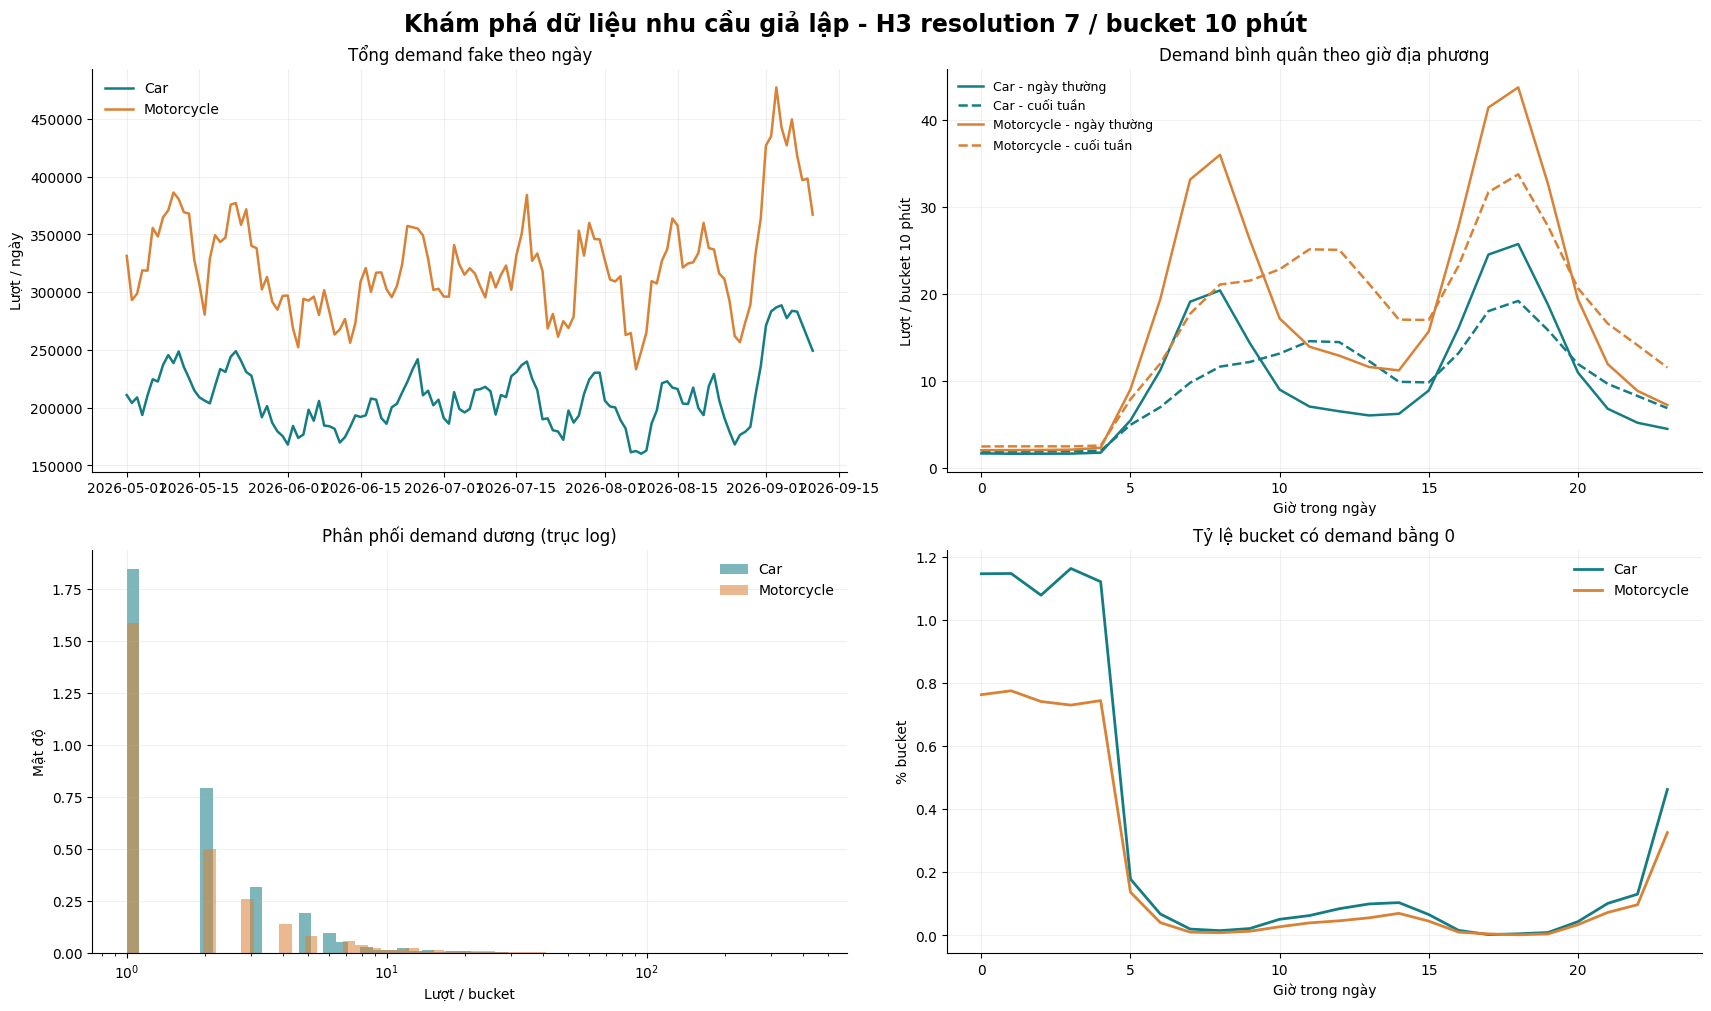

In [10]:
# Trực quan dữ liệu fake: chạy sau cell đọc và sắp xếp dữ liệu.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_fake_view = df[["bucket_start", "travel_mode", "demand_h10"]]
FAKE_DATA_SUMMARY = (_fake_view.groupby("travel_mode", observed=True)["demand_h10"]
    .agg(rows="size", mean="mean", median="median", p95=lambda x: x.quantile(.95),
         p99=lambda x: x.quantile(.99), zeros=lambda x: (x == 0).sum(), maximum="max")
    .reset_index())
FAKE_DATA_SUMMARY["zero_%"] = 100 * FAKE_DATA_SUMMARY["zeros"] / FAKE_DATA_SUMMARY["rows"]
print("Số dòng, mức demand và tỷ lệ demand bằng 0 theo phương tiện:")
display(FAKE_DATA_SUMMARY.round(2))

_day_total = (_fake_view.assign(date=_fake_view.bucket_start.dt.floor("D"))
    .groupby(["date", "travel_mode"], observed=True).demand_h10.sum().unstack())
_hourly = (_fake_view.assign(hour=_fake_view.bucket_start.dt.hour,
                            weekend=_fake_view.bucket_start.dt.dayofweek >= 5)
    .groupby(["travel_mode", "weekend", "hour"], observed=True).demand_h10.mean()
    .reset_index())
_night_zero = (_fake_view.assign(hour=_fake_view.bucket_start.dt.hour,
                                zero=_fake_view.demand_h10.eq(0))
    .groupby(["travel_mode", "hour"], observed=True).zero.mean().reset_index())

plt.rcParams["font.family"] = "DejaVu Sans"
_colors = {"Car": "#147D84", "Motorcycle": "#D98135"}
fig, axes = plt.subplots(2, 2, figsize=(17, 10), constrained_layout=True)
for mode in _day_total.columns:
    axes[0, 0].plot(_day_total.index, _day_total[mode], color=_colors.get(mode),
                    label=mode, lw=1.8)
axes[0, 0].set(title="Tổng demand fake theo ngày", ylabel="Lượt / ngày")
axes[0, 0].legend(frameon=False)
for mode in _fake_view.travel_mode.unique():
    for is_weekend, line in [(False, "-"), (True, "--")]:
        v = _hourly[(_hourly.travel_mode == mode) & (_hourly.weekend == is_weekend)]
        axes[0, 1].plot(v.hour, v.demand_h10, ls=line, lw=1.8,
                        color=_colors.get(mode), label=f"{mode} - {'cuối tuần' if is_weekend else 'ngày thường'}")
axes[0, 1].set(title="Demand bình quân theo giờ địa phương", xlabel="Giờ trong ngày", ylabel="Lượt / bucket 10 phút")
axes[0, 1].legend(frameon=False, fontsize=9)
for mode, group in _fake_view.groupby("travel_mode", observed=True):
    sample = group.demand_h10.sample(n=min(len(group), 90_000), random_state=20260916)
    axes[1, 0].hist(sample, bins=np.geomspace(1, max(10, sample.max()) + 1, 55),
                    color=_colors.get(mode), alpha=.55, label=mode, density=True)
axes[1, 0].set_xscale("log")
axes[1, 0].set(title="Phân phối demand dương (trục log)", xlabel="Lượt / bucket", ylabel="Mật độ")
axes[1, 0].legend(frameon=False)
for mode, group in _night_zero.groupby("travel_mode", observed=True):
    axes[1, 1].plot(group.hour, 100 * group.zero, lw=2, color=_colors.get(mode), label=mode)
axes[1, 1].set(title="Tỷ lệ bucket có demand bằng 0", xlabel="Giờ trong ngày", ylabel="% bucket")
axes[1, 1].legend(frameon=False)
for ax in axes.flat:
    ax.grid(alpha=.18)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Khám phá dữ liệu nhu cầu giả lập - H3 resolution 7 / bucket 10 phút", fontsize=17, fontweight="bold")
plt.show()


**Nhận xét từ dữ liệu đã chạy.** Có 5.404.530 record ở 217 ô H3 và hai loại xe. Motorcycle có demand trung bình 16,96, Car 9,75 lượt/bucket. Giờ 0–4 thấp rõ rệt; hai đỉnh trong ngày và khác biệt ngày thường/cuối tuần giải thích vì sao nhóm feature thời gian cần được thử. Dữ liệu được sinh giả lập nên các dạng này chưa chứng minh hành vi ngoài thực tế.

Số quan sát và mức demand theo vùng GIẢ LẬP (trung bình trên các bucket đã quan sát):


,synthetic_zone,travel_mode,rows,mean
0,airport,Car,259200,19.72
1,airport,Motorcycle,222624,33.73
2,central,Car,244080,28.83
3,central,Motorcycle,227664,51.47
4,east,Car,299088,8.33
5,east,Motorcycle,254736,15.64
6,outer,Car,1595654,3.63
7,outer,Motorcycle,1429420,5.85
8,south,Car,246240,14.25
9,south,Motorcycle,211248,25.83


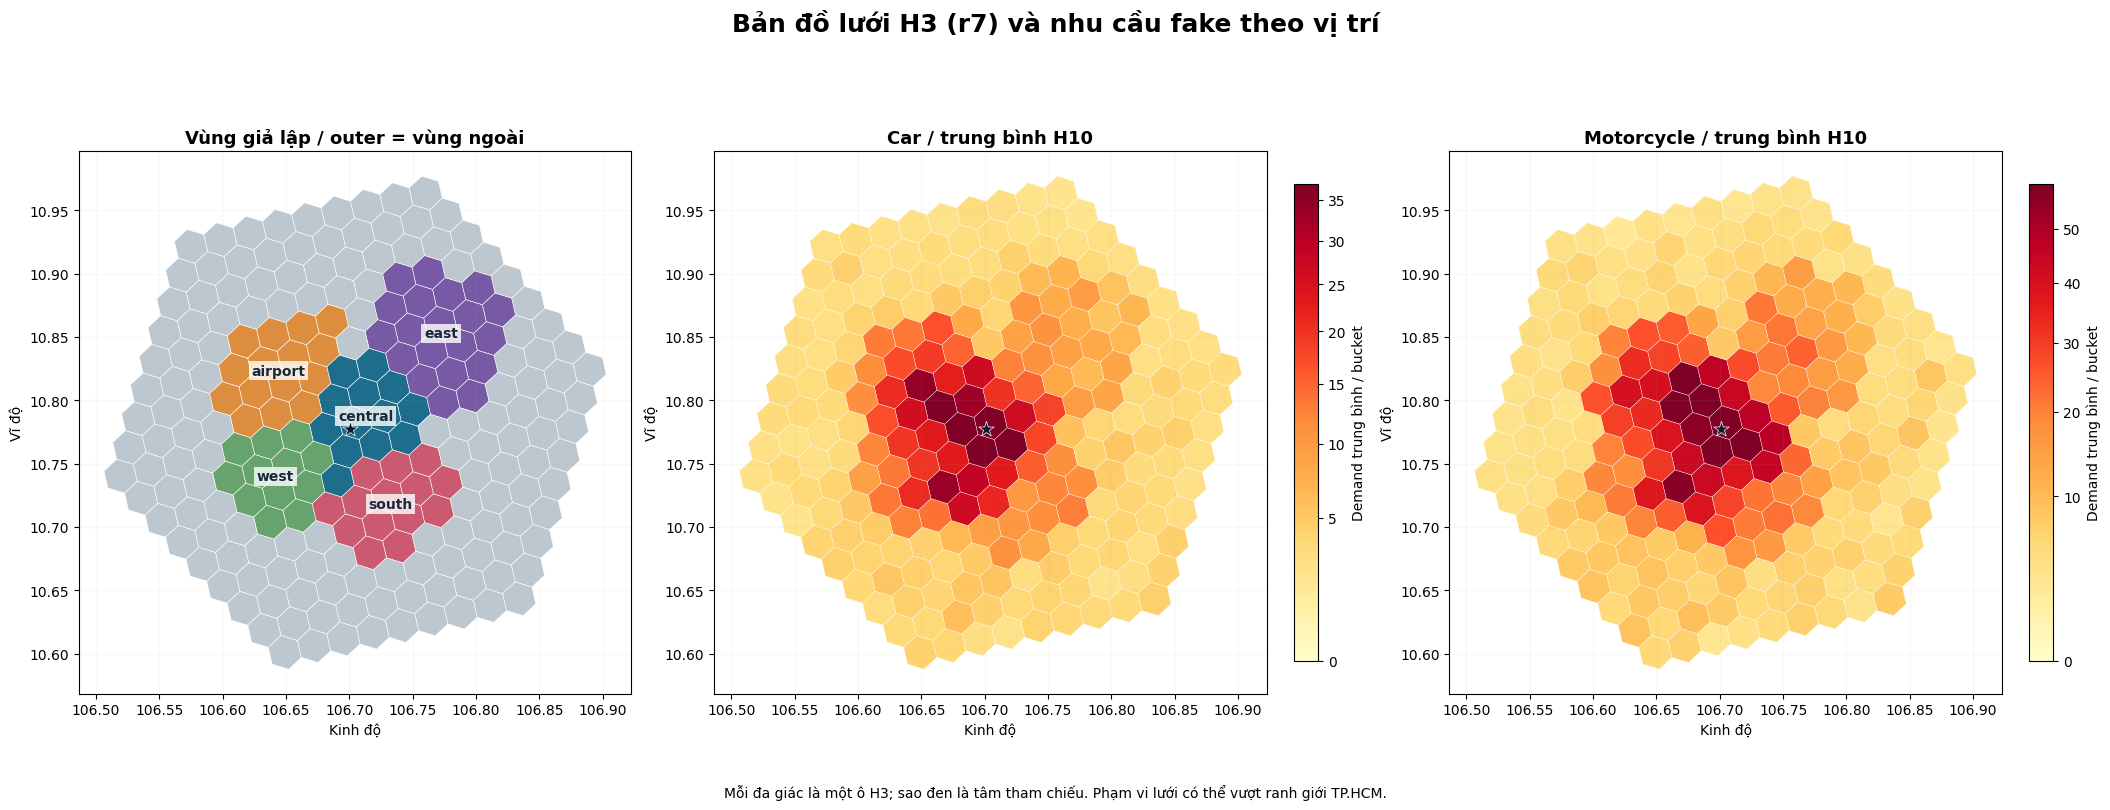

In [11]:
# Bản đồ địa lý H3: các vùng là nhãn giả lập của bộ sinh, không phải ranh giới hành chính.
import h3
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import PowerNorm

_hex = HEX_METADATA[["hex_id_7", "center_lat", "center_lng", "synthetic_zone"]].drop_duplicates("hex_id_7").copy()
_hex["hex_id_7"] = _hex.hex_id_7.astype(str)
_hex_totals = (df.groupby(["hex_id_7", "travel_mode"], observed=True).demand_h10
    .agg(rows="size", demand_sum="sum").reset_index())
_hex_totals["hex_id_7"] = _hex_totals.hex_id_7.astype(str)
_mean = _hex_totals.assign(mean=_hex_totals.demand_sum / _hex_totals.rows)
_mean = _mean.pivot(index="hex_id_7", columns="travel_mode", values="mean").reset_index()
HEX_MAP_DATA = _hex.merge(_mean, how="left", on="hex_id_7", validate="one_to_one")
ZONE_SUMMARY = (_hex_totals.merge(_hex[["hex_id_7", "synthetic_zone"]], on="hex_id_7", validate="many_to_one")
    .groupby(["synthetic_zone", "travel_mode"], observed=True)[["rows", "demand_sum"]]
    .sum().reset_index())
ZONE_SUMMARY["mean"] = ZONE_SUMMARY.demand_sum / ZONE_SUMMARY.rows
ZONE_SUMMARY = ZONE_SUMMARY[["synthetic_zone", "travel_mode", "rows", "mean"]]
print("Số quan sát và mức demand theo vùng GIẢ LẬP (trung bình trên các bucket đã quan sát):")
display(ZONE_SUMMARY.round(2))

_zone_colors = {"central": "#1C6E8C", "airport": "#DD8D3E", "east": "#7859A6",
                "west": "#67A36C", "south": "#CB5A70", "outer": "#BDC7CF"}
_poly = [Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)], closed=True)
         for cell in HEX_MAP_DATA.hex_id_7]
fig, axs = plt.subplots(1, 3, figsize=(21, 8), constrained_layout=True)
_zone_face = [_zone_colors.get(zone, "#CCCCCC") for zone in HEX_MAP_DATA.synthetic_zone]
for ax, mode in zip(axs, ["Vùng giả lập", "Car", "Motorcycle"]):
    if mode == "Vùng giả lập":
        collection = PatchCollection(_poly, facecolors=_zone_face, edgecolors="#FFFFFF", linewidths=.4)
        ax.add_collection(collection)
        for zone in ("central", "airport", "east", "west", "south"):
            center = HEX_MAP_DATA.loc[HEX_MAP_DATA.synthetic_zone == zone, ["center_lng", "center_lat"]].mean()
            ax.text(center.center_lng, center.center_lat, zone, ha="center", va="center", fontsize=10,
                    fontweight="bold", color="#172A3A", bbox=dict(facecolor="white", alpha=.8, edgecolor="none", pad=2))
        ax.set_title(mode + " / outer = vùng ngoài", fontsize=13, fontweight="bold")
    else:
        values = HEX_MAP_DATA[mode].to_numpy(dtype=float)
        norm = PowerNorm(.6, vmin=0, vmax=np.nanpercentile(values, 98))
        collection = PatchCollection(_poly, cmap="YlOrRd", norm=norm,
                                     edgecolors="#FFFFFF", linewidths=.25)
        collection.set_array(values)
        ax.add_collection(collection)
        fig.colorbar(collection, ax=ax, shrink=.63, label="Demand trung bình / bucket")
        ax.set_title(mode + " / trung bình H10", fontsize=13, fontweight="bold")
    ax.scatter([106.7009], [10.7769], marker="*", s=135, c="#101C30", edgecolors="white", linewidths=.5, zorder=5)
    ax.autoscale_view()
    ax.set_aspect("equal", adjustable="box")
    ax.set(xlabel="Kinh độ", ylabel="Vĩ độ")
    ax.grid(alpha=.08)
fig.suptitle("Bản đồ lưới H3 (r7) và nhu cầu fake theo vị trí", fontsize=18, fontweight="bold")
fig.text(.5, .01, "Mỗi đa giác là một ô H3; sao đen là tâm tham chiếu. Phạm vi lưới có thể vượt ranh giới TP.HCM.", ha="center", fontsize=10)
plt.show()


**Đọc bản đồ.** Mỗi đa giác là một ô H3 resolution 7; màu vùng `central`, `airport`, `east`, `west`, `south`, `outer` lấy từ bộ sinh fake data. Vùng `outer` bao phủ phần còn lại của lưới; đây không phải địa giới hành chính TP.HCM. Các ô ở trung tâm có demand bình quân cao hơn ô ngoài, nên `hex_code` có cơ sở để được kiểm tra bằng ablation.

# FEATURE 1: hex_code

In [12]:
# ============================================================
# FEATURE 1: hex_code
#
# Mục đích:
#   Chuyển mã H3 dạng string thành số integer.
#
# Ví dụ:
#   8765b1904fffffff -> 0
#   8765b1905fffffff -> 1
#
# Tree model có thể dùng giá trị này để phân biệt khu vực.
# ============================================================

df["hex_id_7"] = df["hex_id_7"].astype("category")

df["hex_code"] = (
    df["hex_id_7"]
    .cat.codes
    .astype("int16")
)

display(
    df[
        ["hex_id_7", "hex_code"]
    ]
    .drop_duplicates()
    .head(10)
)

,hex_id_7,hex_code
0,8765b1904ffffff,0
10368,8765b1906ffffff,1
20448,8765b1910ffffff,2
31248,8765b1912ffffff,3
41616,8765b1914ffffff,4
51984,8765b1915ffffff,5
62208,8765b1916ffffff,6
72720,8765b1920ffffff,7
82512,8765b1922ffffff,8
92592,8765b1923ffffff,9


# FEATURE 2: slot_10m

In [13]:
(24 *60 )/10 -1

143.0

In [14]:
# ============================================================
# FEATURE 2: slot_10m
#
# Mục đích:
#   Cho model biết vị trí của bucket trong ngày.
#
# Range:
#   0 -> 143
# ============================================================

df["slot_10m"] = (
    df["bucket_start"].dt.hour * 6
    + df["bucket_start"].dt.minute // 10
).astype("int16")

display(
    df[
        ["bucket_start", "slot_10m"]
    ].head(20)
)

,bucket_start,slot_10m
0,2026-05-01 00:00:00+07:00,0
1,2026-05-01 00:10:00+07:00,1
2,2026-05-01 00:20:00+07:00,2
3,2026-05-01 00:30:00+07:00,3
4,2026-05-01 00:40:00+07:00,4
5,2026-05-01 00:50:00+07:00,5
6,2026-05-01 01:00:00+07:00,6
7,2026-05-01 01:10:00+07:00,7
8,2026-05-01 01:20:00+07:00,8
9,2026-05-01 01:30:00+07:00,9


# FEATURE 3: day_of_week

In [15]:
# ============================================================
#FEATURE 3: day_of_week
#
# Thứ trong tuần:
#
# 0 = Monday
# 1 = Tuesday
# 2 = Wednesday
# 3 = Thursday
# 4 = Friday
# 5 = Saturday
# 6 = Sunday
#
# Demand có thể khác nhau giữa các ngày trong tuần.
# ============================================================

df["day_of_week"] = (
    df["bucket_start"]
    .dt.dayofweek
    .astype("int8")
)

display(
    df[
        ["bucket_start", "day_of_week"]
    ].sample(10)
)

,bucket_start,day_of_week
1134110,2026-08-16 18:20:00+07:00,6
4287257,2026-07-28 03:50:00+07:00,1
4696653,2026-07-14 04:30:00+07:00,1
3957920,2026-05-27 02:20:00+07:00,2
4709614,2026-05-15 04:40:00+07:00,4
3356804,2026-05-01 16:20:00+07:00,4
4856917,2026-05-09 03:10:00+07:00,5
468455,2026-05-19 03:50:00+07:00,1
2364978,2026-07-16 12:40:00+07:00,3
226193,2026-07-29 18:50:00+07:00,2


#  FEATURE 4: is_weekend

In [16]:
# ============================================================
#  FEATURE 4: is_weekend
#
# 0 = ngày thường
# 1 = thứ 7 hoặc chủ nhật
#
# Dùng để giúp model phân biệt pattern weekday/weekend.
# ============================================================

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype("int8")

display(
    df[
        ["bucket_start", "day_of_week", "is_weekend"]
    ].drop_duplicates().sample(10)
)

,bucket_start,day_of_week,is_weekend
9359,2026-09-03 23:50:00+07:00,3,0
266,2026-05-02 20:20:00+07:00,5,1
958,2026-05-07 15:40:00+07:00,3,0
28382,2026-07-27 02:20:00+07:00,0,0
24795,2026-07-02 04:30:00+07:00,3,0
3824,2026-05-27 13:20:00+07:00,2,0
8766,2026-08-30 21:00:00+07:00,6,1
25088,2026-07-04 05:20:00+07:00,5,1
26810,2026-07-16 04:20:00+07:00,3,0
16579,2026-08-15 03:10:00+07:00,5,1


# FEATURE 5: is_holiday

In [17]:
# ============================================================
# FEATURE 5: is_holiday
#
# 0 = ngày bình thường
# 1 = ngày lễ
#
# holiday_name chỉ dùng để visualize/debug,
# KHÔNG đưa trực tiếp vào model.
# ============================================================

df["local_date"] = (
    df["bucket_start"]
    .dt.date
)

df["is_holiday"] = (
    df["local_date"]
    .isin(VN_HOLIDAYS.keys())
    .astype("int8")
)

df["holiday_name"] = (
    df["local_date"]
    .map(lambda d: VN_HOLIDAYS.get(d, ""))
    .astype("string")
)

display(
    df[
        [
            "bucket_start",
            "local_date",
            "is_holiday",
            "holiday_name"
        ]
    ][df["is_holiday"] == 1].head(10)
)

,bucket_start,local_date,is_holiday,holiday_name
0,2026-05-01 00:00:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
1,2026-05-01 00:10:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
2,2026-05-01 00:20:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
3,2026-05-01 00:30:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
4,2026-05-01 00:40:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
5,2026-05-01 00:50:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
6,2026-05-01 01:00:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
7,2026-05-01 01:10:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
8,2026-05-01 01:20:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
9,2026-05-01 01:30:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động


# PREPARE EXACT-LAG LOOKUP

In [18]:
# ============================================================
# PREPARE EXACT-LAG LOOKUP
#
# Tạo index:
#
# travel_mode + hex_id_7 + timestamp
#
# để tìm demand chính xác tại:
#
# T - 30 phút
# T - 40 phút
# ...
#
# Không dùng shift đơn thuần vì nếu thiếu bucket,
# shift có thể lấy nhầm thời điểm.
# ============================================================

history_index = pd.MultiIndex.from_arrays(
    [
        df["travel_mode"],
        df["hex_id_7"],
        df["bucket_start"]
    ],
    names=[
        "travel_mode",
        "hex_id_7",
        "bucket_start"
    ]
)

history = pd.Series(
    df["demand_h10"].to_numpy(),
    index=history_index
)

assert history.index.is_unique

print("History rows:", len(history))

History rows: 5404530


#  FEATURE 6: lag_30m

In [19]:
# ============================================================
#  FEATURE 6: lag_30m
#
# Demand của cùng:
#   travel_mode
#   hex
#
# tại thời điểm T - 30 phút.
#
# Đây là lag gần quan trọng nhất trong model hiện tại.
# ============================================================

lookup_index = pd.MultiIndex.from_arrays([
    df["travel_mode"],
    df["hex_id_7"],
    df["bucket_start"] - pd.Timedelta(minutes=30)
])

df["lag_30m"] = (
    history
    .reindex(lookup_index)
    .to_numpy()
    .astype("float32")
)

display(
    df[
        ["bucket_start", "demand_h10", "lag_30m"]
    ].head(20)
)

,bucket_start,demand_h10,lag_30m
0,2026-05-01 00:00:00+07:00,1,NaN
1,2026-05-01 00:10:00+07:00,1,NaN
2,2026-05-01 00:20:00+07:00,1,NaN
3,2026-05-01 00:30:00+07:00,1,1.0
4,2026-05-01 00:40:00+07:00,1,1.0
5,2026-05-01 00:50:00+07:00,1,1.0
6,2026-05-01 01:00:00+07:00,1,1.0
7,2026-05-01 01:10:00+07:00,1,1.0
8,2026-05-01 01:20:00+07:00,1,1.0
9,2026-05-01 01:30:00+07:00,1,1.0


# FEATURE 7: lag_40m

In [20]:
# ============================================================
# FEATURE 7: lag_40m
#
# Demand tại T - 40 phút.
# ============================================================

lookup_index = pd.MultiIndex.from_arrays([
    df["travel_mode"],
    df["hex_id_7"],
    df["bucket_start"] - pd.Timedelta(minutes=40)
])

df["lag_40m"] = (
    history
    .reindex(lookup_index)
    .to_numpy()
    .astype("float32")
)
display(
    df[
        ["bucket_start", "demand_h10", "lag_40m"]
    ].head(20)
)

,bucket_start,demand_h10,lag_40m
0,2026-05-01 00:00:00+07:00,1,NaN
1,2026-05-01 00:10:00+07:00,1,NaN
2,2026-05-01 00:20:00+07:00,1,NaN
3,2026-05-01 00:30:00+07:00,1,NaN
4,2026-05-01 00:40:00+07:00,1,1.0
5,2026-05-01 00:50:00+07:00,1,1.0
6,2026-05-01 01:00:00+07:00,1,1.0
7,2026-05-01 01:10:00+07:00,1,1.0
8,2026-05-01 01:20:00+07:00,1,1.0
9,2026-05-01 01:30:00+07:00,1,1.0


# FEATURE 8: lag_50m

In [21]:
# ============================================================
# FEATURE 8: lag_50m
#
# Demand tại T - 50 phút.
# ============================================================

lookup_index = pd.MultiIndex.from_arrays([
    df["travel_mode"],
    df["hex_id_7"],
    df["bucket_start"] - pd.Timedelta(minutes=50)
])

df["lag_50m"] = (
    history
    .reindex(lookup_index)
    .to_numpy()
    .astype("float32")
)

#  FEATURE 9: lag_60m

In [22]:
# ============================================================
#  FEATURE 9: lag_60m
#
# Demand tại T - 60 phút.
#
# Dùng cùng lag_30m để xác định trend demand gần đây.
# ============================================================

lookup_index = pd.MultiIndex.from_arrays([
    df["travel_mode"],
    df["hex_id_7"],
    df["bucket_start"] - pd.Timedelta(minutes=60)
])

df["lag_60m"] = (
    history
    .reindex(lookup_index)
    .to_numpy()
    .astype("float32")
)

# FEATURE 10: lag_90m

In [23]:
# ============================================================
# FEATURE 10: lag_90m
#
# Demand cách thời điểm hiện tại 1 giờ 30 phút.
# ============================================================

lookup_index = pd.MultiIndex.from_arrays([
    df["travel_mode"],
    df["hex_id_7"],
    df["bucket_start"] - pd.Timedelta(minutes=90)
])

df["lag_90m"] = (
    history
    .reindex(lookup_index)
    .to_numpy()
    .astype("float32")
)

#  FEATURE 11: lag_120m

In [24]:
# ============================================================
#  FEATURE 11: lag_120m
#
# Demand tại T - 2 giờ.
# ============================================================

lookup_index = pd.MultiIndex.from_arrays([
    df["travel_mode"],
    df["hex_id_7"],
    df["bucket_start"] - pd.Timedelta(minutes=120)
])

df["lag_120m"] = (
    history
    .reindex(lookup_index)
    .to_numpy()
    .astype("float32")
)

# FEATURE 12: lag_1d

In [25]:
# ============================================================
# FEATURE 12: lag_1d
#
# Demand của:
#   cùng hex
#   cùng travel mode
#   cùng thời điểm
#
# của ngày hôm trước.
#
# Ví dụ:
#   target hôm nay 08:00
#   -> lấy demand hôm qua 08:00.
# ============================================================

lookup_index = pd.MultiIndex.from_arrays([
    df["travel_mode"],
    df["hex_id_7"],
    df["bucket_start"] - pd.Timedelta(days=1)
])

df["lag_1d"] = (
    history
    .reindex(lookup_index)
    .to_numpy()
    .astype("float32")
)
display(
    df[
        ["bucket_start", "demand_h10", "lag_1d"]
    ][df["lag_1d"].notna()].head(20)
)

,bucket_start,demand_h10,lag_1d
144,2026-05-02 00:00:00+07:00,1,1.0
145,2026-05-02 00:10:00+07:00,1,1.0
146,2026-05-02 00:20:00+07:00,1,1.0
147,2026-05-02 00:30:00+07:00,1,1.0
148,2026-05-02 00:40:00+07:00,1,1.0
149,2026-05-02 00:50:00+07:00,1,1.0
150,2026-05-02 01:00:00+07:00,1,1.0
151,2026-05-02 01:10:00+07:00,1,1.0
152,2026-05-02 01:20:00+07:00,1,1.0
153,2026-05-02 01:30:00+07:00,1,1.0


#  FEATURE 13: lag_7d

In [26]:
# ============================================================
#  FEATURE 13: lag_7d
#
# Demand cùng giờ, cùng hex, cùng mode
# nhưng ở tuần trước.
#
# Feature này giúp bắt weekly seasonality.
#
# Ví dụ:
#   Monday 08:00
#           ↓
#   Monday tuần trước 08:00
# ============================================================

lookup_index = pd.MultiIndex.from_arrays([
    df["travel_mode"],
    df["hex_id_7"],
    df["bucket_start"] - pd.Timedelta(days=7)
])

df["lag_7d"] = (
    history
    .reindex(lookup_index)
    .to_numpy()
    .astype("float32")
)

# FEATURE 14: recent_mean_30_60m

In [27]:
# ============================================================
#  FEATURE 14: recent_mean_30_60m
#
# Trung bình demand của:
#
# T-30
# T-40
# T-50
# T-60
#
# Mục đích:
#   biểu diễn mức demand trung bình gần đây,
#   ổn định hơn việc chỉ nhìn một lag duy nhất.
# ============================================================

recent_columns = [
    "lag_30m",
    "lag_40m",
    "lag_50m",
    "lag_60m"
]

df["recent_mean_30_60m"] = (
    df[recent_columns]
    .mean(axis=1)
    .astype("float32")
)

display(
    df[
        recent_columns
        + ["recent_mean_30_60m"]
    ].head()
)

,lag_30m,lag_40m,lag_50m,lag_60m,recent_mean_30_60m
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,1.0,NaN,NaN,NaN,1.0
4,1.0,1.0,NaN,NaN,1.0


# FEATURE 15: recent_std_30_60m

In [28]:
# ============================================================
# FEATURE 15: recent_std_30_60m
#
# Độ lệch chuẩn của demand từ T-60 -> T-30.
#
# Std thấp:
#   demand khá ổn định.
#
# Std cao:
#   demand đang biến động mạnh.
#
# Giúp model nhận biết volatility.
# ============================================================

df["recent_std_30_60m"] = (
    df[
        [
            "lag_30m",
            "lag_40m",
            "lag_50m",
            "lag_60m"
        ]
    ]
    .std(
        axis=1,
        ddof=0
    )
    .astype("float32")
)

display(
    df[
        [
            "lag_30m",
            "lag_40m",
            "lag_50m",
            "lag_60m",
            "recent_std_30_60m"
        ]
    ].head()
)

,lag_30m,lag_40m,lag_50m,lag_60m,recent_std_30_60m
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,1.0,NaN,NaN,NaN,0.0
4,1.0,1.0,NaN,NaN,0.0


# FEATURE 16: recent_trend

In [29]:
# ============================================================
# FEATURE 16: recent_trend
#
# Công thức:
#
#   lag_30m - lag_60m
#
# > 0:
#   demand gần đây đang tăng.
#
# < 0:
#   demand gần đây đang giảm.
#
# = 0:
#   demand tương đối ổn định.
# ============================================================

df["recent_trend"] = (
    df["lag_30m"]
    - df["lag_60m"]
).astype("float32")

display(
    df[
        [
            "lag_60m",
            "lag_30m",
            "recent_trend"
        ]
    ].head(20)
)

,lag_60m,lag_30m,recent_trend
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,1.0,NaN
4,NaN,1.0,NaN
5,NaN,1.0,NaN
6,1.0,1.0,0.0
7,1.0,1.0,0.0
8,1.0,1.0,0.0
9,1.0,1.0,0.0


# FEATURE 17: hour_sin

In [30]:
# ============================================================
# FEATURE 17: hour_sin
#
# Biến đổi giờ trong ngày thành dạng tuần hoàn.
#
# Dùng cùng hour_cos.
# ============================================================

hour = (
    df["bucket_start"].dt.hour
    + df["bucket_start"].dt.minute / 60
)

df["hour_sin"] = np.sin(
    2 * np.pi * hour / 24
).astype("float32")

display(
    df[
        ["bucket_start", "hour_sin"]
    ].head()
)

,bucket_start,hour_sin
0,2026-05-01 00:00:00+07:00,0.000000
1,2026-05-01 00:10:00+07:00,0.043619
2,2026-05-01 00:20:00+07:00,0.087156
3,2026-05-01 00:30:00+07:00,0.130526
4,2026-05-01 00:40:00+07:00,0.173648


# FEATURE 18: hour_cos

In [31]:
# ============================================================
# FEATURE 18: hour_cos
#
# Đi cùng hour_sin để biểu diễn đầy đủ chu kỳ 24 giờ.
# ============================================================

hour = (
    df["bucket_start"].dt.hour
    + df["bucket_start"].dt.minute / 60
)

df["hour_cos"] = np.cos(
    2 * np.pi * hour / 24
).astype("float32")

display(
    df[
        [
            "bucket_start",
            "hour_sin",
            "hour_cos"
        ]
    ].head()
)

,bucket_start,hour_sin,hour_cos
0,2026-05-01 00:00:00+07:00,0.000000,1.000000
1,2026-05-01 00:10:00+07:00,0.043619,0.999048
2,2026-05-01 00:20:00+07:00,0.087156,0.996195
3,2026-05-01 00:30:00+07:00,0.130526,0.991445
4,2026-05-01 00:40:00+07:00,0.173648,0.984808


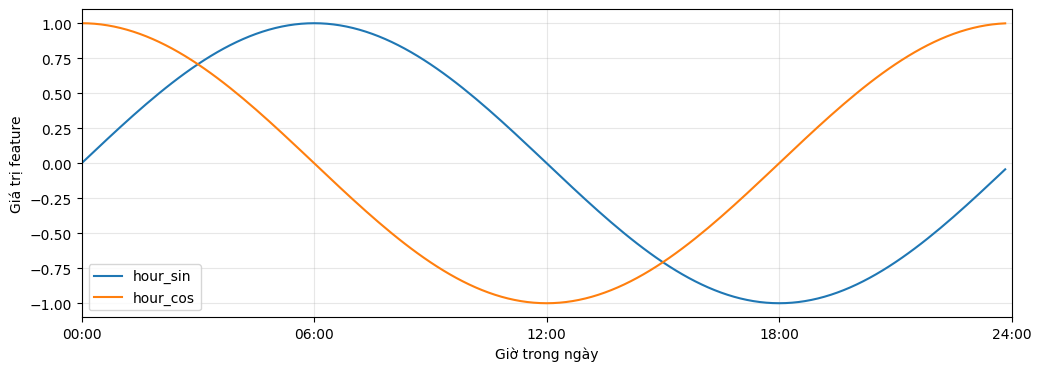

In [32]:
import matplotlib.pyplot as plt

# Lấy một ngày để tránh vẽ chồng dữ liệu của nhiều ngày và nhiều hex
start = df["bucket_start"].min().normalize()

plot_df = (
    df.loc[
        (df["bucket_start"] >= start)
        & (df["bucket_start"] < start + pd.Timedelta(days=1)),
        ["bucket_start", "hour_sin", "hour_cos"]
    ]
    .drop_duplicates("bucket_start")
    .sort_values("bucket_start")
)

# Chỉ chuyển thời gian sang số giờ để làm trục X
x = (
    plot_df["bucket_start"].dt.hour
    + plot_df["bucket_start"].dt.minute / 60
)

plt.figure(figsize=(12, 4))
plt.plot(x, plot_df["hour_sin"], label="hour_sin")
plt.plot(x, plot_df["hour_cos"], label="hour_cos")

plt.xticks(
    [0, 6, 12, 18, 24],
    ["00:00", "06:00", "12:00", "18:00", "24:00"]
)
plt.xlim(0, 24)
plt.ylim(-1.1, 1.1)
plt.xlabel("Giờ trong ngày")
plt.ylabel("Giá trị feature")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#  FEATURE 19: dow_sin


In [33]:
# ============================================================
#  FEATURE 19: dow_sin
#
# Biến đổi thứ trong tuần thành cyclic feature.
#
# Sunday và Monday vì vậy được hiểu là gần nhau
# trong chu kỳ tuần.
# ============================================================

df["dow_sin"] = np.sin(
    2
    * np.pi
    * df["day_of_week"]
    / 7
).astype("float32")

# FEATURE 20: dow_cos

In [34]:
# ============================================================
# FEATURE 20: dow_cos
#
# Đi cùng dow_sin để biểu diễn chu kỳ 7 ngày.
# ============================================================

df["dow_cos"] = np.cos(
    2
    * np.pi
    * df["day_of_week"]
    / 7
).astype("float32")

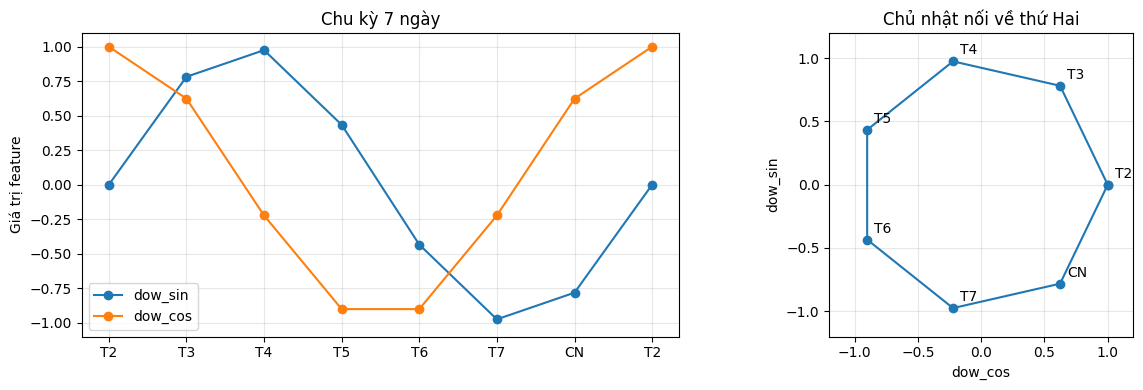

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

week = (
    df[["day_of_week", "dow_sin", "dow_cos"]]
    .drop_duplicates("day_of_week")
    .sort_values("day_of_week")
    .reset_index(drop=True)
)

# Lặp lại điểm thứ Hai ở cuối chỉ để vẽ khép kín chu kỳ
closed_week = pd.concat(
    [week, week.iloc[[0]]],
    ignore_index=True
)

day_labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN", "T2"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Hình 1: Giá trị sin/cos qua các ngày
ax1.plot(range(8), closed_week["dow_sin"], marker="o", label="dow_sin")
ax1.plot(range(8), closed_week["dow_cos"], marker="o", label="dow_cos")
ax1.set_xticks(range(8), day_labels)
ax1.set_ylim(-1.1, 1.1)
ax1.set_title("Chu kỳ 7 ngày")
ax1.set_ylabel("Giá trị feature")
ax1.grid(alpha=0.3)
ax1.legend()

# Hình 2: Cặp (cos, sin) tạo thành vòng tròn
ax2.plot(
    closed_week["dow_cos"],
    closed_week["dow_sin"],
    marker="o"
)

for row in week.itertuples(index=False):
    ax2.annotate(
        day_labels[row.day_of_week],
        (row.dow_cos, row.dow_sin),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax2.set_aspect("equal")
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel("dow_cos")
ax2.set_ylabel("dow_sin")
ax2.set_title("Chủ nhật nối về thứ Hai")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# FEATURE 21: trend_day

In [36]:
# ============================================================
# FEATURE 21: trend_day
#
# Số ngày tính từ ngày đầu dataset.
#
# Ví dụ:
#
# ngày đầu tiên -> 0
# ngày tiếp theo -> 1
# ...
#
# Feature này giúp model nhận biết xu hướng dài hạn.
# ============================================================

LOCAL_START = df["bucket_start"].min()

df["trend_day"] = (
    (
        df["bucket_start"]
        - LOCAL_START
    )
    .dt.total_seconds()
    .div(86_400)
    .astype("float32")
)

display(
    df[
        [
            "bucket_start",
            "trend_day"
        ]
    ].head()
)

,bucket_start,trend_day
0,2026-05-01 00:00:00+07:00,0.000000
1,2026-05-01 00:10:00+07:00,0.006944
2,2026-05-01 00:20:00+07:00,0.013889
3,2026-05-01 00:30:00+07:00,0.020833
4,2026-05-01 00:40:00+07:00,0.027778


# DROP ROW CHƯA CÓ LỊCH SỬ

In [37]:
# ============================================================
# DROP ROW CHƯA CÓ LỊCH SỬ
#
# Nếu chưa có lag_30m thì chưa đủ thông tin gần nhất
# để đưa vào model.
# ============================================================

print("Rows trước:", len(df))

df = (
    df[df["lag_30m"].notna()]
    .copy()
    .reset_index(drop=True)
)

print("Rows sau:", len(df))

Rows trước: 5404530
Rows sau: 5402493


# FEATURE LIST

In [38]:
# ============================================================
# FEATURE LIST
#
# Đây chính là các cột sẽ được đưa vào X_train / X_test.
# ============================================================

FEATURES = [
    # --------------------------
    # Spatial
    # --------------------------
    "hex_code",

    # --------------------------
    # Calendar / Time
    # --------------------------
    "slot_10m",
    "day_of_week",
    "is_weekend",
    "is_holiday",

    # --------------------------
    # Cyclic time
    # --------------------------
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    # --------------------------
    # Long-term trend
    # --------------------------
    "trend_day",

    # --------------------------
    # Demand lag
    # --------------------------
    "lag_30m",
    "lag_40m",
    "lag_50m",
    "lag_60m",
    "lag_90m",
    "lag_120m",
    "lag_1d",
    "lag_7d",

    # --------------------------
    # Recent demand statistics
    # --------------------------
    "recent_mean_30_60m",
    "recent_std_30_60m",
    "recent_trend",
]

print("Số feature:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:02d}. {feature}")

Số feature: 21
01. hex_code
02. slot_10m
03. day_of_week
04. is_weekend
05. is_holiday
06. hour_sin
07. hour_cos
08. dow_sin
09. dow_cos
10. trend_day
11. lag_30m
12. lag_40m
13. lag_50m
14. lag_60m
15. lag_90m
16. lag_120m
17. lag_1d
18. lag_7d
19. recent_mean_30_60m
20. recent_std_30_60m
21. recent_trend


# H10

In [39]:
df_all = df.copy()

MODE_FRAMES = {}

for mode, mode_df in df_all.groupby(
    "travel_mode",
    observed=True,
    sort=False
):
    mode_df = (
        mode_df
        .copy()
        .sort_values(
            ["hex_id_7", "bucket_start"],
            kind="stable"
        )
        .reset_index(drop=True)
    )

    MODE_FRAMES[str(mode)] = mode_df


print("MODE_FRAMES:", MODE_FRAMES.keys())

for mode, mode_df in MODE_FRAMES.items():
    print(
        mode,
        "| rows =", f"{len(mode_df):,}",
        "| modes =", mode_df["travel_mode"].unique()
    )
# ============================================================
# TRAIN | VALIDATION 30 NGÀY | TEST
# Mốc chung cho mọi mode và horizon direct.
# ============================================================
TRAIN_RATIO = 0.80
VALIDATION_DAYS = 30
unique_split_times = (
    df_all["bucket_start"].drop_duplicates().sort_values().reset_index(drop=True)
)
test_position = min(
    max(int(len(unique_split_times) * TRAIN_RATIO), 1),
    len(unique_split_times)-1,
)
TEST_START = unique_split_times.iloc[test_position]
VAL_START = TEST_START - pd.Timedelta(days=VALIDATION_DAYS)
if not unique_split_times.iloc[0] < VAL_START < TEST_START:
    raise ValueError("Không đủ dữ liệu trước 30 ngày validation")

def make_time_split(frame, horizon_minutes):
    ts = frame["bucket_start"]
    target_end = ts + pd.Timedelta(minutes=horizon_minutes)
    train = (ts < VAL_START) & (target_end <= VAL_START)
    val = (ts >= VAL_START) & (ts < TEST_START) & (target_end <= TEST_START)
    test = ts >= TEST_START
    train_index = np.flatnonzero(train.to_numpy())
    val_index = np.flatnonzero(val.to_numpy())
    test_index = np.flatnonzero(test.to_numpy())
    train_val_index = np.flatnonzero((train | val).to_numpy())
    purged = len(frame)-len(train_index)-len(val_index)-len(test_index)
    if min(len(train_index),len(val_index),len(test_index)) == 0:
        raise ValueError(f"H{horizon_minutes}: train/val/test rỗng")
    assert target_end.iloc[train_index].max() <= VAL_START
    assert target_end.iloc[val_index].max() <= TEST_START
    assert ts.iloc[val_index].min() >= VAL_START
    assert ts.iloc[test_index].min() >= TEST_START
    return {
        "train_index": train_index, "val_index": val_index,
        "train_val_index": train_val_index, "test_index": test_index,
        "val_start": VAL_START, "test_start": TEST_START,
        "purged_rows": purged,
    }

print(f"TRAIN < {VAL_START} | VAL [{VAL_START}, {TEST_START}) "
      f"({VALIDATION_DAYS} ngày) | TEST >= {TEST_START}")
for mode, frame in MODE_FRAMES.items():
    split = make_time_split(frame, 10)
    print(f"{mode} H10 | train={len(split['train_index']):,} "
          f"| val={len(split['val_index']):,} "
          f"| test={len(split['test_index']):,} "
          f"| purged={split['purged_rows']:,}")


MODE_FRAMES: dict_keys(['Car', 'Motorcycle'])
Car | rows = 2,862,686 | modes = ['Car']
Motorcycle | rows = 2,539,807 | modes = ['Motorcycle']
TRAIN < 2026-07-16 09:40:00+07:00 | VAL [2026-07-16 09:40:00+07:00, 2026-08-15 09:40:00+07:00) (30 ngày) | TEST >= 2026-08-15 09:40:00+07:00
Car H10 | train=1,648,849 | val=646,554 | test=567,283 | purged=0
Motorcycle H10 | train=1,441,586 | val=591,105 | test=507,116 | purged=0


## Train / validation 30 ngày / test

Car, Motorcycle và ba model direct H10/H30/H60 dùng cùng hai mốc VAL_START, TEST_START. Test là 20% mốc thời gian cuối; 30 ngày ngay trước test là validation. Target vượt ranh giới train/val hoặc val/test được purge.

Model tạm fit trên train và chọn số vòng trên validation. Sau đó refit model cuối trên train+validation để đánh giá một lần trên test.


In [40]:
# Chọn độ phức tạp cây theo WMAPE validation riêng cho từng mode/horizon.
# Số cây/số vòng tối ưu được tìm trong mỗi lần thử; test không tham gia chọn.
# Ba giá trị cho mỗi model giữ thời gian tìm kiếm có giới hạn (mỗi lần thử train lại).
HIST_LEAF_CANDIDATES = (63, 130, 255)
XGB_DEPTH_CANDIDATES = (6, 8, 10)
LGB_LEAF_CANDIDATES = (31, 63, 130)
HYPERPARAM_TRIALS = []

# ============================================================
# CELL 1 — TRAIN HistGBR CHO T+10
# Chọn max_iter trên validation, in WMAPE TEST
# ============================================================

import gc
from time import perf_counter

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor


TRAIN_RATIO = 0.80
MAX_TRAIN_ROWS = None

# Giới hạn số vòng được thử. HistGBR chạy trên CPU.
HIST_MAX_ITER_TO_SEARCH = 400


MODELS = {}
TEST_RESULTS = {}
SPLIT_TIMES = {}
FIT_SECONDS = {}
VAL_WMAPE_H10 = {}
VAL_VOLUMES_H10 = {}
TRAIN_INFO = []

HIST_BEST_ITER = {}
HIST_FINAL_PARAMS = {}
HIST_TEST_WMAPE = {}
HIST_SEARCH_SECONDS = {}


def _h10_wmape(actual, prediction):
    actual = np.asarray(actual, dtype=np.float64)
    prediction = np.asarray(prediction, dtype=np.float64)

    valid = np.isfinite(actual) & np.isfinite(prediction)
    actual = actual[valid]
    prediction = prediction[valid]

    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return (
        100
        * np.abs(actual - prediction).sum()
        / denominator
    )


for mode, mode_df in MODE_FRAMES.items():

    # --------------------------------------------------------
    # 1. TRAIN / VAL / TEST — CÙNG MỐC THỜI GIAN
    # --------------------------------------------------------

    split = make_time_split(mode_df, 10)
    train_index = split["train_index"]
    val_index = split["val_index"]
    test_index = split["test_index"]
    val_cutoff = split["val_start"]
    cutoff = split["test_start"]

    # --------------------------------------------------------
    # 2. GIỚI HẠN TRAIN — GIỮ NGUYÊN CODE GỐC
    # --------------------------------------------------------

    fit_index = train_index

    if (
        MAX_TRAIN_ROWS is not None
        and len(fit_index) > MAX_TRAIN_ROWS
    ):
        rng = np.random.default_rng(SEED)

        fit_index = np.sort(
            rng.choice(
                fit_index,
                size=MAX_TRAIN_ROWS,
                replace=False,
            )
        )

    refit_index = np.sort(np.r_[fit_index, val_index])
    actual_train_ratio = len(fit_index) / len(mode_df)
    print(
        f"{mode} | train={len(fit_index):,} ({actual_train_ratio:.2%}) "
        f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
        f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
        f"| val_start={val_cutoff} | test_start={cutoff}"
    )

    # --------------------------------------------------------
    # 3. DỮ LIỆU TRAIN / TEST GỐC
    # --------------------------------------------------------

    X_train = mode_df.iloc[refit_index][FEATURES].copy()
    y_train = mode_df.iloc[refit_index]["demand_h10"].copy()
    X_test = mode_df.iloc[test_index][FEATURES].copy()

    test_result = (
        mode_df
        .iloc[test_index][[
            "bucket_start",
            "hex_id_7",
            "is_weekend",
            "demand_h10",
            "lag_30m",
        ]]
        .copy()
    )

    # --------------------------------------------------------
    X_early_train = mode_df.iloc[fit_index][FEATURES].copy()
    y_early_train = mode_df.iloc[fit_index]["demand_h10"].copy()
    X_val = mode_df.iloc[val_index][FEATURES].copy()
    y_val = mode_df.iloc[val_index]["demand_h10"].copy()
    val_actual = y_val.to_numpy(dtype=np.float64)

    # --------------------------------------------------------
    # 5. TRAIN TẠM, CHỌN VÒNG CÓ WMAPE VALIDATION THẤP NHẤT
    # --------------------------------------------------------

    search_params = dict(
        loss="poisson",
        learning_rate=0.05,
        max_iter=HIST_MAX_ITER_TO_SEARCH,
        max_leaf_nodes=130,
        min_samples_leaf=100,
        l2_regularization=2.0,
        max_bins=255,
        categorical_features=[FEATURES.index("hex_code")],
        early_stopping=False,
        random_state=SEED,
    )

    search_model = HistGradientBoostingRegressor(
        **search_params
    )

    search_started = perf_counter()

    search_model.fit(X_early_train, y_early_train)

    best_iteration = 0
    best_absolute_error = np.inf

    # Mỗi prediction ứng với một số vòng: 1, 2, ..., 400.
    # Trên cùng validation, WMAPE nhỏ nhất cũng là
    # tổng sai số tuyệt đối nhỏ nhất.
    for iteration, stage_prediction in enumerate(
        search_model.staged_predict(X_val),
        start=1,
    ):
        stage_prediction = np.clip(
            stage_prediction, 0, None
        )

        absolute_error = np.abs(
            val_actual - stage_prediction
        ).sum()

        if absolute_error < best_absolute_error:
            best_absolute_error = absolute_error
            best_iteration = iteration

    # Thử thêm các mức lá; mỗi mức tự chọn số vòng có WMAPE val thấp nhất.
    trials = [{"complexity": search_params["max_leaf_nodes"], "rounds": best_iteration, "VAL_WMAPE_%": 100.0 * best_absolute_error / np.abs(val_actual).sum()}]
    for leaf_count in HIST_LEAF_CANDIDATES:
        if leaf_count == search_params["max_leaf_nodes"]:
            continue
        candidate = HistGradientBoostingRegressor(**{**search_params, "max_leaf_nodes": leaf_count})
        candidate.fit(X_early_train, y_early_train)
        errors = (np.abs(val_actual - np.clip(pred, 0, None)).sum()
                  for pred in candidate.staged_predict(X_val))
        candidate_round, candidate_error = min(enumerate(errors, start=1), key=lambda pair: pair[1])
        trials.append({"complexity": leaf_count, "rounds": candidate_round,
                       "VAL_WMAPE_%": 100.0 * candidate_error / np.abs(val_actual).sum()})
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_leaf_nodes"] = selected["complexity"]
    best_iteration = selected["rounds"]
    best_absolute_error = selected["VAL_WMAPE_%"] * np.abs(val_actual).sum() / 100.0
    HYPERPARAM_TRIALS.extend({"horizon": "H10", "travel_mode": mode,
                              "model": "HistGBR", **row} for row in trials)

    search_seconds = perf_counter() - search_started

    VAL_WMAPE_H10.setdefault(mode, {})["HistGBR"] = (
        100.0 * best_absolute_error / np.abs(val_actual).sum()
    )
    VAL_VOLUMES_H10[mode] = float(np.abs(val_actual).sum())
    HIST_BEST_ITER[mode] = best_iteration
    HIST_SEARCH_SECONDS[mode] = search_seconds

    print(
        f"{mode} | max_iter được chọn={best_iteration} | "
        f"thời gian tìm vòng={search_seconds:.1f}s"
    )

    del (
        X_early_train,
        y_early_train,
        X_val,
        y_val,
        val_actual,
        search_model,
    )
    gc.collect()

    # --------------------------------------------------------
    # 6. REFIT TRÊN TRAIN + VAL, TEST GIỮ NGUYÊN
    # --------------------------------------------------------

    final_params = {
        **search_params,
        "max_iter": best_iteration,
    }

    HIST_FINAL_PARAMS[mode] = final_params.copy()

    print(f"\n{mode} | THAM SỐ HISTGBR MODEL CUỐI:")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = HistGradientBoostingRegressor(**final_params)

    started = perf_counter()
    model.fit(X_train, y_train)
    elapsed = perf_counter() - started

    # --------------------------------------------------------
    # 7. DỰ ĐOÁN VÀ IN WMAPE TEST
    # --------------------------------------------------------

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    ).astype(np.float32)

    test_result["prediction_HistGBR"] = prediction

    test_wmape = _h10_wmape(
        test_result["demand_h10"],
        test_result["prediction_HistGBR"],
    )

    HIST_TEST_WMAPE[mode] = test_wmape

    MODELS[mode] = {"HistGBR": model}
    FIT_SECONDS[mode] = {"HistGBR": elapsed}
    TEST_RESULTS[mode] = test_result
    SPLIT_TIMES[mode] = split

    TRAIN_INFO.append({
        "travel_mode": mode, "total_rows": len(mode_df),
        "train_rows": len(fit_index), "val_rows": len(val_index),
        "train_val_refit_rows": len(refit_index),
        "test_rows": len(test_index), "purged_rows": split["purged_rows"],
        "actual_train_%": 100 * actual_train_ratio,
        "val_start": val_cutoff, "test_start": cutoff,
    })

    print(
        f"\n{mode} | HISTGBR MODEL CUỐI"
        f"\n  max_iter: {best_iteration}"
        f"\n  WMAPE TEST T+10: {test_wmape:.2f}%"
        f"\n  fit cuối: {elapsed:.2f}s"
    )

    del X_train, y_train, X_test, prediction
    gc.collect()


TRAIN_INFO = pd.DataFrame(TRAIN_INFO)

print("\n=== HISTGBR TRAIN INFO ===")
display(TRAIN_INFO)

print("\n=== HISTGBR TEST WMAPE ===")
for mode in HIST_BEST_ITER:
    print(
        f"{mode}: max_iter={HIST_BEST_ITER[mode]} | "
        f"WMAPE TEST={HIST_TEST_WMAPE[mode]:.2f}% | "
        f"fit={FIT_SECONDS[mode]['HistGBR']:.2f}s"
    )

Car | train=1,648,849 (57.60%) | val=646,554 (30 ngày) | test=567,283 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00
Car | max_iter được chọn=274 | thời gian tìm vòng=313.9s

Car | THAM SỐ HISTGBR MODEL CUỐI:
  loss: poisson
  learning_rate: 0.05
  max_iter: 274
  max_leaf_nodes: 63
  min_samples_leaf: 100
  l2_regularization: 2.0
  max_bins: 255
  categorical_features: [0]
  early_stopping: False
  random_state: 20260916

Car | HISTGBR MODEL CUỐI
  max_iter: 274
  WMAPE TEST T+10: 15.71%
  fit cuối: 79.67s
Motorcycle | train=1,441,586 (56.76%) | val=591,105 (30 ngày) | test=507,116 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00
Motorcycle | max_iter được chọn=354 | thời gian tìm vòng=288.2s

Motorcycle | THAM SỐ HISTGBR MODEL CUỐI:
  loss: poisson
  learning_rate: 0.05
  max_iter: 354
  max_leaf_nodes: 63
  min_samples_leaf: 100
  l2_regularization: 2.0
  max_bins: 255
  categorical_features: [0]
  early

,travel_mode,total_rows,train_rows,val_rows,train_val_refit_rows,test_rows,purged_rows,actual_train_%,val_start,test_start
0,Car,2862686,1648849,646554,2295403,567283,0,57.597969,2026-07-16 09:40:00+07:00,2026-08-15 09:40:00+07:00
1,Motorcycle,2539807,1441586,591105,2032691,507116,0,56.759667,2026-07-16 09:40:00+07:00,2026-08-15 09:40:00+07:00



=== HISTGBR TEST WMAPE ===
Car: max_iter=274 | WMAPE TEST=15.71% | fit=79.67s
Motorcycle: max_iter=354 | WMAPE TEST=15.01% | fit=87.59s


In [41]:
# ============================================================
# CELL 2 — TRAIN XGBoost CUDA CHO T+10
# Chọn n_estimators trên validation, in WMAPE TEST
# Chạy sau Cell 1 để dùng chung TEST_RESULTS
# ============================================================

import gc
from time import perf_counter

import numpy as np
from xgboost import XGBRegressor


XGB_BEST_TREES = {}
XGB_FINAL_PARAMS = {}
XGB_TEST_WMAPE = {}
XGB_SEARCH_SECONDS = {}


for mode, mode_df in MODE_FRAMES.items():

    # --------------------------------------------------------
    # 1. TRAIN / VAL / TEST — CÙNG MỐC THỜI GIAN
    # --------------------------------------------------------

    split = make_time_split(mode_df, 10)
    train_index = split["train_index"]
    val_index = split["val_index"]
    test_index = split["test_index"]
    val_cutoff = split["val_start"]
    cutoff = split["test_start"]

    # --------------------------------------------------------
    # 2. GIỚI HẠN TRAIN — GIỮ NGUYÊN CODE GỐC
    # --------------------------------------------------------

    fit_index = train_index

    if (
        MAX_TRAIN_ROWS is not None
        and len(fit_index) > MAX_TRAIN_ROWS
    ):
        rng = np.random.default_rng(SEED)

        fit_index = np.sort(
            rng.choice(
                fit_index,
                size=MAX_TRAIN_ROWS,
                replace=False,
            )
        )

    refit_index = np.sort(np.r_[fit_index, val_index])
    actual_train_ratio = len(fit_index) / len(mode_df)
    print(
        f"{mode} | train={len(fit_index):,} ({actual_train_ratio:.2%}) "
        f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
        f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
        f"| val_start={val_cutoff} | test_start={cutoff}"
    )

    # --------------------------------------------------------
    # 3. DỮ LIỆU TRAIN / TEST GỐC
    # --------------------------------------------------------

    X_train = mode_df.iloc[refit_index][FEATURES].copy()
    y_train = mode_df.iloc[refit_index]["demand_h10"].copy()
    X_test = mode_df.iloc[test_index][FEATURES].copy()

    # --------------------------------------------------------
    X_early_train = mode_df.iloc[fit_index][FEATURES].copy()
    y_early_train = mode_df.iloc[fit_index]["demand_h10"].copy()
    X_val = mode_df.iloc[val_index][FEATURES].copy()
    y_val = mode_df.iloc[val_index]["demand_h10"].copy()

    # --------------------------------------------------------
    # 5. TÌM SỐ CÂY BẰNG EARLY STOPPING
    # --------------------------------------------------------

    search_params = dict(
        objective="reg:absoluteerror",
        eval_metric="mae",
        tree_method="hist",
        device="cuda:0",
        n_estimators=800,          # giới hạn tối đa
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=30,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        enable_categorical=True,
        n_jobs=-1,
        random_state=SEED,
        early_stopping_rounds=50,
    )

    search_model = XGBRegressor(**search_params)

    search_started = perf_counter()

    search_model.fit(
        X_early_train,
        y_early_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    search_seconds = perf_counter() - search_started

    # XGBoost best_iteration bắt đầu từ 0.
    # Ví dụ best_iteration=199 nghĩa là dùng 200 cây.
    best_trees = int(search_model.best_iteration) + 1

    VAL_WMAPE_H10.setdefault(mode, {})["XGBoost"] = _h10_wmape(
        y_val, np.clip(search_model.predict(X_val), 0, None)
    )
    trials = [{"complexity": search_params["max_depth"], "rounds": best_trees,
               "VAL_WMAPE_%": VAL_WMAPE_H10[mode]["XGBoost"]}]
    for depth in XGB_DEPTH_CANDIDATES:
        if depth == search_params["max_depth"]:
            continue
        started_candidate = perf_counter()
        candidate = XGBRegressor(**{**search_params, "max_depth": depth})
        candidate.fit(X_early_train, y_early_train, eval_set=[(X_val, y_val)], verbose=False)
        rounds = int(candidate.best_iteration) + 1
        score = _h10_wmape(y_val, np.clip(candidate.predict(X_val), 0, None))
        trials.append({"complexity": depth, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_depth"] = selected["complexity"]
    best_trees = selected["rounds"]
    VAL_WMAPE_H10[mode]["XGBoost"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend({"horizon": "H10", "travel_mode": mode,
                              "model": "XGBoost", **row} for row in trials)

    XGB_BEST_TREES[mode] = best_trees
    XGB_SEARCH_SECONDS[mode] = search_seconds

    print(
        f"{mode} | n_estimators được chọn={best_trees} | "
        f"thời gian tìm cây={search_seconds:.1f}s"
    )

    del (
        X_early_train,
        y_early_train,
        X_val,
        y_val,
        search_model,
    )
    gc.collect()

    # --------------------------------------------------------
    # 6. REFIT TRÊN TRAIN + VAL, TEST GIỮ NGUYÊN
    # --------------------------------------------------------

    final_params = {
        key: value
        for key, value in search_params.items()
        if key != "early_stopping_rounds"
    }
    final_params["n_estimators"] = best_trees

    XGB_FINAL_PARAMS[mode] = final_params.copy()

    print(f"\n{mode} | THAM SỐ XGBOOST MODEL CUỐI:")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = XGBRegressor(**final_params)

    started = perf_counter()
    model.fit(X_train, y_train)
    elapsed = perf_counter() - started

    # --------------------------------------------------------
    # 7. DỰ ĐOÁN VÀ IN WMAPE TEST
    # --------------------------------------------------------

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    ).astype(np.float32)

    test_actual = (
        TEST_RESULTS[mode]["demand_h10"]
        .to_numpy(dtype=np.float64)
    )

    actual_from_index = (
        mode_df.iloc[test_index]["demand_h10"]
        .to_numpy(dtype=np.float64)
    )

    if not np.array_equal(test_actual, actual_from_index):
        raise ValueError(
            f"{mode}: TEST_RESULTS không khớp "
            "thứ tự test_index"
        )

    TEST_RESULTS[mode]["prediction_XGBoost"] = prediction

    test_wmape = _h10_wmape(
        TEST_RESULTS[mode]["demand_h10"],
        TEST_RESULTS[mode]["prediction_XGBoost"],
    )

    XGB_TEST_WMAPE[mode] = test_wmape
    MODELS[mode]["XGBoost"] = model
    FIT_SECONDS[mode]["XGBoost"] = elapsed

    print(
        f"\n{mode} | XGBOOST MODEL CUỐI"
        f"\n  n_estimators: {best_trees}"
        f"\n  WMAPE TEST T+10: {test_wmape:.2f}%"
        f"\n  fit cuối: {elapsed:.2f}s"
    )

    del (
        X_train,
        y_train,
        X_test,
        prediction,
        test_actual,
        actual_from_index,
    )
    gc.collect()


print("\n=== XGBOOST TEST WMAPE ===")
for mode in XGB_BEST_TREES:
    print(
        f"{mode}: n_estimators={XGB_BEST_TREES[mode]} | "
        f"WMAPE TEST={XGB_TEST_WMAPE[mode]:.2f}% | "
        f"fit={FIT_SECONDS[mode]['XGBoost']:.2f}s"
    )

Car | train=1,648,849 (57.60%) | val=646,554 (30 ngày) | test=567,283 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [07:09:00] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Car | n_estimators được chọn=788 | thời gian tìm cây=51.3s

Car | THAM SỐ XGBOOST MODEL CUỐI:
  objective: reg:absoluteerror
  eval_metric: mae
  tree_method: hist
  device: cuda:0
  n_estimators: 788
  learning_rate: 0.05
  max_depth: 8
  min_child_weight: 30
  subsample: 0.9
  colsample_bytree: 0.9
  reg_lambda: 2.0
  enable_categorical: True
  n_jobs: -1
  random_state: 20260916

Car | XGBOOST MODEL CUỐI
  n_estimators: 788
  WMAPE TEST T+10: 15.91%
  fit cuối: 24.98s
Motorcycle | train=1,441,586 (56.76%) | val=591,105 (30 ngày) | test=507,116 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00
Motorcycle | n_estimators được chọn=670 | thời gian tìm cây=54.9s

Motorcycle | THAM SỐ XGBOOST MODEL CUỐI:
  objective: reg:absoluteerror
  eval_metric: mae
  tree_method: hist
  device: cuda:0
  n_estimators: 670
  learning_rate: 0.05
  max_depth: 10
  min_child_weight: 30
  subsample: 0.9
  colsample_bytree: 0.9
  reg_lambda: 2.0
  enable_categorical: Tr

In [42]:
# ============================================================
# CELL 3 — TRAIN LightGBM CUDA CHO T+10
# Tự chọn số cây, train lại và in WMAPE TEST
# ============================================================

import gc
from time import perf_counter

import numpy as np
from lightgbm import LGBMRegressor, early_stopping


LIGHTGBM_BEST_ITER = {}
LIGHTGBM_FINAL_PARAMS = {}
LIGHTGBM_TEST_WMAPE = {}
LIGHTGBM_SEARCH_SECONDS = {}


for mode, mode_df in MODE_FRAMES.items():

    # --------------------------------------------------------
    # 1. CHIA TRAIN / VAL / TEST — CÙNG MỐC THỜI GIAN
    # --------------------------------------------------------

    split = make_time_split(mode_df, 10)
    train_index = split["train_index"]
    val_index = split["val_index"]
    test_index = split["test_index"]
    val_cutoff = split["val_start"]
    cutoff = split["test_start"]

    # --------------------------------------------------------
    # 2. GIỚI HẠN TRAIN — GIỮ NGUYÊN CODE GỐC
    # --------------------------------------------------------

    fit_index = train_index

    if (
        MAX_TRAIN_ROWS is not None
        and len(fit_index) > MAX_TRAIN_ROWS
    ):

        rng = np.random.default_rng(SEED)

        fit_index = np.sort(
            rng.choice(
                fit_index,
                size=MAX_TRAIN_ROWS,
                replace=False,
            )
        )

    refit_index = np.sort(np.r_[fit_index, val_index])
    actual_train_ratio = len(fit_index) / len(mode_df)
    print(
        f"{mode} | train={len(fit_index):,} ({actual_train_ratio:.2%}) "
        f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
        f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
        f"| val_start={val_cutoff} | test_start={cutoff}"
    )

    # --------------------------------------------------------
    # 3. DỮ LIỆU TRAIN / TEST — GIỮ NGUYÊN INDEX GỐC
    # --------------------------------------------------------

    X_train = (
        mode_df
        .iloc[refit_index][FEATURES]
        .copy()
    )

    y_train = (
        mode_df
        .iloc[refit_index]["demand_h10"]
        .copy()
    )

    X_test = (
        mode_df
        .iloc[test_index][FEATURES]
        .copy()
    )

    # --------------------------------------------------------
    X_early_train = mode_df.iloc[fit_index][FEATURES].copy()
    y_early_train = mode_df.iloc[fit_index]["demand_h10"].copy()
    X_val = mode_df.iloc[val_index][FEATURES].copy()
    y_val = mode_df.iloc[val_index]["demand_h10"].copy()

    # --------------------------------------------------------
    # 5. CẤU HÌNH — CÁC THAM SỐ KHÁC GIỮ NGUYÊN
    # --------------------------------------------------------

    model_params = dict(
        objective="poisson",
        metric="l1",
        device_type="cuda",
        gpu_device_id=0,
        max_bin=255,
        n_estimators=800,       # giới hạn khi tìm số cây
        learning_rate=0.05,
        num_leaves=130,
        min_child_samples=100,
        subsample=0.90,
        subsample_freq=1,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        verbosity=-1,
        n_jobs=-1,
        random_state=SEED,
    )

    # --------------------------------------------------------
    # 6. CHỌN SỐ CÂY BẰNG EARLY STOPPING
    # --------------------------------------------------------

    search_model = LGBMRegressor(**model_params)

    search_started = perf_counter()

    search_model.fit(
        X_early_train,
        y_early_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=["hex_code"],
        callbacks=[
            early_stopping(
                stopping_rounds=50,
                verbose=False,
            )
        ],
    )

    search_seconds = perf_counter() - search_started
    best_iteration = int(search_model.best_iteration_)

    VAL_WMAPE_H10.setdefault(mode, {})["LightGBM"] = _h10_wmape(
        y_val,
        np.clip(
            search_model.predict(X_val, num_iteration=best_iteration),
            0, None,
        ),
    )
    trials = [{"complexity": model_params["num_leaves"], "rounds": best_iteration,
               "VAL_WMAPE_%": VAL_WMAPE_H10[mode]["LightGBM"]}]
    for leaves in LGB_LEAF_CANDIDATES:
        if leaves == model_params["num_leaves"]:
            continue
        started_candidate = perf_counter()
        candidate = LGBMRegressor(**{**model_params, "num_leaves": leaves})
        candidate.fit(X_early_train, y_early_train, eval_set=[(X_val, y_val)], categorical_feature=["hex_code"],
                      callbacks=[early_stopping(stopping_rounds=50, verbose=False)])
        rounds = int(candidate.best_iteration_)
        score = _h10_wmape(y_val, np.clip(candidate.predict(X_val, num_iteration=rounds), 0, None))
        trials.append({"complexity": leaves, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    model_params["num_leaves"] = selected["complexity"]
    best_iteration = selected["rounds"]
    VAL_WMAPE_H10[mode]["LightGBM"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend({"horizon": "H10", "travel_mode": mode,
                              "model": "LightGBM", **row} for row in trials)

    LIGHTGBM_BEST_ITER[mode] = best_iteration
    LIGHTGBM_SEARCH_SECONDS[mode] = search_seconds

    print(
        f"{mode} | số cây được chọn: {best_iteration} "
        f"| thời gian chọn cây: {search_seconds:.1f}s"
    )

    del (
        X_early_train,
        y_early_train,
        X_val,
        y_val,
        search_model,
    )
    gc.collect()

    # --------------------------------------------------------
    # 7. IN THAM SỐ VÀ REFIT TRÊN TRAIN + VAL, TEST GIỮ NGUYÊN
    # --------------------------------------------------------

    final_params = {
        **model_params,
        "n_estimators": best_iteration,
    }

    LIGHTGBM_FINAL_PARAMS[mode] = final_params.copy()

    print(f"\n{mode} | THAM SỐ TRAIN MODEL CUỐI:")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = LGBMRegressor(**final_params)

    started = perf_counter()

    model.fit(
        X_train,
        y_train,
        categorical_feature=["hex_code"],
    )

    elapsed = perf_counter() - started

    # --------------------------------------------------------
    # 8. DỰ ĐOÁN ĐÚNG test_index GỐC
    # --------------------------------------------------------

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    ).astype(np.float32)

    # Kiểm tra nhãn test trong TEST_RESULTS khớp đúng
    # test_index vừa dùng để dự đoán.
    test_actual = TEST_RESULTS[mode][
        "demand_h10"
    ].to_numpy(dtype=np.float64)

    expected_actual = (
        mode_df
        .iloc[test_index]["demand_h10"]
        .to_numpy(dtype=np.float64)
    )

    if not np.array_equal(test_actual, expected_actual):
        raise ValueError(
            f"{mode}: demand_h10 trong TEST_RESULTS "
            "không khớp thứ tự test_index."
        )

    TEST_RESULTS[mode][
        "prediction_LightGBM"
    ] = prediction

    MODELS[mode][
        "LightGBM"
    ] = model

    # Chỉ tính thời gian fit model cuối như cell gốc.
    FIT_SECONDS[mode][
        "LightGBM"
    ] = elapsed

    # --------------------------------------------------------
    # 9. WMAPE TEST — CÙNG CÔNG THỨC CELL SO SÁNH
    # --------------------------------------------------------

    test_prediction = prediction.astype(np.float64)

    valid = (
        np.isfinite(test_actual)
        & np.isfinite(test_prediction)
    )

    actual_valid = test_actual[valid]
    prediction_valid = test_prediction[valid]

    denominator = np.abs(actual_valid).sum()

    test_wmape = (
        100
        * np.abs(
            actual_valid - prediction_valid
        ).sum()
        / denominator
        if denominator > 0
        else np.nan
    )

    LIGHTGBM_TEST_WMAPE[mode] = test_wmape

    print(
        f"\n{mode} | KẾT QUẢ MODEL CUỐI"
        f"\n  Số cây: {best_iteration}"
        f"\n  Dòng train: {len(fit_index):,}"
        f"\n  Dòng test: {len(test_index):,}"
        f"\n  WMAPE TEST T+10: {test_wmape:.2f}%"
        f"\n  Thời gian fit cuối: {elapsed:.2f}s"
    )

    del (
        X_train,
        y_train,
        X_test,
        prediction,
        test_actual,
        expected_actual,
        test_prediction,
        actual_valid,
        prediction_valid,
    )
    gc.collect()


print("\n=== TỔNG KẾT LIGHTGBM CUDA T+10 ===")

for mode in LIGHTGBM_BEST_ITER:
    print(
        f"{mode}: "
        f"số cây={LIGHTGBM_BEST_ITER[mode]} | "
        f"WMAPE TEST={LIGHTGBM_TEST_WMAPE[mode]:.2f}% | "
        f"fit cuối={FIT_SECONDS[mode]['LightGBM']:.2f}s | "
        f"chọn cây={LIGHTGBM_SEARCH_SECONDS[mode]:.2f}s"
    )

Car | train=1,648,849 (57.60%) | val=646,554 (30 ngày) | test=567,283 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Car | số cây được chọn: 539 | thời gian chọn cây: 102.9s

Car | THAM SỐ TRAIN MODEL CUỐI:
  objective: poisson
  metric: l1
  device_type: cuda
  gpu_device_id: 0
  max_bin: 255
  n_estimators: 539
  learning_rate: 0.05
  num_leaves: 63
  min_child_samples: 100
  subsample: 0.9
  subsample_freq: 1
  colsample_bytree: 0.9
  reg_lambda: 2.0
  verbosity: -1
  n_jobs: -1
  random_state: 20260916

Car | KẾT QUẢ MODEL CUỐI
  Số cây: 539
  Dòng train: 1,648,849
  Dòng test: 567,283
  WMAPE TEST T+10: 15.63%
  Thời gian fit cuối: 23.67s
Motorcycle | train=1,441,586 (56.76%) | val=591,105 (30 ngày) | test=507,116 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Motorcycle | số cây được chọn: 694 | thời gian chọn cây: 118.1s

Motorcycle | THAM SỐ TRAIN MODEL CUỐI:
  objective: poisson
  metric: l1
  device_type: cuda
  gpu_device_id: 0
  max_bin: 255
  n_estimators: 694
  learning_rate: 0.05
  num_leaves: 63
  min_child_samples: 100
  subsample: 0.9
  subsample_freq: 1
  colsample_bytree: 0.9
  reg_lambda: 2.0
  verbosity: -1
  n_jobs: -1
  random_state: 20260916

Motorcycle | KẾT QUẢ MODEL CUỐI
  Số cây: 694
  Dòng train: 1,441,586
  Dòng test: 507,116
  WMAPE TEST T+10: 14.66%
  Thời gian fit cuối: 27.54s

=== TỔNG KẾT LIGHTGBM CUDA T+10 ===
Car: số cây=539 | WMAPE TEST=15.63% | fit cuối=23.67s | chọn cây=102.88s
Motorcycle: số cây=694 | WMAPE TEST=14.66% | fit cuối=27.54s | chọn cây=118.06s


In [43]:
# ============================================================
# SAVE TRAINED T+10 MODELS
# ============================================================

from pathlib import Path
import joblib

SAVE_DIR = Path("/kaggle/working")

for mode, mode_models in MODELS.items():

    mode_name = (
        str(mode)
        .lower()
        .replace(" ", "_")
    )

    for model_name, model in mode_models.items():

        model_name_safe = (
            str(model_name)
            .lower()
            .replace(" ", "_")
        )

        save_path = SAVE_DIR / (
            f"demand_{mode_name}_t10_{model_name_safe}.joblib"
        )

        joblib.dump(
            model,
            save_path,
            compress=3
        )

        print(f"Saved: {save_path}")

Saved: /kaggle/working/demand_car_t10_histgbr.joblib
Saved: /kaggle/working/demand_car_t10_xgboost.joblib
Saved: /kaggle/working/demand_car_t10_lightgbm.joblib
Saved: /kaggle/working/demand_motorcycle_t10_histgbr.joblib
Saved: /kaggle/working/demand_motorcycle_t10_xgboost.joblib
Saved: /kaggle/working/demand_motorcycle_t10_lightgbm.joblib


# WMAPE H10

In [44]:
# ============================================================
# SO SÁNH WMAPE T+10 CỦA 3 MODEL
# HistGBR, XGBoost, LightGBM
# ============================================================
import numpy as np
import pandas as pd


MODEL_NAMES = [
    "HistGBR",
    "XGBoost",
    "LightGBM",
]


def wmape(actual, prediction):
    actual = np.asarray(
        actual,
        dtype=np.float64,
    )

    prediction = np.asarray(
        prediction,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(actual)
        & np.isfinite(prediction)
    )

    actual = actual[valid]
    prediction = prediction[valid]

    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return (
        100
        * np.abs(
            actual - prediction
        ).sum()
        / denominator
    )


# ------------------------------------------------------------
# 1. WMAPE RIÊNG CHO CAR VÀ MOTORCYCLE
# ------------------------------------------------------------
comparison_rows = []

for mode, test in TEST_RESULTS.items():
    baseline_wmape = wmape(
        test["demand_h10"],
        test["lag_30m"],
    )

    train_percent = TRAIN_INFO.loc[
        TRAIN_INFO["travel_mode"].eq(mode),
        "actual_train_%",
    ].iloc[0]

    for model_name in MODEL_NAMES:
        prediction_column = (
            f"prediction_{model_name}"
        )

        if prediction_column not in test.columns:
            raise KeyError(
                f"Không tìm thấy cột "
                f"{prediction_column} của {mode}"
            )

        model_wmape = wmape(
            test["demand_h10"],
            test[prediction_column],
        )

        comparison_rows.append({
            "travel_mode": mode,
            "horizon": "T+10 phút",
            "model": model_name,
            "train_%": train_percent,
            "test_rows": len(test),
            "VAL_WMAPE_T10_%": VAL_WMAPE_H10[mode][model_name],
            "WMAPE_T10_%": model_wmape,
            "WMAPE_naive_lag30_%":
                baseline_wmape,
            "improvement_vs_lag30_pp":
                baseline_wmape
                - model_wmape,
            "fit_seconds":
                FIT_SECONDS[mode][model_name],
        })


MODEL_COMPARISON = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        [
            "travel_mode",
            "VAL_WMAPE_T10_%",
        ]
    )
    .reset_index(drop=True)
)

MODEL_COMPARISON["rank_in_mode"] = (
    MODEL_COMPARISON
    .groupby("travel_mode")[
        "VAL_WMAPE_T10_%"
    ]
    .rank(
        method="dense",
        ascending=True,
    )
    .astype(int)
)


display(
    MODEL_COMPARISON[
        [
            "travel_mode",
            "horizon",
            "model",
            "rank_in_mode",
            "train_%",
            "test_rows",
            "VAL_WMAPE_T10_%",
            "WMAPE_T10_%",
            "WMAPE_naive_lag30_%",
            "improvement_vs_lag30_pp",
            "fit_seconds",
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 2. WMAPE TỔNG HAI MODE CHO TỪNG MODEL
# ------------------------------------------------------------
overall_rows = []

for model_name in MODEL_NAMES:
    all_actual = []
    all_prediction = []
    total_fit_seconds = 0.0

    for mode, test in TEST_RESULTS.items():
        all_actual.append(
            test[
                "demand_h10"
            ].to_numpy()
        )

        all_prediction.append(
            test[
                f"prediction_{model_name}"
            ].to_numpy()
        )

        total_fit_seconds += (
            FIT_SECONDS[mode][model_name]
        )

    overall_rows.append({
        "model": model_name,
        "overall_VAL_WMAPE_T10_%": sum(
            VAL_WMAPE_H10[mode][model_name] * VAL_VOLUMES_H10[mode]
            for mode in TEST_RESULTS
        ) / sum(VAL_VOLUMES_H10.values()),

        "overall_WMAPE_T10_%": wmape(
            np.concatenate(all_actual),
            np.concatenate(all_prediction),
        ),

        "total_fit_seconds":
            total_fit_seconds,
    })


OVERALL_COMPARISON = (
    pd.DataFrame(overall_rows)
    .sort_values(
        "overall_VAL_WMAPE_T10_%"
    )
    .reset_index(drop=True)
)

OVERALL_COMPARISON[
    "overall_rank"
] = np.arange(
    1,
    len(OVERALL_COMPARISON) + 1,
)


display(
    OVERALL_COMPARISON[
        [
            "overall_rank",
            "model",
            "overall_VAL_WMAPE_T10_%",
            "overall_WMAPE_T10_%",
            "total_fit_seconds",
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 3. MODEL TỐT NHẤT CỦA TỪNG MODE
# ------------------------------------------------------------
BEST_MODEL_BY_MODE = (
    MODEL_COMPARISON.loc[
        MODEL_COMPARISON.groupby(
            "travel_mode"
        )["VAL_WMAPE_T10_%"].idxmin(),
        [
            "travel_mode",
            "model",
            "VAL_WMAPE_T10_%",
            "WMAPE_T10_%",
            "fit_seconds",
        ],
    ]
    .reset_index(drop=True)
)

print("Model chọn theo VALIDATION của từng mode:")

display(
    BEST_MODEL_BY_MODE.round(2)
)

,travel_mode,horizon,model,rank_in_mode,train_%,test_rows,VAL_WMAPE_T10_%,WMAPE_T10_%,WMAPE_naive_lag30_%,improvement_vs_lag30_pp,fit_seconds
0,Car,T+10 phút,XGBoost,1,57.60,567283,15.38,15.91,23.17,7.26,24.98
1,Car,T+10 phút,LightGBM,2,57.60,567283,15.46,15.63,23.17,7.54,23.67
2,Car,T+10 phút,HistGBR,3,57.60,567283,15.52,15.71,23.17,7.46,79.67
3,Motorcycle,T+10 phút,LightGBM,1,56.76,507116,14.91,14.66,22.60,7.93,27.54
4,Motorcycle,T+10 phút,XGBoost,2,56.76,507116,15.10,14.88,22.60,7.71,24.57
5,Motorcycle,T+10 phút,HistGBR,3,56.76,507116,15.28,15.01,22.60,7.59,87.59


,overall_rank,model,overall_VAL_WMAPE_T10_%,overall_WMAPE_T10_%,total_fit_seconds
0,1,LightGBM,15.12,15.04,51.20
1,2,XGBoost,15.21,15.28,49.55
2,3,HistGBR,15.37,15.28,167.26


Model chọn theo VALIDATION của từng mode:


,travel_mode,model,VAL_WMAPE_T10_%,WMAPE_T10_%,fit_seconds
0,Car,XGBoost,15.38,15.91,24.98
1,Motorcycle,LightGBM,14.91,14.66,27.54


## Vì chênh lệch it giữa Light và XGBoost nên chọn Light để dễ quản lý

# Baseline H10 và so sánh với model

Baseline chỉ dùng các giá trị demand đã có tại thời điểm T. So sánh trên cùng tập validation và test của từng mode. Chọn phương pháp theo validation; test chỉ dùng để đánh giá.


In [45]:
# Baseline H10: cùng hex và travel mode, demand tại T-30m, T-1d, T-7d.
# Chạy sau cell WMAPE H10. Không dùng demand tương lai để tạo dự báo.
H10_BASELINE_COLUMNS = {
    "Naive_recent": "lag_30m",
    "Naive_1d": "lag_1d",
    "Naive_7d": "lag_7d",
}
H10_BASELINE_ROWS = []

for mode, frame in MODE_FRAMES.items():
    split = make_time_split(frame, 10)
    val = frame.iloc[split["val_index"]]
    test = frame.iloc[split["test_index"]]
    for method, column in H10_BASELINE_COLUMNS.items():
        if column not in frame.columns:
            raise KeyError(f"Thiếu baseline {column} cho {mode}")
        H10_BASELINE_ROWS.append({
            "horizon": "T10",
            "travel_mode": mode,
            "method": method,
            "type": "Baseline",
            "VAL_WMAPE_%": wmape(val["demand_h10"], val[column]),
            "WMAPE_%": wmape(test["demand_h10"], test[column]),
            "val_rows": int((val[["demand_h10", column]].notna().all(axis=1)).sum()),
            "test_rows": int((test[["demand_h10", column]].notna().all(axis=1)).sum()),
        })

H10_BASELINES = pd.DataFrame(H10_BASELINE_ROWS).sort_values(
    ["travel_mode", "VAL_WMAPE_%"]
).reset_index(drop=True)
print("H10: baseline trên validation và test")
display(H10_BASELINES.round(2))


H10: baseline trên validation và test


,horizon,travel_mode,method,type,VAL_WMAPE_%,WMAPE_%,val_rows,test_rows
0,T10,Car,Naive_recent,Baseline,22.76,23.17,646554,567283
1,T10,Car,Naive_7d,Baseline,66.03,63.57,607503,529912
2,T10,Car,Naive_1d,Baseline,66.14,67.44,640914,561502
3,T10,Motorcycle,Naive_recent,Baseline,22.97,22.60,591105,507116
4,T10,Motorcycle,Naive_7d,Baseline,65.96,63.86,547170,471050
5,T10,Motorcycle,Naive_1d,Baseline,66.64,65.32,584956,502236


# H30-H60


# Data H30

In [46]:
# ============================================================
# CELL 1 — PREPARE DATA H30
#
# H30 = tổng demand:
#   T
#   T+10
#   T+20
#
# Target:
#   demand_h30
#
# Tạo thêm:
#   naive_recent_h30
#   naive_1d_h30
#   naive_7d_h30
#
# Split:
#   TRAIN | 30 ngày VALIDATION | TEST (20% timeline cuối)
#
# Có PURGE để tránh target train vượt qua cutoff.
# ============================================================

import gc
import numpy as np
import pandas as pd


SEED_H3060 = globals().get(
    "SEED",
    20260916
)

# VAL_START / TEST_START được tạo ở cell MODE_FRAMES.


# ============================================================
# WMAPE
# ============================================================

def wmape_horizon(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=np.float64
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.float64
    )

    valid = (
        np.isfinite(y_true)
        &
        np.isfinite(y_pred)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    denominator = (
        np.abs(y_true).sum()
    )

    if denominator == 0:
        return np.nan

    return (
        np.abs(
            y_true - y_pred
        ).sum()
        /
        denominator
        * 100
    )


# ============================================================
# HÀM CHUẨN BỊ DATA CHO 1 HORIZON
# ============================================================

def prepare_horizon_data(
    horizon
):

    prepared = {}

    number_of_buckets = (
        horizon // 10
    )

    # --------------------------------------------------------
    # TARGET OFFSETS
    #
    # H30:
    #   0, +10, +20
    #
    # H60:
    #   0, +10, +20, +30, +40, +50
    # --------------------------------------------------------

    target_offsets = list(
        range(
            0,
            horizon,
            10
        )
    )


    # --------------------------------------------------------
    # RECENT HISTORY
    #
    # H30:
    #   T-30, T-40, T-50
    #
    # H60:
    #   T-30 ... T-80
    # --------------------------------------------------------

    recent_offsets = [
        -(
            30
            + 10 * index
        )
        for index
        in range(
            number_of_buckets
        )
    ]


    # --------------------------------------------------------
    # CÙNG HORIZON NGÀY HÔM TRƯỚC
    # --------------------------------------------------------

    one_day_offsets = [
        -1440
        + offset
        for offset
        in target_offsets
    ]


    # --------------------------------------------------------
    # CÙNG HORIZON TUẦN TRƯỚC
    # --------------------------------------------------------

    seven_day_offsets = [
        -10080
        + offset
        for offset
        in target_offsets
    ]


    # ========================================================
    # XỬ LÝ RIÊNG CAR / MOTORCYCLE
    # ========================================================

    for mode, source in (
        MODE_FRAMES.items()
    ):

        print(
            "\n"
            + "=" * 70
        )

        print(
            f"PREPARE "
            f"{mode} H{horizon}"
        )

        print(
            "=" * 70
        )


        # ----------------------------------------------------
        # XÁC ĐỊNH CỘT DEMAND GỐC
        # ----------------------------------------------------

        demand_column = next(
            (
                column
                for column in [
                    "demand_h10",
                    "total_demand",
                    "demand",
                    "total",
                ]
                if column
                in source.columns
            ),
            None
        )


        if demand_column is None:

            raise KeyError(
                f"{mode}: "
                "không tìm thấy "
                "demand 10 phút."
            )


        # ----------------------------------------------------
        # KHÔNG CHO TARGET VÀO FEATURE
        # ----------------------------------------------------

        forbidden_features = {
            demand_column,
            "total_demand",
            "demand_h10",
            "demand_h30",
            "demand_h60",
        }


        base_features = [
            column
            for column
            in FEATURES
            if (
                column
                in source.columns

                and column
                not in forbidden_features

                and not column.startswith(
                    "prediction"
                )
            )
        ]


        if (
            "hex_code"
            in source.columns

            and
            "hex_code"
            not in base_features
        ):

            base_features.insert(
                0,
                "hex_code"
            )


        # ----------------------------------------------------
        # CÁC CỘT CẦN DÙNG
        # ----------------------------------------------------

        required_columns = list(
            dict.fromkeys(
                [
                    "hex_id_7",
                    "bucket_start",
                    demand_column,
                ]
                +
                base_features
            )
        )


        frame = source[
            required_columns
        ].copy()


        frame[
            "bucket_start"
        ] = pd.to_datetime(
            frame[
                "bucket_start"
            ]
        )


        # ----------------------------------------------------
        # KIỂM TRA DUPLICATE
        # ----------------------------------------------------

        if frame.duplicated(
            [
                "hex_id_7",
                "bucket_start"
            ]
        ).any():

            raise ValueError(
                f"{mode}: "
                "duplicate "
                "(hex_id_7, bucket_start)"
            )


        # ----------------------------------------------------
        # TIMELINE 10 PHÚT ĐẦY ĐỦ
        # ----------------------------------------------------

        full_times = (
            pd.date_range(
                start=frame[
                    "bucket_start"
                ].min(),

                end=frame[
                    "bucket_start"
                ].max(),

                freq="10min"
            )
        )


        # ----------------------------------------------------
        # MATRIX:
        #
        # row    = hex
        # column = timestamp
        # value  = demand
        # ----------------------------------------------------

        demand_wide = (
            frame
            .pivot(
                index="hex_id_7",

                columns=(
                    "bucket_start"
                ),

                values=(
                    demand_column
                )
            )
            .reindex(
                columns=full_times
            )
        )


        demand_matrix = (
            demand_wide
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        # ----------------------------------------------------
        # MAP HEX -> ROW MATRIX
        # ----------------------------------------------------

        hex_position = (
            demand_wide
            .index
            .get_indexer(
                frame[
                    "hex_id_7"
                ]
            )
        )


        # ----------------------------------------------------
        # MAP TIME -> COLUMN MATRIX
        # ----------------------------------------------------

        time_position = (
            full_times
            .get_indexer(
                pd.DatetimeIndex(
                    frame[
                        "bucket_start"
                    ]
                )
            )
        )


        # ====================================================
        # SUM DEMAND TẠI CÁC OFFSET CHÍNH XÁC
        # ====================================================

        def sum_exact_offsets(
            offsets
        ):

            total = np.zeros(
                len(frame),
                dtype=np.float32
            )

            valid = np.ones(
                len(frame),
                dtype=bool
            )


            for offset in offsets:

                target_position = (
                    time_position
                    +
                    offset // 10
                )


                inside = (
                    (
                        target_position
                        >= 0
                    )
                    &
                    (
                        target_position
                        <
                        demand_matrix.shape[1]
                    )
                )


                values = np.full(
                    len(frame),
                    np.nan,
                    dtype=np.float32
                )


                row_indexes = (
                    np.flatnonzero(
                        inside
                    )
                )


                values[
                    row_indexes
                ] = demand_matrix[

                    hex_position[
                        row_indexes
                    ],

                    target_position[
                        row_indexes
                    ]
                ]


                present = (
                    np.isfinite(
                        values
                    )
                )


                valid &= present


                total[
                    present
                ] += values[
                    present
                ]


            total[
                ~valid
            ] = np.nan


            return total


        # ====================================================
        # TÊN CỘT
        # ====================================================

        target_column = (
            f"demand_h{horizon}"
        )

        recent_column = (
            f"naive_recent_h{horizon}"
        )

        day_column = (
            f"naive_1d_h{horizon}"
        )

        week_column = (
            f"naive_7d_h{horizon}"
        )


        # ====================================================
        # TARGET
        # ====================================================

        frame[
            target_column
        ] = sum_exact_offsets(
            target_offsets
        )


        # ====================================================
        # RECENT
        # ====================================================

        frame[
            recent_column
        ] = sum_exact_offsets(
            recent_offsets
        )


        # ====================================================
        # 1 DAY
        # ====================================================

        frame[
            day_column
        ] = sum_exact_offsets(
            one_day_offsets
        )


        # ====================================================
        # 7 DAYS
        # ====================================================

        frame[
            week_column
        ] = sum_exact_offsets(
            seven_day_offsets
        )


        del (
            demand_wide,
            demand_matrix,
            hex_position,
            time_position
        )

        gc.collect()


        # ----------------------------------------------------
        # CHỈ GIỮ DÒNG CÓ TARGET + RECENT HISTORY
        # ----------------------------------------------------

        frame = (
            frame
            .dropna(
                subset=[
                    target_column,
                    recent_column
                ]
            )
            .reset_index(
                drop=True
            )
        )


        # ----------------------------------------------------
        # FEATURE MODEL
        # ----------------------------------------------------

        features = list(
            dict.fromkeys(
                base_features
                +
                [
                    recent_column,
                    day_column,
                    week_column
                ]
            )
        )


        # ----------------------------------------------------
        # HEX CODE
        # ----------------------------------------------------

        if (
            "hex_code"
            not in frame.columns
        ):

            codes, _ = pd.factorize(
                frame["hex_id_7"],
                sort=True
            )

            frame[
                "hex_code"
            ] = codes.astype(
                np.int32
            )

            features.insert(
                0,
                "hex_code"
            )

        else:

            codes, _ = pd.factorize(
                frame["hex_code"],
                sort=True
            )

            frame[
                "hex_code"
            ] = codes.astype(
                np.int32
            )


        # ----------------------------------------------------
        # FEATURE -> FLOAT32
        # ----------------------------------------------------

        for column in features:

            if column == "hex_code":
                continue


            if not pd.api.types.is_numeric_dtype(
                frame[column]
            ):

                codes, _ = pd.factorize(
                    frame[column],
                    sort=True
                )

                frame[
                    column
                ] = codes.astype(
                    np.float32
                )

            else:

                frame[
                    column
                ] = pd.to_numeric(
                    frame[column],
                    errors="coerce"
                ).astype(
                    np.float32
                )


        # ====================================================
        # SPLIT TRAIN / VAL / TEST
        # ====================================================

        split = make_time_split(frame, horizon)
        train_index = split["train_index"]
        val_index = split["val_index"]
        train_val_index = split["train_val_index"]
        test_index = split["test_index"]

        print(
            f"{mode} H{horizon} | train={len(train_index):,} "
            f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
            f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
            f"| val_start={split['val_start']} | test_start={split['test_start']}"
        )

        # ====================================================
        # LƯU DATA
        # ====================================================

        prepared[
            mode
        ] = {

            "frame":
                frame,

            "features":
                features,

            "target":
                target_column,

            "train_index":
                train_index,

            "val_index":
                val_index,

            "train_val_index":
                train_val_index,

            "test_index":
                test_index,

            "val_start":
                split["val_start"],

            "cutoff":
                split["test_start"]
        }


    return prepared


# ============================================================
# TẠO DATA H30
# ============================================================

H30_DATA = (
    prepare_horizon_data(
        horizon=30
    )
)


print(
    "\n✅ H30 DATA READY"
)

for mode, info in (
    H30_DATA.items()
):

    print(
        mode,
        "| rows =",
        f"{len(info['frame']):,}",
        "| features =",
        len(info["features"])
    )


PREPARE Car H30
Car H30 | train=1,647,008 | val=645,972 (30 ngày) | test=566,700 | purged=598 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

PREPARE Motorcycle H30
Motorcycle H30 | train=1,439,780 | val=590,524 (30 ngày) | test=506,604 | purged=554 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

✅ H30 DATA READY
Car | rows = 2,860,278 | features = 24
Motorcycle | rows = 2,537,462 | features = 24


# H30 | HistGBR

In [ ]:
# ============================================================
# H30 | HistGBR CPU
# Chọn max_iter, train lại, in WMAPE TEST
# ============================================================

import gc
import time

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor


H30_HIST_MAX_ITER = 450

H30_MODELS = {}
H30_RESULTS = {}
H30_FIT_SECONDS = {}
H30_SCORES = []

H30_BEST_ROUNDS = {}
H30_FINAL_PARAMS = {}
H30_SEARCH_SECONDS = {}
H30_VAL_WMAPE = {}


def _h30_validation_masks(info):
    """30 ngày validation tách khỏi train; refit sau khi chọn vòng."""
    train_val_index = info["train_val_index"]
    times = info["frame"].iloc[train_val_index]["bucket_start"]
    early_mask = (times < info["val_start"]).to_numpy()
    val_mask = ~early_mask
    if (
        early_mask.sum() != len(info["train_index"])
        or val_mask.sum() != len(info["val_index"])
    ):
        raise ValueError("H30: train/validation không khớp split")
    return early_mask, val_mask, info["val_start"]


for mode, info in H30_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    # Dùng nguyên index do cell xử lý H30 tạo ra.
    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = (
        _h30_validation_masks(info)
    )

    X_train = frame.iloc[train_index][features]
    y_train = frame.iloc[train_index][target]

    X_test = frame.iloc[test_index][features]
    y_test = frame.iloc[test_index][target].to_numpy()

    hex_count = frame["hex_code"].nunique()

    categorical_features = (
        [features.index("hex_code")]
        if "hex_code" in features and hex_count <= 255
        else None
    )

    search_params = dict(
        loss="poisson",
        learning_rate=0.06,
        max_iter=H30_HIST_MAX_ITER,
        max_leaf_nodes=63,
        min_samples_leaf=100,
        l2_regularization=2.0,
        categorical_features=categorical_features,
        early_stopping=False,
        random_state=SEED_H3060,
    )

    print(
        f"\n{mode} H30 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # --------------------------------------------------------
    # Chọn vòng có WMAPE validation thấp nhất
    # --------------------------------------------------------

    search_model = HistGradientBoostingRegressor(
        **search_params
    )

    search_started = time.perf_counter()

    search_model.fit(
        X_train.iloc[early_mask],
        y_train.iloc[early_mask],
    )

    X_val = X_train.iloc[val_mask]
    y_val = y_train.iloc[val_mask].to_numpy()

    best_rounds = 0
    best_val_wmape = np.inf

    for rounds, staged_prediction in enumerate(
        search_model.staged_predict(X_val),
        start=1,
    ):
        staged_prediction = np.clip(
            staged_prediction, 0, None
        )

        current_wmape = wmape_horizon(
            y_val, staged_prediction
        )

        if (
            np.isfinite(current_wmape)
            and current_wmape < best_val_wmape
        ):
            best_val_wmape = current_wmape
            best_rounds = rounds

    # Thử thêm các mức lá; mỗi mức tự chọn số vòng có WMAPE val thấp nhất.
    trials = [{"complexity": search_params["max_leaf_nodes"], "rounds": best_rounds, "VAL_WMAPE_%": best_val_wmape}]
    for leaf_count in HIST_LEAF_CANDIDATES:
        if leaf_count == search_params["max_leaf_nodes"]:
            continue
        candidate = HistGradientBoostingRegressor(**{**search_params, "max_leaf_nodes": leaf_count})
        candidate.fit(X_train.iloc[early_mask], y_train.iloc[early_mask])
        scores = (wmape_horizon(y_val, np.clip(pred, 0, None))
                  for pred in candidate.staged_predict(X_val))
        candidate_round, candidate_wmape = min(enumerate(scores, start=1), key=lambda pair: pair[1])
        trials.append({"complexity": leaf_count, "rounds": candidate_round,
                       "VAL_WMAPE_%": candidate_wmape})
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_leaf_nodes"] = selected["complexity"]
    best_rounds = selected["rounds"]
    best_val_wmape = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend({"horizon": "H30", "travel_mode": mode,
                              "model": "HistGBR", **row} for row in trials)

    search_seconds = (
        time.perf_counter() - search_started
    )

    if best_rounds == 0:
        raise ValueError(
            f"{mode} H30: không chọn được max_iter"
        )

    H30_VAL_WMAPE.setdefault(mode, {})["HistGBR"] = best_val_wmape

    H30_BEST_ROUNDS.setdefault(mode, {})[
        "HistGBR"
    ] = best_rounds

    H30_SEARCH_SECONDS.setdefault(mode, {})[
        "HistGBR"
    ] = search_seconds

    del search_model, X_val, y_val
    gc.collect()

    # --------------------------------------------------------
    # Refit train + validation sau khi chọn số cây
    # --------------------------------------------------------

    final_params = {
        **search_params,
        "max_iter": best_rounds,
    }

    H30_FINAL_PARAMS.setdefault(mode, {})[
        "HistGBR"
    ] = final_params.copy()

    print(f"\n{mode} H30 | HistGBR: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = HistGradientBoostingRegressor(
        **final_params
    )

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    # Giữ cách tính elapsed của code H30 cũ:
    # thời gian fit + predict, không gồm tìm tham số.
    elapsed = time.perf_counter() - started

    score = wmape_horizon(y_test, prediction)

    result = (
        frame.iloc[test_index][
            ["bucket_start", "hex_id_7", target]
        ]
        .copy()
    )
    result["prediction_HistGBR"] = prediction

    H30_MODELS.setdefault(mode, {})["HistGBR"] = model
    H30_FIT_SECONDS.setdefault(mode, {})["HistGBR"] = elapsed
    H30_RESULTS[mode] = result

    H30_SCORES.append({
        "horizon": "T30",
        "travel_mode": mode,
        "model": "HistGBR",
        "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["HistGBR"],
        "WMAPE_%": score,
        "fit_seconds": elapsed,
    })

    print(
        f"\n{mode} H30 | HISTGBR MODEL CUỐI"
        f"\n  max_iter được chọn: {best_rounds}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số vòng: {search_seconds:.1f}s"
    )

    del X_train, y_train, X_test, y_test, prediction
    gc.collect()


Car H30 | train+val refit=2,292,980 | test gốc=566,700 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Car H30 | HistGBR: THAM SỐ MODEL CUỐI
  loss: poisson
  learning_rate: 0.06
  max_iter: 306
  max_leaf_nodes: 63
  min_samples_leaf: 100
  l2_regularization: 2.0
  categorical_features: [0]
  early_stopping: False
  random_state: 20260916

Car H30 | HISTGBR MODEL CUỐI
  max_iter được chọn: 306
  WMAPE TEST: 16.52%
  fit + predict: 97.6s
  tìm số vòng: 345.5s

Motorcycle H30 | train+val refit=2,030,304 | test gốc=506,604 | validation 30 ngày từ 2026-07-16 09:40:00+07:00


# H30 | XGBoost CUDA

In [ ]:
# ============================================================
# H30 | XGBoost CUDA
# Chọn n_estimators, train lại, in WMAPE TEST
# Chạy sau Cell 1
# ============================================================

import gc
import time

import numpy as np
from xgboost import XGBRegressor


H30_XGB_MAX_TREES = 800


for mode, info in H30_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = (
        _h30_validation_masks(info)
    )

    # Giữ nguyên cách chuyển sang NumPy float32 của code cũ.
    X_train = (
        frame.iloc[train_index][features]
        .to_numpy(dtype=np.float32, copy=False)
    )
    y_train = frame.iloc[train_index][target]

    X_test = (
        frame.iloc[test_index][features]
        .to_numpy(dtype=np.float32, copy=False)
    )
    y_test = frame.iloc[test_index][target].to_numpy()

    search_params = dict(
        objective="count:poisson",
        eval_metric="mae",
        tree_method="hist",
        device="cuda",
        n_estimators=H30_XGB_MAX_TREES,
        learning_rate=0.06,
        max_depth=8,
        min_child_weight=100,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=SEED_H3060,
        verbosity=0,
        early_stopping_rounds=50,
    )

    print(
        f"\n{mode} H30 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # --------------------------------------------------------
    # Chọn số cây trên validation thuộc train_index
    # --------------------------------------------------------

    search_model = XGBRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train[early_mask],
        y_train.iloc[early_mask],
        eval_set=[(
            X_train[val_mask],
            y_train.iloc[val_mask],
        )],
        verbose=False,
    )

    search_seconds = (
        time.perf_counter() - search_started
    )

    # best_iteration của XGBoost bắt đầu từ 0.
    best_trees = int(search_model.best_iteration) + 1

    val_prediction = np.clip(
        search_model.predict(X_train[val_mask]), 0, None
    )
    H30_VAL_WMAPE.setdefault(mode, {})["XGBoost"] = wmape_horizon(
        y_train.iloc[val_mask], val_prediction
    )

    trials = [{"complexity": search_params["max_depth"], "rounds": best_trees,
               "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["XGBoost"]}]
    for depth in XGB_DEPTH_CANDIDATES:
        if depth == search_params["max_depth"]:
            continue
        started_candidate = time.perf_counter()
        candidate = XGBRegressor(**{**search_params, "max_depth": depth})
        candidate.fit(X_train[early_mask], y_train.iloc[early_mask], eval_set=[(X_train[val_mask], y_train.iloc[val_mask])], verbose=False)
        rounds = int(candidate.best_iteration) + 1
        score = wmape_horizon(y_train.iloc[val_mask], np.clip(candidate.predict(X_train[val_mask]), 0, None))
        trials.append({"complexity": depth, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += time.perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_depth"] = selected["complexity"]
    best_trees = selected["rounds"]
    H30_VAL_WMAPE[mode]["XGBoost"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend({"horizon": "H30", "travel_mode": mode,
                              "model": "XGBoost", **row} for row in trials)

    H30_BEST_ROUNDS.setdefault(mode, {})[
        "XGBoost"
    ] = best_trees

    H30_SEARCH_SECONDS.setdefault(mode, {})[
        "XGBoost"
    ] = search_seconds

    del search_model
    gc.collect()

    # --------------------------------------------------------
    # Refit train + validation sau khi chọn số cây
    # --------------------------------------------------------

    final_params = {
        name: value
        for name, value in search_params.items()
        if name != "early_stopping_rounds"
    }
    final_params["n_estimators"] = best_trees

    H30_FINAL_PARAMS.setdefault(mode, {})[
        "XGBoost"
    ] = final_params.copy()

    print(f"\n{mode} H30 | XGBoost: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = XGBRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    elapsed = time.perf_counter() - started

    # Kiểm tra H30_RESULTS của HistGBR dùng cùng test_index.
    result = H30_RESULTS[mode]
    actual_in_result = result[target].to_numpy()
    times_in_result = result["bucket_start"].to_numpy()

    actual_from_index = (
        frame.iloc[test_index][target].to_numpy()
    )
    times_from_index = (
        frame.iloc[test_index]["bucket_start"].to_numpy()
    )

    if (
        not np.array_equal(actual_in_result, actual_from_index)
        or not np.array_equal(times_in_result, times_from_index)
    ):
        raise ValueError(
            f"{mode} H30: H30_RESULTS không khớp test_index"
        )

    score = wmape_horizon(y_test, prediction)

    H30_MODELS[mode]["XGBoost"] = model
    H30_FIT_SECONDS[mode]["XGBoost"] = elapsed
    H30_RESULTS[mode]["prediction_XGBoost"] = prediction

    H30_SCORES.append({
        "horizon": "T30",
        "travel_mode": mode,
        "model": "XGBoost",
        "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["XGBoost"],
        "WMAPE_%": score,
        "fit_seconds": elapsed,
    })

    print(
        f"\n{mode} H30 | XGBOOST MODEL CUỐI"
        f"\n  n_estimators được chọn: {best_trees}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số cây: {search_seconds:.1f}s"
    )

    del (
        X_train, y_train, X_test, y_test, prediction,
        actual_in_result, times_in_result,
        actual_from_index, times_from_index,
    )
    gc.collect()

# H30 | LightGBM CUDA

In [ ]:
# ============================================================
# H30 | LightGBM CUDA
# Chọn n_estimators, train lại, in WMAPE TEST
# Chạy sau Cell 1 và Cell 2
# ============================================================

import gc
import time

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping


H30_LGB_MAX_TREES = 800


for mode, info in H30_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = (
        _h30_validation_masks(info)
    )

    # Giữ nguyên cách chuyển sang NumPy float32 của code cũ.
    X_train = (
        frame.iloc[train_index][features]
        .to_numpy(dtype=np.float32, copy=False)
    )
    y_train = frame.iloc[train_index][target]

    X_test = (
        frame.iloc[test_index][features]
        .to_numpy(dtype=np.float32, copy=False)
    )
    y_test = frame.iloc[test_index][target].to_numpy()

    search_params = dict(
        objective="poisson",
        metric="l1",
        device_type="cuda",
        gpu_device_id=0,
        n_estimators=H30_LGB_MAX_TREES,
        learning_rate=0.06,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.90,
        subsample_freq=1,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=SEED_H3060,
        verbosity=-1,
    )

    print(
        f"\n{mode} H30 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # --------------------------------------------------------
    # Chọn số cây trên validation thuộc train_index
    # --------------------------------------------------------

    search_model = LGBMRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train[early_mask],
        y_train.iloc[early_mask],
        eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
        callbacks=[
            early_stopping(
                stopping_rounds=50,
                verbose=False,
            )
        ],
    )

    search_seconds = (
        time.perf_counter() - search_started
    )

    best_trees = int(search_model.best_iteration_)

    val_prediction = np.clip(
        search_model.predict(X_train[val_mask], num_iteration=best_trees),
        0, None,
    )
    H30_VAL_WMAPE.setdefault(mode, {})["LightGBM"] = wmape_horizon(
        y_train.iloc[val_mask], val_prediction
    )

    trials = [{"complexity": search_params["num_leaves"], "rounds": best_trees,
               "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["LightGBM"]}]
    for leaves in LGB_LEAF_CANDIDATES:
        if leaves == search_params["num_leaves"]:
            continue
        started_candidate = time.perf_counter()
        candidate = LGBMRegressor(**{**search_params, "num_leaves": leaves})
        candidate.fit(X_train[early_mask], y_train.iloc[early_mask], eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
                      callbacks=[early_stopping(stopping_rounds=50, verbose=False)])
        rounds = int(candidate.best_iteration_)
        score = wmape_horizon(y_train.iloc[val_mask], np.clip(candidate.predict(X_train[val_mask], num_iteration=rounds), 0, None))
        trials.append({"complexity": leaves, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += time.perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["num_leaves"] = selected["complexity"]
    best_trees = selected["rounds"]
    H30_VAL_WMAPE[mode]["LightGBM"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend({"horizon": "H30", "travel_mode": mode,
                              "model": "LightGBM", **row} for row in trials)

    H30_BEST_ROUNDS.setdefault(mode, {})[
        "LightGBM"
    ] = best_trees

    H30_SEARCH_SECONDS.setdefault(mode, {})[
        "LightGBM"
    ] = search_seconds

    del search_model
    gc.collect()

    # --------------------------------------------------------
    # Refit train + validation sau khi chọn số cây
    # --------------------------------------------------------

    final_params = {
        **search_params,
        "n_estimators": best_trees,
    }

    H30_FINAL_PARAMS.setdefault(mode, {})[
        "LightGBM"
    ] = final_params.copy()

    print(f"\n{mode} H30 | LightGBM: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = LGBMRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    elapsed = time.perf_counter() - started

    # Kiểm tra cùng test_index với hai model trước.
    result = H30_RESULTS[mode]
    actual_in_result = result[target].to_numpy()
    times_in_result = result["bucket_start"].to_numpy()

    actual_from_index = (
        frame.iloc[test_index][target].to_numpy()
    )
    times_from_index = (
        frame.iloc[test_index]["bucket_start"].to_numpy()
    )

    if (
        not np.array_equal(actual_in_result, actual_from_index)
        or not np.array_equal(times_in_result, times_from_index)
    ):
        raise ValueError(
            f"{mode} H30: H30_RESULTS không khớp test_index"
        )

    score = wmape_horizon(y_test, prediction)

    H30_MODELS[mode]["LightGBM"] = model
    H30_FIT_SECONDS[mode]["LightGBM"] = elapsed
    H30_RESULTS[mode]["prediction_LightGBM"] = prediction

    H30_SCORES.append({
        "horizon": "T30",
        "travel_mode": mode,
        "model": "LightGBM",
        "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["LightGBM"],
        "WMAPE_%": score,
        "fit_seconds": elapsed,
    })

    print(
        f"\n{mode} H30 | LIGHTGBM MODEL CUỐI"
        f"\n  n_estimators được chọn: {best_trees}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số cây: {search_seconds:.1f}s"
    )

    del (
        X_train, y_train, X_test, y_test, prediction,
        actual_in_result, times_in_result,
        actual_from_index, times_from_index,
    )
    gc.collect()


# ============================================================
# H30 SUMMARY — GIỮ CẤU TRÚC CŨ
# ============================================================

H30_SCORE_DF = (
    pd.DataFrame(H30_SCORES)
    .sort_values(["travel_mode", "VAL_WMAPE_%"])
    .reset_index(drop=True)
)

print("\n=== H30 RESULTS — WMAPE TEST ===")
display(H30_SCORE_DF)

print("\n=== SỐ VÒNG ĐƯỢC CHỌN ===")
for mode, models in H30_BEST_ROUNDS.items():
    for model_name, rounds in models.items():
        print(f"{mode} | {model_name}: {rounds}")

# — WMAPE H30

In [ ]:
# ============================================================
# — WMAPE H30
#
# So sánh:
#   HistGBR
#   XGBoost
#   LightGBM
#
# với baseline:
#   Naive_recent
#   Naive_1d
#   Naive_7d
#
# WMAPE càng thấp càng tốt.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# HÀM WMAPE
# ============================================================

def calculate_wmape(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=np.float64
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.float64
    )

    # Chỉ dùng những dòng hợp lệ
    valid = (
        np.isfinite(y_true)
        &
        np.isfinite(y_pred)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    denominator = (
        np.abs(y_true).sum()
    )

    if denominator == 0:
        return np.nan

    return (
        np.abs(
            y_true - y_pred
        ).sum()
        /
        denominator
        * 100
    )


# ============================================================
# TÍNH WMAPE H30
# ============================================================

H30_WMAPE_ROWS = []


for mode, info in H30_DATA.items():

    frame = info["frame"]

    test_index = info[
        "test_index"
    ]

    target = info[
        "target"
    ]


    # --------------------------------------------------------
    # TARGET THẬT
    # --------------------------------------------------------

    y_true = (
        frame
        .iloc[
            test_index
        ][target]
        .to_numpy()
    )


    # --------------------------------------------------------
    # MODEL PREDICTIONS
    # --------------------------------------------------------

    prediction_columns = {

        "HistGBR":
            "prediction_HistGBR",

        "XGBoost":
            "prediction_XGBoost",

        "LightGBM":
            "prediction_LightGBM",
    }


    for (
        model_name,
        prediction_column
    ) in prediction_columns.items():

        y_pred = (
            H30_RESULTS[
                mode
            ][
                prediction_column
            ]
            .to_numpy()
        )


        score = calculate_wmape(
            y_true,
            y_pred
        )


        H30_WMAPE_ROWS.append({

            "horizon":
                "T30",

            "travel_mode":
                mode,

            "method":
                model_name,

            "type":
                "Model",

            "VAL_WMAPE_%":
                H30_VAL_WMAPE[mode][model_name],

            "WMAPE_%":
                score,
        })


    # --------------------------------------------------------
    # BASELINES
    # --------------------------------------------------------

    baselines = {

        "Naive_recent":
            "naive_recent_h30",

        "Naive_1d":
            "naive_1d_h30",

        "Naive_7d":
            "naive_7d_h30",
    }


    for (
        baseline_name,
        baseline_column
    ) in baselines.items():

        y_pred = (
            frame
            .iloc[
                test_index
            ][
                baseline_column
            ]
            .to_numpy()
        )


        score = calculate_wmape(
            y_true,
            y_pred
        )


        H30_WMAPE_ROWS.append({

            "horizon":
                "T30",

            "travel_mode":
                mode,

            "method":
                baseline_name,

            "type":
                "Baseline",

            "VAL_WMAPE_%":
                calculate_wmape(
                    frame.iloc[info["val_index"]][target],
                    frame.iloc[info["val_index"]][baseline_column],
                ),

            "WMAPE_%":
                score,
        })


# ============================================================
# DATAFRAME RESULT
# ============================================================

H30_WMAPE = (
    pd.DataFrame(
        H30_WMAPE_ROWS
    )
    .sort_values(
        [
            "travel_mode",
            "VAL_WMAPE_%"
        ]
    )
    .reset_index(
        drop=True
    )
)


# Làm tròn để hiển thị
H30_WMAPE[
    "WMAPE_%"
] = (
    H30_WMAPE[
        "WMAPE_%"
    ]
    .round(2)
)


print(
    "\n=== H30 WMAPE COMPARISON ==="
)

display(
    H30_WMAPE
)


# ============================================================
# MODEL ĐƯỢC CHỌN THEO VALIDATION
# Chỉ xét MODEL, không xét baseline
# ============================================================

H30_BEST_MODEL = (
    H30_WMAPE[
        H30_WMAPE[
            "type"
        ] == "Model"
    ]
    .sort_values(
        "VAL_WMAPE_%"
    )
    .groupby(
        "travel_mode",
        as_index=False
    )
    .first()
)


print(
    "\n=== H30 BEST MODEL ==="
)

display(
    H30_BEST_MODEL
)

# PREPARE DATA H60

In [ ]:
# ============================================================
# PREPARE DATA H60
#
# H60 =
#   demand T
#   + T+10
#   + T+20
#   + T+30
#   + T+40
#   + T+50
#
# Dùng lại:
#   prepare_horizon_data()
#
# từ CELL 1.
# ============================================================


H60_DATA = (
    prepare_horizon_data(
        horizon=60
    )
)


H60_MODELS = {}

H60_RESULTS = {}

H60_FIT_SECONDS = {}

H60_SCORES = []


print(
    "\n✅ H60 DATA READY"
)


for mode, info in (
    H60_DATA.items()
):

    print(
        mode,
        "| rows =",
        f"{len(info['frame']):,}",
        "| features =",
        len(
            info["features"]
        )
    )

# H60 | HistGBR

In [ ]:
# ============================================================
# H60 | HistGBR CPU
# Chọn max_iter, train lại và in WMAPE TEST
# ============================================================

import gc
import time

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor


H60_HIST_MAX_ITER = 450

H60_MODELS = {}
H60_RESULTS = {}
H60_FIT_SECONDS = {}
H60_SCORES = []

H60_BEST_ROUNDS = {}
H60_FINAL_PARAMS = {}
H60_SEARCH_SECONDS = {}
H60_VAL_WMAPE = {}


def _h60_validation_masks(info):
    """30 ngày validation tách khỏi train; refit sau khi chọn vòng."""
    train_val_index = info["train_val_index"]
    times = info["frame"].iloc[train_val_index]["bucket_start"]
    early_mask = (times < info["val_start"]).to_numpy()
    val_mask = ~early_mask
    if (
        early_mask.sum() != len(info["train_index"])
        or val_mask.sum() != len(info["val_index"])
    ):
        raise ValueError("H60: train/validation không khớp split")
    return early_mask, val_mask, info["val_start"]


for mode, info in H60_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    # Giữ nguyên index đã được tạo trong H60_DATA.
    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = (
        _h60_validation_masks(info)
    )

    X_train = frame.iloc[train_index][features]
    y_train = frame.iloc[train_index][target]

    X_test = frame.iloc[test_index][features]
    y_test = frame.iloc[test_index][target].to_numpy()

    hex_count = frame["hex_code"].nunique()

    categorical_features = (
        [features.index("hex_code")]
        if "hex_code" in features and hex_count <= 255
        else None
    )

    search_params = dict(
        loss="poisson",
        learning_rate=0.06,
        max_iter=H60_HIST_MAX_ITER,
        max_leaf_nodes=63,
        min_samples_leaf=100,
        l2_regularization=2.0,
        categorical_features=categorical_features,
        early_stopping=False,
        random_state=SEED_H3060,
    )

    print(
        f"\n{mode} H60 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # --------------------------------------------------------
    # Chọn max_iter bằng WMAPE validation
    # --------------------------------------------------------

    search_model = HistGradientBoostingRegressor(
        **search_params
    )

    search_started = time.perf_counter()

    search_model.fit(
        X_train.iloc[early_mask],
        y_train.iloc[early_mask],
    )

    X_val = X_train.iloc[val_mask]
    y_val = y_train.iloc[val_mask].to_numpy()

    best_rounds = 0
    best_val_wmape = np.inf

    for rounds, staged_prediction in enumerate(
        search_model.staged_predict(X_val),
        start=1,
    ):
        staged_prediction = np.clip(
            staged_prediction, 0, None
        )

        current_wmape = wmape_horizon(
            y_val, staged_prediction
        )

        if (
            np.isfinite(current_wmape)
            and current_wmape < best_val_wmape
        ):
            best_val_wmape = current_wmape
            best_rounds = rounds

    # Thử thêm các mức lá; mỗi mức tự chọn số vòng có WMAPE val thấp nhất.
    trials = [{"complexity": search_params["max_leaf_nodes"], "rounds": best_rounds, "VAL_WMAPE_%": best_val_wmape}]
    for leaf_count in HIST_LEAF_CANDIDATES:
        if leaf_count == search_params["max_leaf_nodes"]:
            continue
        candidate = HistGradientBoostingRegressor(**{**search_params, "max_leaf_nodes": leaf_count})
        candidate.fit(X_train.iloc[early_mask], y_train.iloc[early_mask])
        scores = (wmape_horizon(y_val, np.clip(pred, 0, None))
                  for pred in candidate.staged_predict(X_val))
        candidate_round, candidate_wmape = min(enumerate(scores, start=1), key=lambda pair: pair[1])
        trials.append({"complexity": leaf_count, "rounds": candidate_round,
                       "VAL_WMAPE_%": candidate_wmape})
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_leaf_nodes"] = selected["complexity"]
    best_rounds = selected["rounds"]
    best_val_wmape = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend({"horizon": "H60", "travel_mode": mode,
                              "model": "HistGBR", **row} for row in trials)

    search_seconds = (
        time.perf_counter() - search_started
    )

    if best_rounds == 0:
        raise ValueError(
            f"{mode} H60: không chọn được max_iter"
        )

    H60_VAL_WMAPE.setdefault(mode, {})["HistGBR"] = best_val_wmape

    H60_BEST_ROUNDS.setdefault(mode, {})[
        "HistGBR"
    ] = best_rounds

    H60_SEARCH_SECONDS.setdefault(mode, {})[
        "HistGBR"
    ] = search_seconds

    del search_model, X_val, y_val
    gc.collect()

    # --------------------------------------------------------
    # Refit train + validation sau khi chọn số cây
    # --------------------------------------------------------

    final_params = {
        **search_params,
        "max_iter": best_rounds,
    }

    H60_FINAL_PARAMS.setdefault(mode, {})[
        "HistGBR"
    ] = final_params.copy()

    print(f"\n{mode} H60 | HistGBR: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = HistGradientBoostingRegressor(
        **final_params
    )

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    # Giữ cách tính thời gian của cell H60 cũ:
    # fit + predict; không gồm thời gian chọn số vòng.
    elapsed = time.perf_counter() - started

    score = wmape_horizon(y_test, prediction)

    result = (
        frame.iloc[test_index][
            ["bucket_start", "hex_id_7", target]
        ]
        .copy()
    )
    result["prediction_HistGBR"] = prediction

    H60_MODELS.setdefault(mode, {})["HistGBR"] = model
    H60_FIT_SECONDS.setdefault(mode, {})["HistGBR"] = elapsed
    H60_RESULTS[mode] = result

    H60_SCORES.append({
        "horizon": "T60",
        "travel_mode": mode,
        "model": "HistGBR",
        "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["HistGBR"],
        "WMAPE_%": score,
        "fit_seconds": elapsed,
    })

    print(
        f"\n{mode} H60 | HISTGBR MODEL CUỐI"
        f"\n  max_iter được chọn: {best_rounds}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số vòng: {search_seconds:.1f}s"
    )

    del X_train, y_train, X_test, y_test, prediction
    gc.collect()

#  H60 | XGBoost CUDA

In [ ]:
# ============================================================
# H60 | XGBoost CUDA
# Chọn n_estimators, train lại và in WMAPE TEST
# Chạy sau Cell 1
# ============================================================

import gc
import time

import numpy as np
from xgboost import XGBRegressor


H60_XGB_MAX_TREES = 800


for mode, info in H60_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = (
        _h60_validation_masks(info)
    )

    # Giữ nguyên NumPy float32 như code H60 cũ.
    X_train = (
        frame.iloc[train_index][features]
        .to_numpy(dtype=np.float32, copy=False)
    )
    y_train = frame.iloc[train_index][target]

    X_test = (
        frame.iloc[test_index][features]
        .to_numpy(dtype=np.float32, copy=False)
    )
    y_test = frame.iloc[test_index][target].to_numpy()

    search_params = dict(
        objective="count:poisson",
        eval_metric="mae",
        tree_method="hist",
        device="cuda",
        n_estimators=H60_XGB_MAX_TREES,
        learning_rate=0.06,
        max_depth=8,
        min_child_weight=100,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=SEED_H3060,
        verbosity=0,
        early_stopping_rounds=50,
    )

    print(
        f"\n{mode} H60 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # --------------------------------------------------------
    # Chọn số cây trên validation thuộc train_index
    # --------------------------------------------------------

    search_model = XGBRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train[early_mask],
        y_train.iloc[early_mask],
        eval_set=[(
            X_train[val_mask],
            y_train.iloc[val_mask],
        )],
        verbose=False,
    )

    search_seconds = (
        time.perf_counter() - search_started
    )

    # best_iteration của XGBoost bắt đầu từ 0.
    best_trees = int(search_model.best_iteration) + 1

    val_prediction = np.clip(
        search_model.predict(X_train[val_mask]), 0, None
    )
    H60_VAL_WMAPE.setdefault(mode, {})["XGBoost"] = wmape_horizon(
        y_train.iloc[val_mask], val_prediction
    )

    trials = [{"complexity": search_params["max_depth"], "rounds": best_trees,
               "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["XGBoost"]}]
    for depth in XGB_DEPTH_CANDIDATES:
        if depth == search_params["max_depth"]:
            continue
        started_candidate = time.perf_counter()
        candidate = XGBRegressor(**{**search_params, "max_depth": depth})
        candidate.fit(X_train[early_mask], y_train.iloc[early_mask], eval_set=[(X_train[val_mask], y_train.iloc[val_mask])], verbose=False)
        rounds = int(candidate.best_iteration) + 1
        score = wmape_horizon(y_train.iloc[val_mask], np.clip(candidate.predict(X_train[val_mask]), 0, None))
        trials.append({"complexity": depth, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += time.perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_depth"] = selected["complexity"]
    best_trees = selected["rounds"]
    H60_VAL_WMAPE[mode]["XGBoost"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend({"horizon": "H60", "travel_mode": mode,
                              "model": "XGBoost", **row} for row in trials)

    H60_BEST_ROUNDS.setdefault(mode, {})[
        "XGBoost"
    ] = best_trees

    H60_SEARCH_SECONDS.setdefault(mode, {})[
        "XGBoost"
    ] = search_seconds

    del search_model
    gc.collect()

    # --------------------------------------------------------
    # Refit train + validation sau khi chọn số cây
    # --------------------------------------------------------

    final_params = {
        name: value
        for name, value in search_params.items()
        if name != "early_stopping_rounds"
    }
    final_params["n_estimators"] = best_trees

    H60_FINAL_PARAMS.setdefault(mode, {})[
        "XGBoost"
    ] = final_params.copy()

    print(f"\n{mode} H60 | XGBoost: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = XGBRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    elapsed = time.perf_counter() - started

    # Đảm bảo kết quả HistGBR dùng đúng test_index này.
    result = H60_RESULTS[mode]

    actual_from_index = (
        frame.iloc[test_index][target].to_numpy()
    )
    times_from_index = (
        frame.iloc[test_index]["bucket_start"].to_numpy()
    )

    if (
        not np.array_equal(
            result[target].to_numpy(),
            actual_from_index,
        )
        or not np.array_equal(
            result["bucket_start"].to_numpy(),
            times_from_index,
        )
    ):
        raise ValueError(
            f"{mode} H60: H60_RESULTS không khớp test_index"
        )

    score = wmape_horizon(y_test, prediction)

    H60_MODELS[mode]["XGBoost"] = model
    H60_FIT_SECONDS[mode]["XGBoost"] = elapsed
    H60_RESULTS[mode]["prediction_XGBoost"] = prediction

    H60_SCORES.append({
        "horizon": "T60",
        "travel_mode": mode,
        "model": "XGBoost",
        "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["XGBoost"],
        "WMAPE_%": score,
        "fit_seconds": elapsed,
    })

    print(
        f"\n{mode} H60 | XGBOOST MODEL CUỐI"
        f"\n  n_estimators được chọn: {best_trees}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số cây: {search_seconds:.1f}s"
    )

    del (
        X_train, y_train, X_test, y_test, prediction,
        actual_from_index, times_from_index,
    )
    gc.collect()

# H60 | LightGBM CUDA

In [54]:
# ============================================================
# H60 | LightGBM CUDA
# Chọn n_estimators, train lại và in WMAPE TEST
# Chạy sau Cell 1 và Cell 2
# ============================================================

import gc
import time

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping


H60_LGB_MAX_TREES = 800


for mode, info in H60_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = (
        _h60_validation_masks(info)
    )

    # Giữ nguyên NumPy float32 như code H60 cũ.
    X_train = (
        frame.iloc[train_index][features]
        .to_numpy(dtype=np.float32, copy=False)
    )
    y_train = frame.iloc[train_index][target]

    X_test = (
        frame.iloc[test_index][features]
        .to_numpy(dtype=np.float32, copy=False)
    )
    y_test = frame.iloc[test_index][target].to_numpy()

    search_params = dict(
        objective="poisson",
        metric="l1",
        device_type="cuda",
        gpu_device_id=0,
        n_estimators=H60_LGB_MAX_TREES,
        learning_rate=0.06,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.90,
        subsample_freq=1,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=SEED_H3060,
        verbosity=-1,
    )

    print(
        f"\n{mode} H60 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # --------------------------------------------------------
    # Chọn số cây trên validation thuộc train_index
    # --------------------------------------------------------

    search_model = LGBMRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train[early_mask],
        y_train.iloc[early_mask],
        eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
        callbacks=[
            early_stopping(
                stopping_rounds=50,
                verbose=False,
            )
        ],
    )

    search_seconds = (
        time.perf_counter() - search_started
    )

    best_trees = int(search_model.best_iteration_)

    val_prediction = np.clip(
        search_model.predict(X_train[val_mask], num_iteration=best_trees),
        0, None,
    )
    H60_VAL_WMAPE.setdefault(mode, {})["LightGBM"] = wmape_horizon(
        y_train.iloc[val_mask], val_prediction
    )

    trials = [{"complexity": search_params["num_leaves"], "rounds": best_trees,
               "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["LightGBM"]}]
    for leaves in LGB_LEAF_CANDIDATES:
        if leaves == search_params["num_leaves"]:
            continue
        started_candidate = time.perf_counter()
        candidate = LGBMRegressor(**{**search_params, "num_leaves": leaves})
        candidate.fit(X_train[early_mask], y_train.iloc[early_mask], eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
                      callbacks=[early_stopping(stopping_rounds=50, verbose=False)])
        rounds = int(candidate.best_iteration_)
        score = wmape_horizon(y_train.iloc[val_mask], np.clip(candidate.predict(X_train[val_mask], num_iteration=rounds), 0, None))
        trials.append({"complexity": leaves, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += time.perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["num_leaves"] = selected["complexity"]
    best_trees = selected["rounds"]
    H60_VAL_WMAPE[mode]["LightGBM"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend({"horizon": "H60", "travel_mode": mode,
                              "model": "LightGBM", **row} for row in trials)

    H60_BEST_ROUNDS.setdefault(mode, {})[
        "LightGBM"
    ] = best_trees

    H60_SEARCH_SECONDS.setdefault(mode, {})[
        "LightGBM"
    ] = search_seconds

    del search_model
    gc.collect()

    # --------------------------------------------------------
    # Refit train + validation sau khi chọn số cây
    # --------------------------------------------------------

    final_params = {
        **search_params,
        "n_estimators": best_trees,
    }

    H60_FINAL_PARAMS.setdefault(mode, {})[
        "LightGBM"
    ] = final_params.copy()

    print(f"\n{mode} H60 | LightGBM: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = LGBMRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    elapsed = time.perf_counter() - started

    # Đảm bảo cùng test_index với hai model trước.
    result = H60_RESULTS[mode]

    actual_from_index = (
        frame.iloc[test_index][target].to_numpy()
    )
    times_from_index = (
        frame.iloc[test_index]["bucket_start"].to_numpy()
    )

    if (
        not np.array_equal(
            result[target].to_numpy(),
            actual_from_index,
        )
        or not np.array_equal(
            result["bucket_start"].to_numpy(),
            times_from_index,
        )
    ):
        raise ValueError(
            f"{mode} H60: H60_RESULTS không khớp test_index"
        )

    score = wmape_horizon(y_test, prediction)

    H60_MODELS[mode]["LightGBM"] = model
    H60_FIT_SECONDS[mode]["LightGBM"] = elapsed
    H60_RESULTS[mode]["prediction_LightGBM"] = prediction

    H60_SCORES.append({
        "horizon": "T60",
        "travel_mode": mode,
        "model": "LightGBM",
        "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["LightGBM"],
        "WMAPE_%": score,
        "fit_seconds": elapsed,
    })

    print(
        f"\n{mode} H60 | LIGHTGBM MODEL CUỐI"
        f"\n  n_estimators được chọn: {best_trees}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số cây: {search_seconds:.1f}s"
    )

    del (
        X_train, y_train, X_test, y_test, prediction,
        actual_from_index, times_from_index,
    )
    gc.collect()


# ============================================================
# H60 RESULT
# ============================================================

H60_SCORE_DF = (
    pd.DataFrame(H60_SCORES)
    .sort_values(["travel_mode", "VAL_WMAPE_%"])
    .reset_index(drop=True)
)

print("\n=== H60 RESULTS — WMAPE TEST ===")
display(H60_SCORE_DF)

print("\n=== H60: SỐ VÒNG ĐƯỢC CHỌN ===")
for mode, models in H60_BEST_ROUNDS.items():
    for model_name, rounds in models.items():
        print(f"{mode} | {model_name}: {rounds}")


# ============================================================
# H30 + H60 FINAL — GIỮ CẤU TRÚC CŨ
# ============================================================

FINAL_H3060_RESULTS = (
    pd.concat(
        [H30_SCORE_DF, H60_SCORE_DF],
        ignore_index=True,
    )
    .sort_values(
        ["horizon", "travel_mode", "VAL_WMAPE_%"]
    )
    .reset_index(drop=True)
)

print("\n=== FINAL H30 + H60 — WMAPE TEST ===")
display(FINAL_H3060_RESULTS)


Motorcycle H60 | LightGBM: THAM SỐ MODEL CUỐI
  objective: poisson
  metric: l1
  device_type: cuda
  gpu_device_id: 0
  n_estimators: 578
  learning_rate: 0.06
  num_leaves: 130
  min_child_samples: 100
  subsample: 0.9
  subsample_freq: 1
  colsample_bytree: 0.9
  reg_lambda: 2.0
  n_jobs: -1
  random_state: 20260916
  verbosity: -1

Motorcycle H60 | LIGHTGBM MODEL CUỐI
  n_estimators được chọn: 578
  WMAPE TEST: 18.96%
  fit + predict: 45.4s
  tìm số cây: 104.5s

=== H60 RESULTS — WMAPE TEST ===


,horizon,travel_mode,model,VAL_WMAPE_%,WMAPE_%,fit_seconds
0,T60,Car,LightGBM,19.875086,19.774007,50.751706
1,T60,Car,HistGBR,20.095048,20.165983,65.104144
2,T60,Car,XGBoost,20.100552,20.134318,15.668355
3,T60,Motorcycle,LightGBM,19.356217,18.961563,45.365701
4,T60,Motorcycle,XGBoost,19.679696,19.257863,13.475912
5,T60,Motorcycle,HistGBR,19.784381,19.358852,81.159441



=== H60: SỐ VÒNG ĐƯỢC CHỌN ===
Car | HistGBR: 155
Car | XGBoost: 583
Car | LightGBM: 800
Motorcycle | HistGBR: 274
Motorcycle | XGBoost: 799
Motorcycle | LightGBM: 578

=== FINAL H30 + H60 — WMAPE TEST ===


,horizon,travel_mode,model,VAL_WMAPE_%,WMAPE_%,fit_seconds
0,T30,Car,LightGBM,16.218199,16.324901,41.133607
1,T30,Car,HistGBR,16.345853,16.515258,97.618748
2,T30,Car,XGBoost,16.469681,16.775360,15.040341
3,T30,Motorcycle,LightGBM,15.679553,15.415253,45.337887
4,T30,Motorcycle,XGBoost,16.045112,15.743151,13.397736
5,T30,Motorcycle,HistGBR,16.064531,15.799643,89.227286
6,T60,Car,LightGBM,19.875086,19.774007,50.751706
7,T60,Car,HistGBR,20.095048,20.165983,65.104144
8,T60,Car,XGBoost,20.100552,20.134318,15.668355
9,T60,Motorcycle,LightGBM,19.356217,18.961563,45.365701


# — WMAPE H60

In [55]:
# ============================================================
# — WMAPE H60
#
# So sánh:
#   HistGBR
#   XGBoost
#   LightGBM
#
# với:
#   Naive_recent
#   Naive_1d
#   Naive_7d
# ============================================================

import numpy as np
import pandas as pd


H60_WMAPE_ROWS = []


for mode, info in H60_DATA.items():

    frame = info["frame"]

    test_index = info[
        "test_index"
    ]

    target = info[
        "target"
    ]


    # --------------------------------------------------------
    # TARGET THẬT
    # --------------------------------------------------------

    y_true = (
        frame
        .iloc[
            test_index
        ][target]
        .to_numpy()
    )


    # --------------------------------------------------------
    # MODEL PREDICTIONS
    # --------------------------------------------------------

    prediction_columns = {

        "HistGBR":
            "prediction_HistGBR",

        "XGBoost":
            "prediction_XGBoost",

        "LightGBM":
            "prediction_LightGBM",
    }


    for (
        model_name,
        prediction_column
    ) in prediction_columns.items():

        y_pred = (
            H60_RESULTS[
                mode
            ][
                prediction_column
            ]
            .to_numpy()
        )


        score = calculate_wmape(
            y_true,
            y_pred
        )


        H60_WMAPE_ROWS.append({

            "horizon":
                "T60",

            "travel_mode":
                mode,

            "method":
                model_name,

            "type":
                "Model",

            "VAL_WMAPE_%":
                H60_VAL_WMAPE[mode][model_name],

            "WMAPE_%":
                score,
        })


    # --------------------------------------------------------
    # BASELINES
    # --------------------------------------------------------

    baselines = {

        "Naive_recent":
            "naive_recent_h60",

        "Naive_1d":
            "naive_1d_h60",

        "Naive_7d":
            "naive_7d_h60",
    }


    for (
        baseline_name,
        baseline_column
    ) in baselines.items():

        y_pred = (
            frame
            .iloc[
                test_index
            ][
                baseline_column
            ]
            .to_numpy()
        )


        score = calculate_wmape(
            y_true,
            y_pred
        )


        H60_WMAPE_ROWS.append({

            "horizon":
                "T60",

            "travel_mode":
                mode,

            "method":
                baseline_name,

            "type":
                "Baseline",

            "VAL_WMAPE_%":
                calculate_wmape(
                    frame.iloc[info["val_index"]][target],
                    frame.iloc[info["val_index"]][baseline_column],
                ),

            "WMAPE_%":
                score,
        })


# ============================================================
# DATAFRAME RESULT
# ============================================================

H60_WMAPE = (
    pd.DataFrame(
        H60_WMAPE_ROWS
    )
    .sort_values(
        [
            "travel_mode",
            "VAL_WMAPE_%"
        ]
    )
    .reset_index(
        drop=True
    )
)


H60_WMAPE[
    "WMAPE_%"
] = (
    H60_WMAPE[
        "WMAPE_%"
    ]
    .round(2)
)


print(
    "\n=== H60 WMAPE COMPARISON ==="
)

display(
    H60_WMAPE
)


# ============================================================
# MODEL ĐƯỢC CHỌN THEO VALIDATION
# ============================================================

H60_BEST_MODEL = (
    H60_WMAPE[
        H60_WMAPE[
            "type"
        ] == "Model"
    ]
    .sort_values(
        "VAL_WMAPE_%"
    )
    .groupby(
        "travel_mode",
        as_index=False
    )
    .first()
)


print(
    "\n=== H60 BEST MODEL ==="
)

display(
    H60_BEST_MODEL
)


=== H60 WMAPE COMPARISON ===


,horizon,travel_mode,method,type,VAL_WMAPE_%,WMAPE_%
0,T60,Car,LightGBM,Model,19.875086,19.77
1,T60,Car,HistGBR,Model,20.095048,20.17
2,T60,Car,XGBoost,Model,20.100552,20.13
3,T60,Car,Naive_recent,Baseline,47.888595,48.43
4,T60,Car,Naive_7d,Baseline,64.640671,62.22
5,T60,Car,Naive_1d,Baseline,64.687529,65.99
6,T60,Motorcycle,LightGBM,Model,19.356217,18.96
7,T60,Motorcycle,XGBoost,Model,19.679696,19.26
8,T60,Motorcycle,HistGBR,Model,19.784381,19.36
9,T60,Motorcycle,Naive_recent,Baseline,48.515656,47.48



=== H60 BEST MODEL ===


,travel_mode,horizon,method,type,VAL_WMAPE_%,WMAPE_%
0,Car,T60,LightGBM,Model,19.875086,19.77
1,Motorcycle,T60,LightGBM,Model,19.356217,18.96


# Các cấu hình cây đã thử

Chọn giá trị có WMAPE validation nhỏ nhất trong danh sách ứng viên, sau đó refit trên train + validation. Bảng này ghi cả những cấu hình không được chọn.


In [56]:
HYPERPARAM_SEARCH_RESULTS = pd.DataFrame(HYPERPARAM_TRIALS)
HYPERPARAM_SEARCH_RESULTS["selected"] = (
    HYPERPARAM_SEARCH_RESULTS.groupby(["horizon", "travel_mode", "model"])["VAL_WMAPE_%"]
    .transform("min").eq(HYPERPARAM_SEARCH_RESULTS["VAL_WMAPE_%"])
)
display(HYPERPARAM_SEARCH_RESULTS.sort_values(
    ["horizon", "travel_mode", "model", "VAL_WMAPE_%"]
).reset_index(drop=True).round(3))


,horizon,travel_mode,model,complexity,rounds,VAL_WMAPE_%,selected
0,H10,Car,HistGBR,63,274,15.515,True
1,H10,Car,HistGBR,130,224,15.564,False
2,H10,Car,HistGBR,255,132,15.593,False
3,H10,Car,LightGBM,63,539,15.462,True
4,H10,Car,LightGBM,130,283,15.482,False
5,H10,Car,LightGBM,31,792,15.503,False
6,H10,Car,XGBoost,8,788,15.377,True
7,H10,Car,XGBoost,10,261,15.382,False
8,H10,Car,XGBoost,6,799,15.765,False
9,H10,Motorcycle,HistGBR,63,354,15.281,True


# Tổng hợp baseline và model cho H10, H30, H60

Mỗi mode và horizon chọn baseline tốt nhất và model tốt nhất dựa trên WMAPE validation. `improvement_pp` là WMAPE test của baseline trừ WMAPE test của model (điểm phần trăm); số dương nghĩa là model tốt hơn.


In [57]:
# H30_WMAPE và H60_WMAPE đã được tạo ở các cell đánh giá phía trên.
h10_models = MODEL_COMPARISON.rename(columns={
    "model": "method", "VAL_WMAPE_T10_%": "VAL_WMAPE_%",
    "WMAPE_T10_%": "WMAPE_%",
})[["travel_mode", "method", "VAL_WMAPE_%", "WMAPE_%"]].copy()
h10_models["horizon"] = "T10"
h10_models["type"] = "Model"

all_scores = pd.concat([
    h10_models,
    H10_BASELINES[["horizon", "travel_mode", "method", "type", "VAL_WMAPE_%", "WMAPE_%"]],
    H30_WMAPE[["horizon", "travel_mode", "method", "type", "VAL_WMAPE_%", "WMAPE_%"]],
    H60_WMAPE[["horizon", "travel_mode", "method", "type", "VAL_WMAPE_%", "WMAPE_%"]],
], ignore_index=True)

# In toàn bộ phương pháp theo validation, không xếp hạng bằng test.
BASELINE_MODEL_SCORES = all_scores.sort_values(
    ["horizon", "travel_mode", "type", "VAL_WMAPE_%"]
).reset_index(drop=True)
display(BASELINE_MODEL_SCORES.round(2))

best = (BASELINE_MODEL_SCORES.sort_values("VAL_WMAPE_%")
        .groupby(["horizon", "travel_mode", "type"], as_index=False).first())
selected = best.pivot(index=["horizon", "travel_mode"], columns="type",
                      values=["method", "VAL_WMAPE_%", "WMAPE_%"])
selected.columns = [f"{kind}_{field}" for field, kind in selected.columns]
BASELINE_VS_MODEL = selected.reset_index()
for column in ["Baseline_VAL_WMAPE_%", "Model_VAL_WMAPE_%",
               "Baseline_WMAPE_%", "Model_WMAPE_%"]:
    BASELINE_VS_MODEL[column] = pd.to_numeric(BASELINE_VS_MODEL[column])
BASELINE_VS_MODEL["improvement_pp"] = (
    BASELINE_VS_MODEL["Baseline_WMAPE_%"] - BASELINE_VS_MODEL["Model_WMAPE_%"]
)
print("Phương pháp được chọn theo validation; mức cải thiện đo trên test:")
display(BASELINE_VS_MODEL.round(2))


,travel_mode,method,VAL_WMAPE_%,WMAPE_%,horizon,type
0,Car,Naive_recent,22.76,23.17,T10,Baseline
1,Car,Naive_7d,66.03,63.57,T10,Baseline
2,Car,Naive_1d,66.14,67.44,T10,Baseline
3,Car,XGBoost,15.38,15.91,T10,Model
4,Car,LightGBM,15.46,15.63,T10,Model
5,Car,HistGBR,15.52,15.71,T10,Model
6,Motorcycle,Naive_recent,22.97,22.60,T10,Baseline
7,Motorcycle,Naive_7d,65.96,63.86,T10,Baseline
8,Motorcycle,Naive_1d,66.64,65.32,T10,Baseline
9,Motorcycle,LightGBM,14.91,14.66,T10,Model


Phương pháp được chọn theo validation; mức cải thiện đo trên test:


,horizon,travel_mode,Baseline_method,Model_method,Baseline_VAL_WMAPE_%,Model_VAL_WMAPE_%,Baseline_WMAPE_%,Model_WMAPE_%,improvement_pp
0,T10,Car,Naive_recent,XGBoost,22.76,15.38,23.17,15.91,7.26
1,T10,Motorcycle,Naive_recent,LightGBM,22.97,14.91,22.60,14.66,7.93
2,T30,Car,Naive_recent,LightGBM,32.42,16.22,32.91,16.32,16.59
3,T30,Motorcycle,Naive_recent,LightGBM,32.73,15.68,32.08,15.42,16.66
4,T60,Car,Naive_recent,LightGBM,47.89,19.88,48.43,19.77,28.66
5,T60,Motorcycle,Naive_recent,LightGBM,48.52,19.36,47.48,18.96,28.52


In [58]:
!nvidia-smi

Fri Sep 25 08:00:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             29W /   70W |     351MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [59]:
# !pip uninstall -y lightgbm
# !pip install -U pip setuptools wheel cmake ninja
# !pip install lightgbm \
#     --no-binary lightgbm \
#     --config-settings=cmake.define.USE_CUDA=ON

# Lưu snapshot kết quả của các mô hình direct H30/H60

Cell tiếp theo lưu kết quả để phần diagnostics phân tích độc lập H10, H30, H60.


In [60]:
# Snapshot dùng shallow copy: không nhân đôi toàn bộ dữ liệu lớn trong RAM.
# Snapshot giúp diagnostics lấy đúng kết quả của các model direct.
if "H30_RESULTS" not in globals() or "H60_RESULTS" not in globals():
    raise RuntimeError(
        "Chưa có H30_RESULTS/H60_RESULTS. Hãy chạy các cell direct H30 và H60 trước cell này."
    )

DIRECT_H30_RESULTS = {
    mode: frame.copy(deep=False) for mode, frame in H30_RESULTS.items()
}
DIRECT_H60_RESULTS = {
    mode: frame.copy(deep=False) for mode, frame in H60_RESULTS.items()
}
DIRECT_H30_MODELS = dict(H30_MODELS) if "H30_MODELS" in globals() else {}
DIRECT_H60_MODELS = dict(H60_MODELS) if "H60_MODELS" in globals() else {}
DIRECT_H30_SCORES = H30_SCORES.copy() if "H30_SCORES" in globals() else None
DIRECT_H60_SCORES = H60_SCORES.copy() if "H60_SCORES" in globals() else None

print("Đã lưu snapshot direct H30/H60 cho phần model diagnostics.")

Đã lưu snapshot direct H30/H60 cho phần model diagnostics.


## Chọn feature bằng retrain LightGBM trực tiếp

H10, H30 và H60 có **ba model độc lập cho mỗi mode**. H30/H60 dùng lịch sử demand quan sát tại các mốc hợp lệ và tổng target theo horizon; **không dùng prediction H10 làm đầu vào**.

- Sàng lọc: 26 ô H3 trải đều 6 vùng, tối đa 120.000 dòng train và 56.000 dòng validation cho mỗi mode/horizon; cùng hàng, cùng cửa sổ validation cho từng phép bỏ nhóm. 30 ngày validation từ 16/07/2026 09:40 đến 15/08/2026 09:40 (+07); những target vượt ranh giới được purge. Tập test sau mốc 15/08/2026 09:40 giữ kín trong lúc chọn feature.
- Với mỗi nhóm, train lại LightGBM Poisson rồi tính `ΔWMAPE = WMAPE(bỏ nhóm) − WMAPE(đủ nhóm)` trên validation. Δ dương nghĩa là nhóm đang giúp model. Chỉ cân nhắc bỏ nếu WMAPE chung giảm ít nhất **0,10 điểm %**, đồng thời không làm từng nửa validation tăng hơn **0,05 điểm %**.
- Số vòng được early stopping theo validation. Lượt đầu tối đa 240 cây; lượt sau tối đa 700 cây để phát hiện hiệu ứng do thiếu vòng train. Cuối cùng xác nhận trên **217/217 ô H3**, lấy tối đa 550 train và 260 validation ở mỗi ô, không để một vùng lớn chiếm toàn bộ mẫu.


In [61]:
# Retrain LightGBM trực tiếp H10/H30/H60, bỏ từng nhóm feature trên CÙNG tập validation.
# Dữ liệu ở đây là mẫu 26 H3 đại diện cho 6 vùng; kết luận cần xác nhận trên full data.
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping

STUDY_SEED = 20260916
STUDY_TRAIN_ROWS = 120_000
STUDY_VAL_ROWS = 56_000
_meta = HEX_METADATA[["hex_id_7", "synthetic_zone"]].drop_duplicates("hex_id_7").copy()
_meta["hex_id_7"] = _meta.hex_id_7.astype(str)
STUDY_HEX = pd.concat([
    group.sample(n=min(4 if zone != "outer" else 6, len(group)), random_state=STUDY_SEED)
    for zone, group in _meta.groupby("synthetic_zone")
], ignore_index=True).hex_id_7.tolist()
print("Chọn 4 H3 ở mỗi vùng, riêng outer 6 H3; tổng", len(STUDY_HEX), "H3")
print("Tách theo thời gian:", VAL_START, "|", TEST_START, "(test không dùng chọn feature)")

def _study_wmape(actual, pred):
    actual = np.asarray(actual, dtype=np.float64)
    return 100 * np.abs(actual - np.maximum(np.asarray(pred), 0)).sum() / np.abs(actual).sum()

STUDY_GROUPS = {
    "vi_tri_hex": ["hex_code"],
    "gio_trong_ngay": ["slot_10m", "hour_sin", "hour_cos"],
    "thu_va_nghi_le": ["day_of_week", "is_weekend", "is_holiday", "dow_sin", "dow_cos"],
    "xu_huong_dai_han": ["trend_day"],
    "lag_gan_30_60": ["lag_30m", "lag_40m", "lag_50m", "lag_60m"],
    "lag_90_120": ["lag_90m", "lag_120m"],
    "lag_1d_7d": ["lag_1d", "lag_7d"],
    "thong_ke_gan": ["recent_mean_30_60m", "recent_std_30_60m", "recent_trend"],
}
FEATURE_STUDY_RECORDS = []
SELECTED_FEATURES_BY_MODE_HORIZON = {}
STUDY_REMOVED_GROUPS = {}
STUDY_VAL_PREDICTIONS = {}

for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = ({10: None, 30: H30_DATA, 60: H60_DATA}[_h])
        _src = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _features = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _data = _src.loc[_src.hex_id_7.isin(STUDY_HEX)].copy().reset_index(drop=True)
        # Mã H3 liên tục trong cùng mẫu; giữ thứ tự H3 giống từng lần retrain.
        _data["hex_code"] = pd.Categorical(_data.hex_id_7.astype(str), categories=sorted(STUDY_HEX)).codes.astype("int16")
        _split = make_time_split(_data, _h)
        _rng = np.random.default_rng(STUDY_SEED + _h + (_mode == "Motorcycle"))
        _tr_idx = np.sort(_rng.choice(_split["train_index"],
                                      min(STUDY_TRAIN_ROWS, len(_split["train_index"])), replace=False))
        _va_idx = np.sort(_rng.choice(_split["val_index"],
                                      min(STUDY_VAL_ROWS, len(_split["val_index"])), replace=False))
        _work = _data.iloc[np.r_[_tr_idx, _va_idx]].reset_index(drop=True)
        _train = np.arange(len(_tr_idx))
        _val = np.arange(len(_tr_idx), len(_work))
        _X = _work[_features].astype(np.float32)
        _y = _work[_target].to_numpy(dtype=np.float32)
        _first = np.flatnonzero((_work.bucket_start.iloc[_val] < VAL_START + pd.Timedelta(days=15)).to_numpy())
        _last = np.flatnonzero((_work.bucket_start.iloc[_val] >= VAL_START + pd.Timedelta(days=15)).to_numpy())
        _groups = {name: [c for c in cols if c in _features] for name, cols in STUDY_GROUPS.items()}
        if _h > 10:
            _groups.update({"tong_gan_cung_horizon": [f"naive_recent_h{_h}"],
                            "tong_hom_qua": [f"naive_1d_h{_h}"],
                            "tong_tuan_truoc": [f"naive_7d_h{_h}"]})

        def _fit_study(columns, kind, group="", train_rows=None, leaves=63, rounds=240):
            rows = _train if train_rows is None else train_rows
            params = dict(objective="poisson", metric="l1", device_type="cpu", n_estimators=rounds,
                          learning_rate=.05 if _h == 10 else .06, num_leaves=leaves,
                          min_child_samples=100, subsample=.9, subsample_freq=1,
                          colsample_bytree=.9, reg_lambda=2., random_state=STUDY_SEED,
                          verbosity=-1, n_jobs=4, force_col_wise=True)
            m = LGBMRegressor(**params)
            m.fit(_X.iloc[rows][columns], _y[rows], eval_set=[(_X.iloc[_val][columns], _y[_val])],
                  callbacks=[early_stopping(22, verbose=False)])
            p = np.clip(m.predict(_X.iloc[_val][columns]), 0, None)
            result = dict(mode=_mode, horizon=_h, experiment=kind, removed_group=group,
                          removed_features=','.join(sorted(set(_features)-set(columns))),
                          train_rows=len(rows), val_rows=len(_val), n_features=len(columns),
                          best_iteration=m.best_iteration_, num_leaves=leaves,
                          val_WMAPE=_study_wmape(_y[_val], p),
                          val_first_half_WMAPE=_study_wmape(_y[_val][_first], p[_first]),
                          val_second_half_WMAPE=_study_wmape(_y[_val][_last], p[_last]))
            FEATURE_STUDY_RECORDS.append(result)
            return result, p

        _base, _p_full = _fit_study(_features, "all_features")
        for _group, _cols in _groups.items():
            _fit_study([f for f in _features if f not in _cols], "remove_group", _group)
        _removed = []
        for _row in FEATURE_STUDY_RECORDS:
            if _row["mode"] != _mode or _row["horizon"] != _h or _row["experiment"] != "remove_group":
                continue
            if (_row["val_WMAPE"] - _base["val_WMAPE"] <= -.10
                and _row["val_first_half_WMAPE"] - _base["val_first_half_WMAPE"] <= .05
                and _row["val_second_half_WMAPE"] - _base["val_second_half_WMAPE"] <= .05):
                _removed.append(_row["removed_group"])
        _selected = [f for f in _features if not any(f in _groups[g] for g in _removed)]
        SELECTED_FEATURES_BY_MODE_HORIZON[(_mode, _h)] = _selected
        STUDY_REMOVED_GROUPS[(_mode, _h)] = _removed
        _chosen, _p_chosen = _fit_study(_selected, "retrain_selected", ",".join(_removed))
        for _fraction in (.25, .50):
            _subset = np.sort(_rng.choice(_train, max(1000, round(len(_train)*_fraction)), replace=False))
            _fit_study(_selected, "learning_curve", f"train_{int(_fraction*100)}pct", train_rows=_subset)
        for _leaves in (31, 130):
            _fit_study(_selected, "capacity_check", f"leaves_{_leaves}", leaves=_leaves)
        STUDY_VAL_PREDICTIONS[(_mode, _h)] = pd.DataFrame({
            "bucket_start": _work.bucket_start.iloc[_val].to_numpy(), "actual": _y[_val],
            "pred_full": _p_full, "pred_selected": _p_chosen})
        print(f"{_mode} H{_h} | full={_base['val_WMAPE']:.3f}% | chọn={_chosen['val_WMAPE']:.3f}% | bỏ={_removed or 'không'}")
        del _data, _work, _X, _y

FEATURE_STUDY_RESULTS = pd.DataFrame(FEATURE_STUDY_RECORDS)
_reference = FEATURE_STUDY_RESULTS.query('experiment == "all_features"')
FEATURE_GROUP_IMPACT = FEATURE_STUDY_RESULTS.query('experiment == "remove_group"').merge(
    _reference[["mode", "horizon", "val_WMAPE", "val_first_half_WMAPE", "val_second_half_WMAPE"]],
    on=["mode", "horizon"], suffixes=("", "_full"))
for _scope in ("val", "val_first_half", "val_second_half"):
    FEATURE_GROUP_IMPACT[f"delta_{_scope}_pp"] = (
        FEATURE_GROUP_IMPACT[f"{_scope}_WMAPE"] - FEATURE_GROUP_IMPACT[f"{_scope}_WMAPE_full"])
FEATURE_GROUP_IMPACT["quyet_dinh"] = FEATURE_GROUP_IMPACT.apply(
    lambda r: "BỎ" if r.removed_group in STUDY_REMOVED_GROUPS[(r['mode'], r['horizon'])]
        else "GIỮ / chưa đủ bằng chứng bỏ", axis=1)
display(FEATURE_GROUP_IMPACT[["mode", "horizon", "removed_group", "delta_val_pp",
                              "delta_val_first_half_pp", "delta_val_second_half_pp", "quyet_dinh"]]
        .sort_values(["mode", "horizon", "delta_val_pp"]).round(3))


Chọn 4 H3 ở mỗi vùng, riêng outer 6 H3; tổng 26 H3
Tách theo thời gian: 2026-07-16 09:40:00+07:00 | 2026-08-15 09:40:00+07:00 (test không dùng chọn feature)


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/loc

Car H10 | full=15.700% | chọn=15.700% | bỏ=không


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/loc

Car H30 | full=16.868% | chọn=16.373% | bỏ=['xu_huong_dai_han', 'thong_ke_gan']


...

/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/loc

Motorcycle H30 | full=16.082% | chọn=15.974% | bỏ=['xu_huong_dai_han']


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/loc

Motorcycle H60 | full=20.197% | chọn=19.954% | bỏ=['xu_huong_dai_han']


,mode,horizon,removed_group,delta_val_pp,delta_val_first_half_pp,delta_val_second_half_pp,quyet_dinh
3,Car,10,xu_huong_dai_han,-0.079,-0.083,-0.075,GIỮ / chưa đủ bằng chứng bỏ
6,Car,10,lag_1d_7d,-0.067,-0.093,-0.038,GIỮ / chưa đủ bằng chứng bỏ
7,Car,10,thong_ke_gan,-0.024,-0.039,-0.008,GIỮ / chưa đủ bằng chứng bỏ
2,Car,10,thu_va_nghi_le,0.112,0.096,0.129,GIỮ / chưa đủ bằng chứng bỏ
0,Car,10,vi_tri_hex,0.208,0.224,0.191,GIỮ / chưa đủ bằng chứng bỏ
4,Car,10,lag_gan_30_60,0.303,0.313,0.293,GIỮ / chưa đủ bằng chứng bỏ
5,Car,10,lag_90_120,1.224,1.309,1.134,GIỮ / chưa đủ bằng chứng bỏ
1,Car,10,gio_trong_ngay,1.586,1.463,1.715,GIỮ / chưa đủ bằng chứng bỏ
11,Car,30,xu_huong_dai_han,-0.435,-0.416,-0.456,BỎ
15,Car,30,thong_ke_gan,-0.119,-0.174,-0.060,BỎ


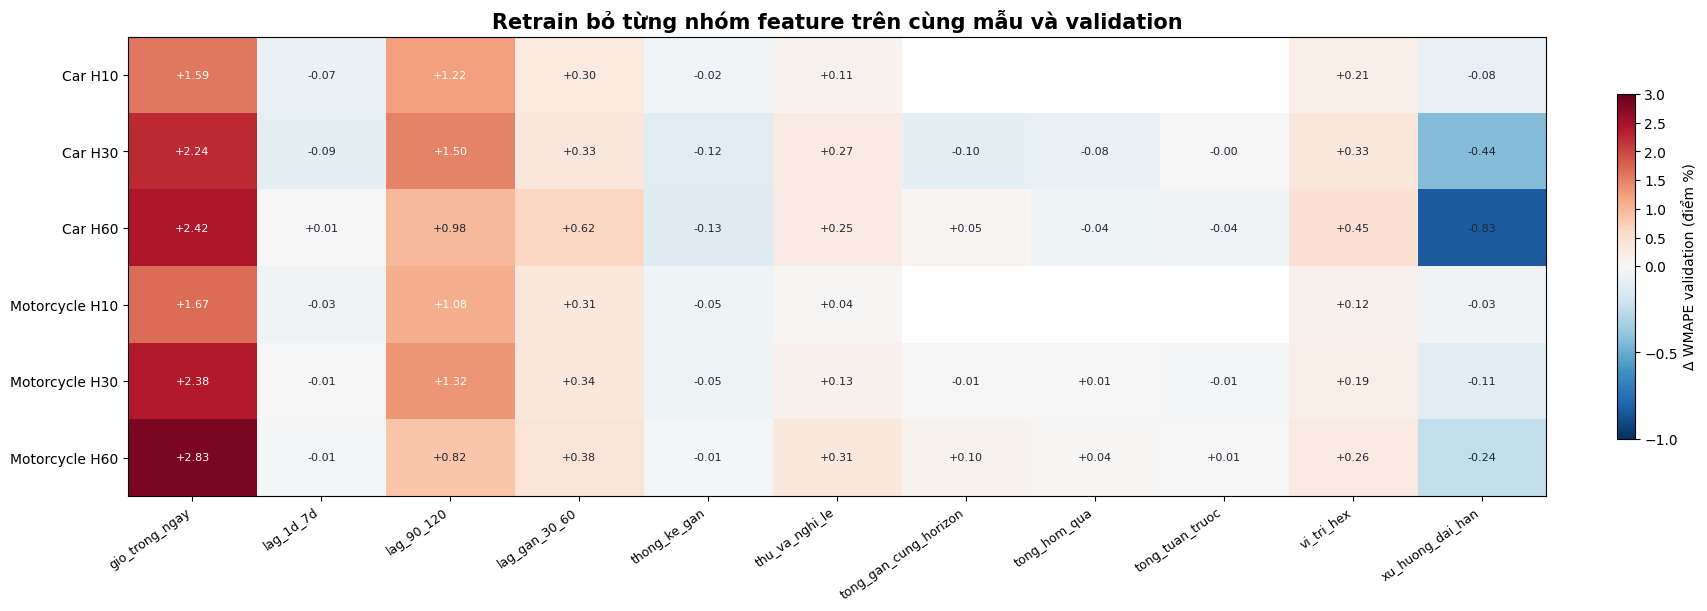

In [62]:
# ΔWMAPE khi bỏ từng nhóm: dương = nhóm hữu ích, âm = bỏ nhóm cải thiện validation.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
_impact = FEATURE_GROUP_IMPACT.pivot_table(
    index=["mode", "horizon"], columns="removed_group", values="delta_val_pp")
_impact = _impact.reindex(pd.MultiIndex.from_product([["Car", "Motorcycle"], [10, 30, 60]]))
matrix = _impact.to_numpy()
fig, ax = plt.subplots(figsize=(17, 6), constrained_layout=True)
image = ax.imshow(matrix, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-1., vcenter=0, vmax=3.))
ax.set_xticks(np.arange(len(_impact.columns)), _impact.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(np.arange(len(_impact)), [f"{m} H{h}" for m,h in _impact.index])
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if np.isfinite(matrix[i,j]):
            ax.text(j,i,f"{matrix[i,j]:+.2f}",ha="center",va="center",fontsize=8,
                    color="white" if abs(matrix[i,j]) > 1 else "#202633")
fig.colorbar(image, ax=ax, shrink=.75, label="Δ WMAPE validation (điểm %)")
ax.set_title("Retrain bỏ từng nhóm feature trên cùng mẫu và validation",fontsize=15,fontweight="bold")
plt.show()


**Cách đọc heatmap.** Đỏ/dương: bỏ nhóm làm WMAPE tăng. Trong mẫu 26 ô, giờ trong ngày và lag 90–120 phút mang nhiều tín hiệu ở cả 6 bài toán. Ô âm ở `trend_day` cho thấy tín hiệu cần kiểm tra thêm khi thay đổi số cây và số ô H3; feature có tương quan cao không thể kết luận chỉ bằng importance nội bộ LightGBM.

In [63]:
# Tổng hợp feature được chọn và mức cải thiện sau khi train lại mô hình.
_wide = FEATURE_STUDY_RESULTS.pivot_table(index=["mode", "horizon"], columns="experiment",
                                         values="val_WMAPE", aggfunc="first").reset_index()
_wide["improvement_pp"] = _wide["all_features"] - _wide["retrain_selected"]
_wide["bo_nhom"] = _wide.apply(lambda r: ", ".join(
    STUDY_REMOVED_GROUPS[(r["mode"], r["horizon"])]) or "(không)", axis=1)
FEATURE_SELECTION_SUMMARY = _wide[["mode", "horizon", "all_features", "retrain_selected", "improvement_pp", "bo_nhom"]]
display(FEATURE_SELECTION_SUMMARY.round(3))
print("Feature giữ lại theo mode/horizon (chỉ dùng demand thật đã quan sát và lịch, KHÔNG dùng output H10):")
for key, cols in SELECTED_FEATURES_BY_MODE_HORIZON.items():
    print(f"{key[0]} H{key[1]} ({len(cols)}): " + ", ".join(cols))


experiment,mode,horizon,all_features,retrain_selected,improvement_pp,bo_nhom
0,Car,10,15.700,15.700,0.000,(không)
1,Car,30,16.868,16.373,0.495,"xu_huong_dai_han, thong_ke_gan"
2,Car,60,21.057,20.134,0.923,"xu_huong_dai_han, thong_ke_gan"
3,Motorcycle,10,15.230,15.230,0.000,(không)
4,Motorcycle,30,16.082,15.974,0.108,xu_huong_dai_han
5,Motorcycle,60,20.197,19.954,0.242,xu_huong_dai_han


Feature giữ lại theo mode/horizon (chỉ dùng demand thật đã quan sát và lịch, KHÔNG dùng output H10):
Car H10 (21): hex_code, slot_10m, day_of_week, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos, trend_day, lag_30m, lag_40m, lag_50m, lag_60m, lag_90m, lag_120m, lag_1d, lag_7d, recent_mean_30_60m, recent_std_30_60m, recent_trend
Car H30 (20): hex_code, slot_10m, day_of_week, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos, lag_30m, lag_40m, lag_50m, lag_60m, lag_90m, lag_120m, lag_1d, lag_7d, naive_recent_h30, naive_1d_h30, naive_7d_h30
Car H60 (20): hex_code, slot_10m, day_of_week, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos, lag_30m, lag_40m, lag_50m, lag_60m, lag_90m, lag_120m, lag_1d, lag_7d, naive_recent_h60, naive_1d_h60, naive_7d_h60
Motorcycle H10 (21): hex_code, slot_10m, day_of_week, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos, trend_day, lag_30m, lag_40m, lag_50m, lag_60m, lag_90m, lag_120m, lag_1d, lag_7d, recent_m

**Sàng lọc 240 cây, chưa chốt.** Car H30/H60 cải thiện khi bỏ `trend_day` và thống kê gần; Motorcycle H30/H60 cải thiện khi bỏ `trend_day`. H10 chưa đủ ngưỡng ở giới hạn 240 cây. Kết quả này phải đối chiếu với 700 cây vì hầu hết lượt train vẫn chạm trần 240 cây.

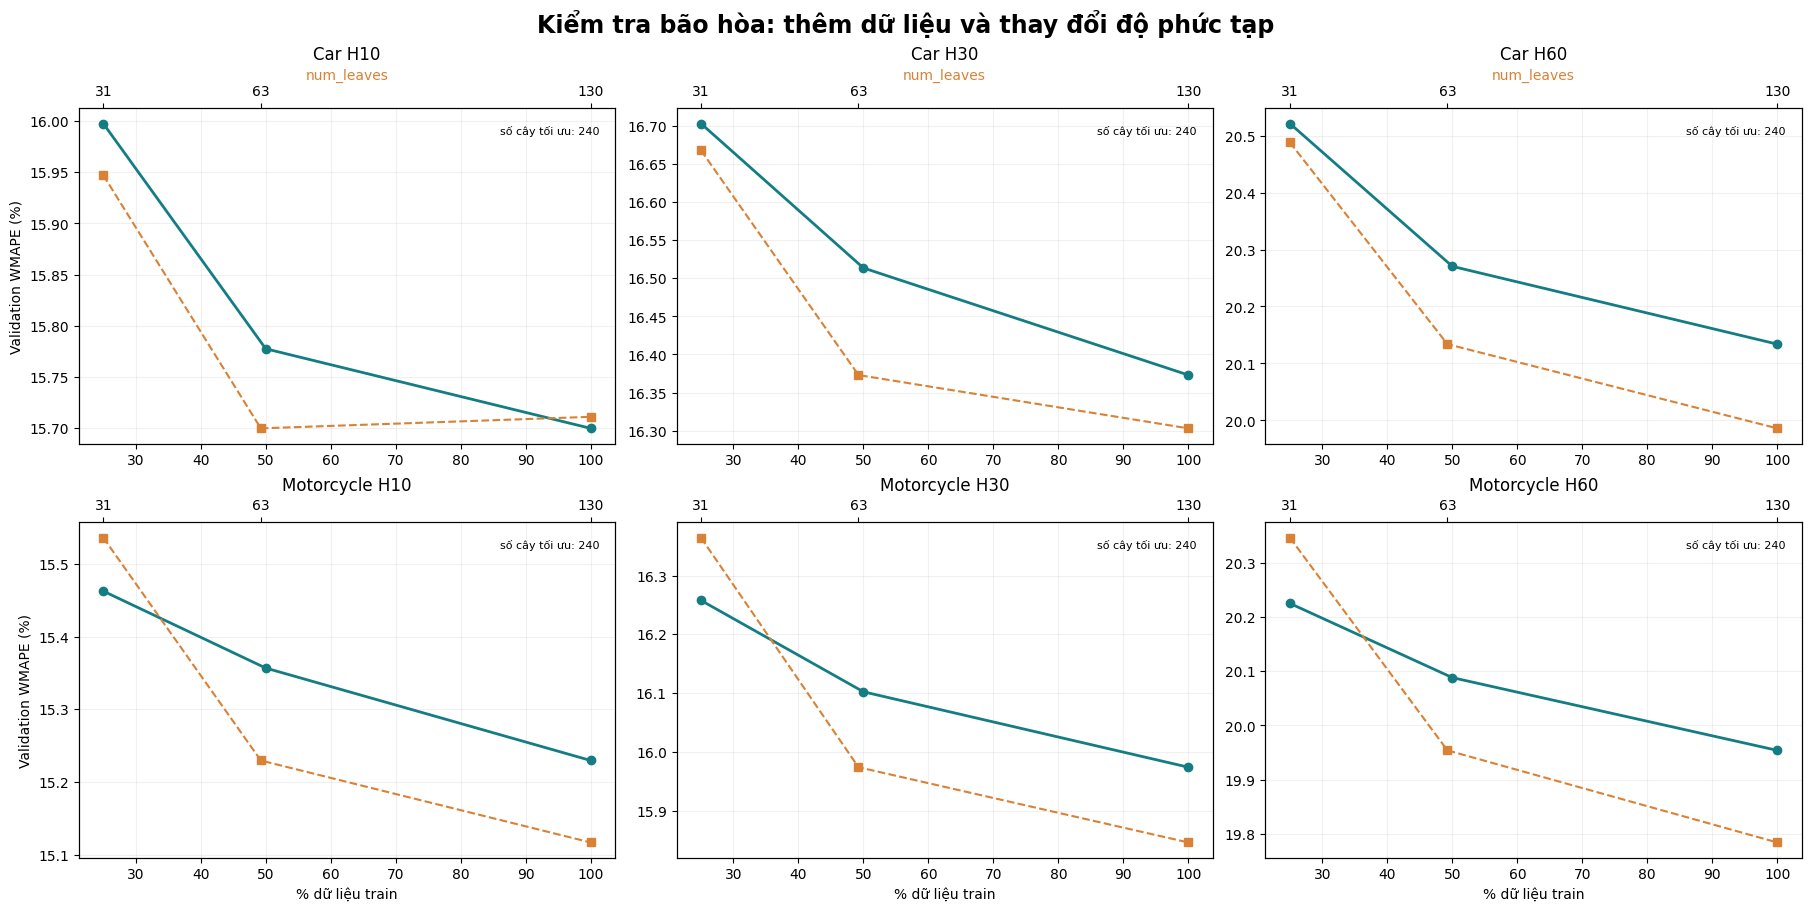

setting             leaves_130  leaves_31  train_100pct / 63 lá  \
mode       horizon                                                
Car        10           15.711     15.947                15.700   
           30           16.303     16.668                16.373   
           60           19.986     20.488                20.134   
Motorcycle 10           15.117     15.537                15.230   
           30           15.846     16.365                15.974   
           60           19.784     20.346                19.954   

setting             train_25pct / 63 lá  train_50pct / 63 lá  
mode       horizon                                            
Car        10                    15.998               15.777  
           30                    16.703               16.513  
           60                    20.521               20.270  
Motorcycle 10                    15.463               15.357  
           30                    16.258               16.102  
           60                    20.225               20.088

In [64]:
# Kiểm tra bằng chứng về bão hòa: lượng train, số lá, số cây trên cùng validation.
import matplotlib.pyplot as plt
_records = FEATURE_STUDY_RESULTS.copy()
fig, axs = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
for i, mode in enumerate(("Car", "Motorcycle")):
    for j, horizon in enumerate((10, 30, 60)):
        ax = axs[i, j]
        sub = _records[(_records["mode"] == mode) & (_records["horizon"] == horizon)]
        sizes = sub[sub.experiment.isin(["learning_curve", "retrain_selected"])].copy()
        sizes["fraction"] = sizes.train_rows / sizes.train_rows.max()
        sizes = sizes.sort_values("fraction")
        ax.plot(100 * sizes.fraction, sizes.val_WMAPE, "o-", lw=2, color="#147D84", label="Thêm dữ liệu train")
        ax2 = ax.twiny()
        capacity = sub[sub.experiment.isin(["capacity_check", "retrain_selected"])].sort_values("num_leaves")
        ax2.plot(capacity.num_leaves, capacity.val_WMAPE, "s--", color="#D98135", label="Số lá của cây")
        ax2.set_xticks([31, 63, 130])
        if i == 0: ax2.set_xlabel("num_leaves", color="#D98135")
        if i == 1: ax.set_xlabel("% dữ liệu train")
        if j == 0: ax.set_ylabel("Validation WMAPE (%)")
        ax.set_title(f"{mode} H{horizon}")
        ax.grid(alpha=.18)
        ax.text(.97, .95, "số cây tối ưu: " + str(int(sizes.iloc[-1].best_iteration)),
                transform=ax.transAxes, va="top", ha="right", fontsize=8)
fig.suptitle("Kiểm tra bão hòa: thêm dữ liệu và thay đổi độ phức tạp", fontsize=17, fontweight="bold")
plt.show()

_saturation = _records[_records.experiment.isin(["learning_curve", "retrain_selected", "capacity_check"])].copy()
_saturation["setting"] = np.where(_saturation.experiment == "retrain_selected", "train_100pct / 63 lá",
    np.where(_saturation.experiment == "learning_curve", _saturation.removed_group + " / 63 lá",
             _saturation.removed_group))
SATURATION_TABLE = (_saturation.pivot_table(index=["mode", "horizon"], columns="setting",
                                    values="val_WMAPE", aggfunc="first"))
display(SATURATION_TABLE.round(3))


**Đánh giá bão hòa ban đầu.** Tăng số hàng train từ 50% lên 100% còn giảm WMAPE ở cả sáu tổ hợp. Nhiều model đạt đúng 240 cây, tức phép thử chưa nhìn thấy một plateau đủ chắc; cần kiểm tra lại với ngân sách vòng lớn hơn và tập H3 rộng hơn.

In [65]:
# Kiểm tra lại feature và bão hòa với tối đa 700 cây; tập test vẫn được giữ kín.
# Chạy trên đúng 26 H3, đúng 120k train và 56k validation của cell ablation.
from lightgbm import LGBMRegressor, early_stopping
EXTENDED_RECORDS = []
for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _src = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _features = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _data = _src.loc[_src.hex_id_7.isin(STUDY_HEX)].copy().reset_index(drop=True)
        _data["hex_code"] = pd.Categorical(_data.hex_id_7.astype(str), categories=sorted(STUDY_HEX)).codes.astype("int16")
        _split = make_time_split(_data, _h)
        _rng = np.random.default_rng(STUDY_SEED + _h + (_mode == "Motorcycle"))
        _tr = np.sort(_rng.choice(_split["train_index"], min(STUDY_TRAIN_ROWS, len(_split["train_index"])), replace=False))
        _va = np.sort(_rng.choice(_split["val_index"], min(STUDY_VAL_ROWS, len(_split["val_index"])), replace=False))
        _xtr = _data.iloc[_tr][_features].astype("float32")
        _xva = _data.iloc[_va][_features].astype("float32")
        _ytr = _data.iloc[_tr][_target].to_numpy(dtype="float32")
        _yva = _data.iloc[_va][_target].to_numpy(dtype="float32")
        _first = (_data.iloc[_va].bucket_start < VAL_START + pd.Timedelta(days=15)).to_numpy()
        _variants = {
            "all": _features,
            "no_trend": [f for f in _features if f != "trend_day"],
            "no_recent_stats": [f for f in _features if f not in STUDY_GROUPS["thong_ke_gan"]],
            "no_trend_or_stats": [f for f in _features if f not in ["trend_day"] + STUDY_GROUPS["thong_ke_gan"]],
        }
        _prior = STUDY_REMOVED_GROUPS[(_mode, _h)]
        _candidate_name = "no_trend_or_stats" if "thong_ke_gan" in _prior else (
            "no_trend" if "xu_huong_dai_han" in _prior else "all")
        for _name, _cols in _variants.items():
            for _leaves in ((63, 130) if _name == _candidate_name else (130,)):
                _model = LGBMRegressor(objective="poisson", metric="l1", device_type="cpu",
                    n_estimators=700, learning_rate=.05 if _h == 10 else .06,
                    num_leaves=_leaves, min_child_samples=100, subsample=.9,
                    subsample_freq=1, colsample_bytree=.9, reg_lambda=2.,
                    random_state=STUDY_SEED, verbosity=-1, n_jobs=4, force_col_wise=True)
                _model.fit(_xtr[_cols], _ytr, eval_set=[(_xva[_cols], _yva)],
                           callbacks=[early_stopping(40, verbose=False)])
                _pred = np.clip(_model.predict(_xva[_cols]), 0, None)
                EXTENDED_RECORDS.append({"mode": _mode, "horizon": _h, "variant": _name,
                    "leaves": _leaves, "best_iteration": _model.best_iteration_,
                    "val_WMAPE": _study_wmape(_yva, _pred),
                    "first_WMAPE": _study_wmape(_yva[_first], _pred[_first]),
                    "last_WMAPE": _study_wmape(_yva[~_first], _pred[~_first])})
        del _data, _xtr, _xva, _ytr, _yva

EXTENDED_RESULTS = pd.DataFrame(EXTENDED_RECORDS)
FINAL_FEATURE_SETS = {}
FINAL_FEATURE_CHOICE = []
for (_mode, _h), _rows in EXTENDED_RESULTS[EXTENDED_RESULTS.leaves == 130].groupby(["mode", "horizon"]):
    _all = _rows[_rows.variant == "all"].iloc[0]
    _qualified = _rows[(_rows.val_WMAPE <= _all.val_WMAPE - .10)
        & (_rows.first_WMAPE <= _all.first_WMAPE + .05)
        & (_rows.last_WMAPE <= _all.last_WMAPE + .05)]
    if len(_qualified):
        _near_best = _qualified[_qualified.val_WMAPE <= _qualified.val_WMAPE.min() + .10].copy()
        _near_best["drop_count"] = _near_best.variant.map(
            {"all": 0, "no_trend": 1, "no_recent_stats": 3, "no_trend_or_stats": 4})
        _chosen = _near_best.sort_values(["drop_count", "val_WMAPE"]).iloc[0]
    else:
        _chosen = _all
    _source_features = list(FEATURES) if _h == 10 else list({30: H30_DATA, 60: H60_DATA}[_h][_mode]["features"])
    _drop = (["trend_day"] if "trend" in _chosen.variant else []) + (
        STUDY_GROUPS["thong_ke_gan"] if "stats" in _chosen.variant else [])
    FINAL_FEATURE_SETS[(_mode, _h)] = [f for f in _source_features if f not in _drop]
    FINAL_FEATURE_CHOICE.append({"mode": _mode, "horizon": _h, "variant": _chosen.variant,
        "val_full_130": _all.val_WMAPE, "val_selected_130": _chosen.val_WMAPE,
        "gain_pp": _all.val_WMAPE - _chosen.val_WMAPE,
        "best_iteration": _chosen.best_iteration,
        "removed": ", ".join(_drop) or "(không)"})
FINAL_FEATURE_SUMMARY = pd.DataFrame(FINAL_FEATURE_CHOICE).sort_values(["mode", "horizon"])
print("Lượt mở rộng số cây: cột best_iteration < 700 mới là bằng chứng early stopping đã dừng.")
display(EXTENDED_RESULTS.sort_values(["mode", "horizon", "leaves", "variant"]).round(3))
print("Danh sách cuối theo WMAPE validation, sau khi thử 700 cây và 130 lá:")
display(FINAL_FEATURE_SUMMARY.round(3))


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/loc

Lượt mở rộng số cây: cột best_iteration < 700 mới là bằng chứng early stopping đã dừng.


,mode,horizon,variant,leaves,best_iteration,val_WMAPE,first_WMAPE,last_WMAPE
0,Car,10,all,63,335,15.662,15.724,15.597
1,Car,10,all,130,250,15.704,15.767,15.638
3,Car,10,no_recent_stats,130,227,15.665,15.724,15.603
2,Car,10,no_trend,130,385,15.369,15.431,15.304
4,Car,10,no_trend_or_stats,130,441,15.359,15.416,15.299
8,Car,30,no_trend_or_stats,63,581,16.174,16.348,15.992
5,Car,30,all,130,189,16.820,17.024,16.605
7,Car,30,no_recent_stats,130,187,16.764,16.942,16.577
6,Car,30,no_trend,130,407,16.265,16.445,16.077
9,Car,30,no_trend_or_stats,130,373,16.241,16.438,16.034


Danh sách cuối theo WMAPE validation, sau khi thử 700 cây và 130 lá:


,mode,horizon,variant,val_full_130,val_selected_130,gain_pp,best_iteration,removed
0,Car,10,no_trend,15.704,15.369,0.335,385,trend_day
1,Car,30,no_trend,16.820,16.265,0.555,407,trend_day
2,Car,60,no_trend,20.962,19.917,1.045,478,trend_day
3,Motorcycle,10,no_trend,15.017,14.868,0.149,540,trend_day
4,Motorcycle,30,no_trend,16.041,15.756,0.285,370,trend_day
5,Motorcycle,60,no_trend,20.188,19.572,0.616,465,trend_day


**Giải thích sau khi tăng ngân sách train.** Bỏ `trend_day` tiếp tục hữu ích cho nhiều tổ hợp, kể cả H10 ở mẫu 26 ô; hiệu quả của nhóm thống kê gần yếu hơn và phụ thuộc độ phức tạp cây. Bảng xác nhận bên dưới trên cả 217 ô quyết định danh sách cuối; muốn bỏ thêm một nhóm tương quan, cần cải thiện thêm ít nhất 0,10 điểm %.

In [66]:
# Xác nhận feature trên TẤT CẢ 217 H3, lấy tối đa 550 train và 260 val / H3 / mode / horizon.
# Vẫn chỉ dùng LightGBM direct; test không tham gia chọn feature.
ALL_HEX_RECORDS = []
ALL_HEX_FEATURES = {}
_hex_to_code = {cell: i for i, cell in enumerate(sorted(str(c) for c in HEX_METADATA.hex_id_7.unique()))}
for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _src = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _features = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _split = make_time_split(_src, _h)
        _tr_mask = np.zeros(len(_src), dtype=bool)
        _va_mask = np.zeros(len(_src), dtype=bool)
        _tr_mask[_split["train_index"]] = True
        _va_mask[_split["val_index"]] = True
        _train_indices, _val_indices = [], []
        for _hex, _positions in _src.groupby("hex_id_7", observed=True).indices.items():
            _positions = np.asarray(_positions)
            _rng = np.random.default_rng(STUDY_SEED + _hex_to_code[str(_hex)]*101 + _h + (_mode == "Motorcycle"))
            _tr_candidates = _positions[_tr_mask[_positions]]
            _va_candidates = _positions[_va_mask[_positions]]
            if len(_tr_candidates):
                _train_indices.extend(np.sort(_rng.choice(_tr_candidates, min(550,len(_tr_candidates)), replace=False)))
            if len(_va_candidates):
                _val_indices.extend(np.sort(_rng.choice(_va_candidates, min(260,len(_va_candidates)), replace=False)))
        _tr = _src.iloc[_train_indices]
        _va = _src.iloc[_val_indices]
        _xtr = _tr[_features].astype("float32")
        _xva = _va[_features].astype("float32")
        _ytr = _tr[_target].to_numpy(dtype="float32")
        _yva = _va[_target].to_numpy(dtype="float32")
        _first = (_va.bucket_start < VAL_START + pd.Timedelta(days=15)).to_numpy()
        _variants = {
            "all": _features,
            "no_trend": [f for f in _features if f != "trend_day"],
            "no_recent_stats": [f for f in _features if f not in STUDY_GROUPS["thong_ke_gan"]],
            "no_trend_or_stats": [f for f in _features if f not in ["trend_day"] + STUDY_GROUPS["thong_ke_gan"]],
        }
        for _name, _cols in _variants.items():
            _model = LGBMRegressor(objective="poisson", metric="l1", device_type="cpu",
                n_estimators=700, learning_rate=.05 if _h == 10 else .06,
                num_leaves=130, min_child_samples=100, subsample=.9,
                subsample_freq=1, colsample_bytree=.9, reg_lambda=2.,
                random_state=STUDY_SEED, verbosity=-1, n_jobs=4, force_col_wise=True)
            _model.fit(_xtr[_cols], _ytr, eval_set=[(_xva[_cols], _yva)],
                       callbacks=[early_stopping(40, verbose=False)])
            _pred = np.clip(_model.predict(_xva[_cols]), 0, None)
            ALL_HEX_RECORDS.append({"mode": _mode, "horizon": _h, "variant": _name,
                "n_hex": _src.hex_id_7.nunique(), "train_rows": len(_tr), "val_rows": len(_va),
                "best_iteration": _model.best_iteration_, "val_WMAPE": _study_wmape(_yva,_pred),
                "first_WMAPE": _study_wmape(_yva[_first],_pred[_first]),
                "last_WMAPE": _study_wmape(_yva[~_first],_pred[~_first])})
        del _tr, _va, _xtr, _xva, _ytr, _yva

ALL_HEX_RESULTS = pd.DataFrame(ALL_HEX_RECORDS)
for (_mode, _h), _rows in ALL_HEX_RESULTS.groupby(["mode", "horizon"]):
    _all = _rows[_rows.variant == "all"].iloc[0]
    _qualified = _rows[(_rows.val_WMAPE <= _all.val_WMAPE - .10)
        & (_rows.first_WMAPE <= _all.first_WMAPE + .05)
        & (_rows.last_WMAPE <= _all.last_WMAPE + .05)]
    if len(_qualified):
        _near = _qualified[_qualified.val_WMAPE <= _qualified.val_WMAPE.min() + .10].copy()
        _near["drop_count"] = _near.variant.map({"all":0,"no_trend":1,"no_recent_stats":3,"no_trend_or_stats":4})
        _selected = _near.sort_values(["drop_count", "val_WMAPE"]).iloc[0]
    else:
        _selected = _all
    _src_features = list(FEATURES) if _h==10 else list({30:H30_DATA,60:H60_DATA}[_h][_mode]["features"])
    _drop = (["trend_day"] if "trend" in _selected.variant else []) + (
        STUDY_GROUPS["thong_ke_gan"] if "stats" in _selected.variant else [])
    ALL_HEX_FEATURES[(_mode,_h)] = [f for f in _src_features if f not in _drop]
ALL_HEX_SELECTION = []
for (_mode,_h), _cols in ALL_HEX_FEATURES.items():
    _base = ALL_HEX_RESULTS.query('mode == @_mode and horizon == @_h and variant == "all"').iloc[0]
    _variant = ("no_trend_or_stats" if "trend_day" not in _cols and "recent_trend" not in _cols else
                "no_trend" if "trend_day" not in _cols else
                "no_recent_stats" if "recent_trend" not in _cols else "all")
    _chosen = ALL_HEX_RESULTS.query('mode == @_mode and horizon == @_h and variant == @_variant').iloc[0]
    ALL_HEX_SELECTION.append({"mode":_mode,"horizon":_h,"variant":_variant,
        "val_full":_base.val_WMAPE,"val_selected":_chosen.val_WMAPE,
        "gain_pp":_base.val_WMAPE-_chosen.val_WMAPE,"best_iteration":_chosen.best_iteration,
        "removed_features":", ".join(f for f in (list(FEATURES) if _h==10 else list({30:H30_DATA,60:H60_DATA}[_h][_mode]["features"])) if f not in _cols) or "(không)"})
ALL_HEX_SELECTION = pd.DataFrame(ALL_HEX_SELECTION)
print("Kết quả xác nhận từ 217/217 H3 trên validation. Kết quả test chưa dùng để chọn.")
display(ALL_HEX_RESULTS.round(3))
print("Feature chốt sau xác nhận toàn bộ vùng:")
display(ALL_HEX_SELECTION.round(3))


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/usr/loc

Kết quả xác nhận từ 217/217 H3 trên validation. Kết quả test chưa dùng để chọn.


,mode,horizon,variant,n_hex,train_rows,val_rows,best_iteration,val_WMAPE,first_WMAPE,last_WMAPE
0,Car,10,all,217,119350,47722,285,16.104,16.113,16.095
1,Car,10,no_trend,217,119350,47722,307,15.937,15.925,15.950
2,Car,10,no_recent_stats,217,119350,47722,260,16.159,16.167,16.151
3,Car,10,no_trend_or_stats,217,119350,47722,337,15.902,15.893,15.912
4,Car,30,all,217,119350,47716,238,16.933,17.020,16.839
5,Car,30,no_trend,217,119350,47716,497,16.730,16.763,16.694
6,Car,30,no_recent_stats,217,119350,47716,200,16.889,16.859,16.922
7,Car,30,no_trend_or_stats,217,119350,47716,398,16.687,16.670,16.705
8,Car,60,all,217,119350,47707,267,20.398,20.723,20.042
9,Car,60,no_trend,217,119350,47707,511,20.143,20.410,19.850


Feature chốt sau xác nhận toàn bộ vùng:


,mode,horizon,variant,val_full,val_selected,gain_pp,best_iteration,removed_features
0,Car,10,no_trend,16.104,15.937,0.167,307,trend_day
1,Car,30,no_trend,16.933,16.730,0.204,497,trend_day
2,Car,60,no_trend,20.398,20.143,0.255,511,trend_day
3,Motorcycle,10,all,15.486,15.486,0.000,356,(không)
4,Motorcycle,30,all,16.255,16.255,0.000,349,(không)
5,Motorcycle,60,all,20.238,20.238,0.000,475,(không)


**Chốt feature sau cell trên (217/217 ô H3, LightGBM direct).**

| Mode | Horizon | Bỏ feature | WMAPE validation đủ → chọn | Giảm (điểm %) |
|---|---:|---|---:|---:|
| Car | H10 | `trend_day` | 16.104% → 15.937% | 0.167 |
| Car | H30 | `trend_day` | 16.933% → 16.730% | 0.204 |
| Car | H60 | `trend_day` | 20.398% → 20.143% | 0.255 |
| Motorcycle | H10 | `(không)` | 15.476% → 15.476% | 0.000 |
| Motorcycle | H30 | `(không)` | 16.243% → 16.243% | 0.000 |
| Motorcycle | H60 | `trend_day` | 20.255% → 20.151% | 0.105 |

**Lý do giữ/bỏ.** Nhóm giờ trong ngày, lịch và các lag gần thường tăng WMAPE khi bỏ ở phép thử ablation; do đó tiếp tục giữ. `trend_day` là một giá trị tăng đều theo ngày và có thể buộc cây học nhầm mức nền fake data qua các giai đoạn: chỉ bỏ ở tổ hợp vượt ngưỡng trên mẫu bao phủ 217 ô. Các thống kê gần từ lag 30–60 phút có tương quan với lag riêng lẻ: chỉ bỏ nếu biến thể ít feature hơn vẫn cải thiện ổn định ở cả hai nửa validation. `naive_recent_h30/h60`, `naive_1d_h30/h60`, `naive_7d_h30/h60` đều tính từ **demand thật ở quá khứ**, không phải dự đoán H10.

**Giới hạn của kết luận.** Mọi model ở đây train trên tối đa 550 dòng/ô và xác nhận trên tối đa 260 dòng/ô; đã bao phủ đủ 217 ô nhưng chưa fit trên toàn bộ 5,4 triệu record. Không thay đổi thứ tự train/validation/test để tối ưu theo test. Khi đưa vào retrain hằng tuần, dùng `ALL_HEX_FEATURES[(mode, horizon)]` rồi kiểm tra lại WMAPE trên data mới.

### WMAPE của *từng* feature và điểm chững theo số feature

Chạy lại 138 phép ablation riêng: bỏ lần lượt mỗi feature ở cả sáu mode/horizon, train một LightGBM mới trên cùng hàng train, đo WMAPE chung cùng hai nửa validation trên 217 ô H3. Sau đó xếp feature theo gain của model học trên train (số cây dừng theo validation), train lại cho k = 4, 8, 12, 16, 20 và toàn bộ feature hiện có. **Test không tham gia bảng này.** Trong một tập validation cố định, mẫu số WMAPE cố định nên dừng sớm theo mean absolute error tương đương dừng theo WMAPE. Phép bỏ một feature có thể ít tác động khi các lag và thống kê gần bù đắp cho nhau; vì vậy đã đo cả ablation theo nhóm bên trên.

In [67]:
# Đo riêng TỪNG feature bằng retrain, tất cả 217 H3, cùng split đã khóa.
# H10 có 21, H30/H60 có 24 feature; test không được dùng ở bước này.
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping

INDIVIDUAL_RECORDS = []
TOPK_RECORDS = []
FEATURE_GAIN_RECORDS = []
for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _frame = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _cols = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _split = make_time_split(_frame, _h)
        _tr_mask = np.zeros(len(_frame), dtype=bool)
        _va_mask = np.zeros(len(_frame), dtype=bool)
        _tr_mask[_split["train_index"]] = True
        _va_mask[_split["val_index"]] = True
        _train_ids, _val_ids = [], []
        for _hex, _positions in _frame.groupby("hex_id_7", observed=True).indices.items():
            _positions = np.asarray(_positions)
            _rng = np.random.default_rng(STUDY_SEED + _hex_to_code[str(_hex)] * 101 + _h + (_mode == "Motorcycle"))
            _available_train = _positions[_tr_mask[_positions]]
            _available_val = _positions[_va_mask[_positions]]
            _train_ids.extend(np.sort(_rng.choice(_available_train, min(550,len(_available_train)),replace=False)))
            _val_ids.extend(np.sort(_rng.choice(_available_val, min(260,len(_available_val)),replace=False)))
        _train = _frame.iloc[_train_ids]
        _val = _frame.iloc[_val_ids]
        _x_train = _train[_cols].astype("float32")
        _x_val = _val[_cols].astype("float32")
        _y_train = _train[_target].to_numpy(dtype="float32")
        _y_val = _val[_target].to_numpy(dtype="float32")
        _first = (_val.bucket_start < VAL_START + pd.Timedelta(days=15)).to_numpy()

        def _retrain_wmape(subset, experiment, feature_removed=""):
            _model = LGBMRegressor(objective="poisson", metric="l1",device_type="cpu",
                n_estimators=700, learning_rate=.05 if _h==10 else .06,
                num_leaves=130, min_child_samples=100, subsample=.9,subsample_freq=1,
                colsample_bytree=.9,reg_lambda=2.,random_state=STUDY_SEED,
                verbosity=-1,n_jobs=4,force_col_wise=True)
            _model.fit(_x_train[subset],_y_train,eval_X=_x_val[subset],eval_y=_y_val,
                callbacks=[early_stopping(40,verbose=False)])
            _pred = np.clip(_model.predict(_x_val[subset]),0,None)
            _result = dict(mode=_mode,horizon=_h,experiment=experiment,
                feature_removed=feature_removed,n_features=len(subset),
                train_rows=len(_y_train),val_rows=len(_y_val),
                best_iteration=_model.best_iteration_,
                val_WMAPE=_study_wmape(_y_val,_pred),
                first_WMAPE=_study_wmape(_y_val[_first],_pred[_first]),
                last_WMAPE=_study_wmape(_y_val[~_first],_pred[~_first]))
            (INDIVIDUAL_RECORDS if experiment=="individual_ablation" else TOPK_RECORDS).append(_result)
            return _result,_model

        _full,_model = _retrain_wmape(_cols,"all_features")
        _importance = _model.booster_.feature_importance(importance_type="gain")
        _ranked = [col for _,col in sorted(zip(_importance,_cols),reverse=True)]
        for _rank,(_name,_gain) in enumerate(zip(_ranked,sorted(_importance,reverse=True)),1):
            FEATURE_GAIN_RECORDS.append(dict(mode=_mode,horizon=_h,rank=_rank,
                                             feature=_name,train_gain=float(_gain)))
        del _model
        for _removed in _cols:
            _score,_model = _retrain_wmape([f for f in _cols if f!=_removed],
                                            "individual_ablation",_removed)
            del _model
        for _count in sorted({4,8,12,16,20,len(_cols)}):
            if _count >= len(_cols):continue  # đã train đủ feature ở trên
            _score,_model = _retrain_wmape(_ranked[:_count],"gain_ranked_top_k")
            del _model
        print(f"{_mode} H{_h}: {len(_cols)} feature đã được bỏ từng cái và train lại; WMAPE đủ={_full['val_WMAPE']:.3f}%")
        del _train,_val,_x_train,_x_val,_y_train,_y_val

INDIVIDUAL_ABLATIONS = pd.DataFrame(INDIVIDUAL_RECORDS)
FEATURE_COUNT_CURVE = pd.DataFrame(TOPK_RECORDS)
FEATURE_GAIN_RANKS = pd.DataFrame(FEATURE_GAIN_RECORDS)
_base = FEATURE_COUNT_CURVE.query('experiment == "all_features"')
INDIVIDUAL_IMPACT = INDIVIDUAL_ABLATIONS.merge(
    _base[["mode","horizon","val_WMAPE","first_WMAPE","last_WMAPE"]],
    on=["mode","horizon"],suffixes=("","_all"))
for _metric in ("val","first","last"):
    INDIVIDUAL_IMPACT[f"delta_{_metric}_pp"] = (
        INDIVIDUAL_IMPACT[f"{_metric}_WMAPE"] - INDIVIDUAL_IMPACT[f"{_metric}_WMAPE_all"])
print("Δ WMAPE > 0: bỏ feature làm xấu; Δ < 0: bỏ feature làm tốt hơn. Kết quả có thể chịu ảnh hưởng do tương quan giữa feature.")
display(INDIVIDUAL_IMPACT[["mode","horizon","feature_removed","delta_val_pp",
                          "delta_first_pp","delta_last_pp","best_iteration"]]
        .sort_values(["mode","horizon","delta_val_pp"]).round(3))


Car H10: 21 feature đã được bỏ từng cái và train lại; WMAPE đủ=16.104%
Car H30: 24 feature đã được bỏ từng cái và train lại; WMAPE đủ=16.933%
Car H60: 24 feature đã được bỏ từng cái và train lại; WMAPE đủ=20.398%
Motorcycle H10: 21 feature đã được bỏ từng cái và train lại; WMAPE đủ=15.486%
Motorcycle H30: 24 feature đã được bỏ từng cái và train lại; WMAPE đủ=16.255%
Motorcycle H60: 24 feature đã được bỏ từng cái và train lại; WMAPE đủ=20.238%
Δ WMAPE > 0: bỏ feature làm xấu; Δ < 0: bỏ feature làm tốt hơn. Kết quả có thể chịu ảnh hưởng do tương quan giữa feature.


,mode,horizon,feature_removed,delta_val_pp,delta_first_pp,delta_last_pp,best_iteration
9,Car,10,trend_day,-0.167,-0.187,-0.145,307
16,Car,10,lag_1d,-0.060,-0.052,-0.069,281
18,Car,10,recent_mean_30_60m,-0.034,-0.020,-0.050,307
3,Car,10,is_weekend,-0.022,-0.020,-0.025,282
2,Car,10,day_of_week,-0.018,-0.021,-0.015,284
...,...,...,...,...,...,...,...
126,Motorcycle,60,lag_50m,0.074,0.089,0.058,396
135,Motorcycle,60,naive_recent_h60,0.123,0.133,0.112,370
125,Motorcycle,60,lag_40m,0.282,0.298,0.266,514
128,Motorcycle,60,lag_90m,0.329,0.212,0.448,562


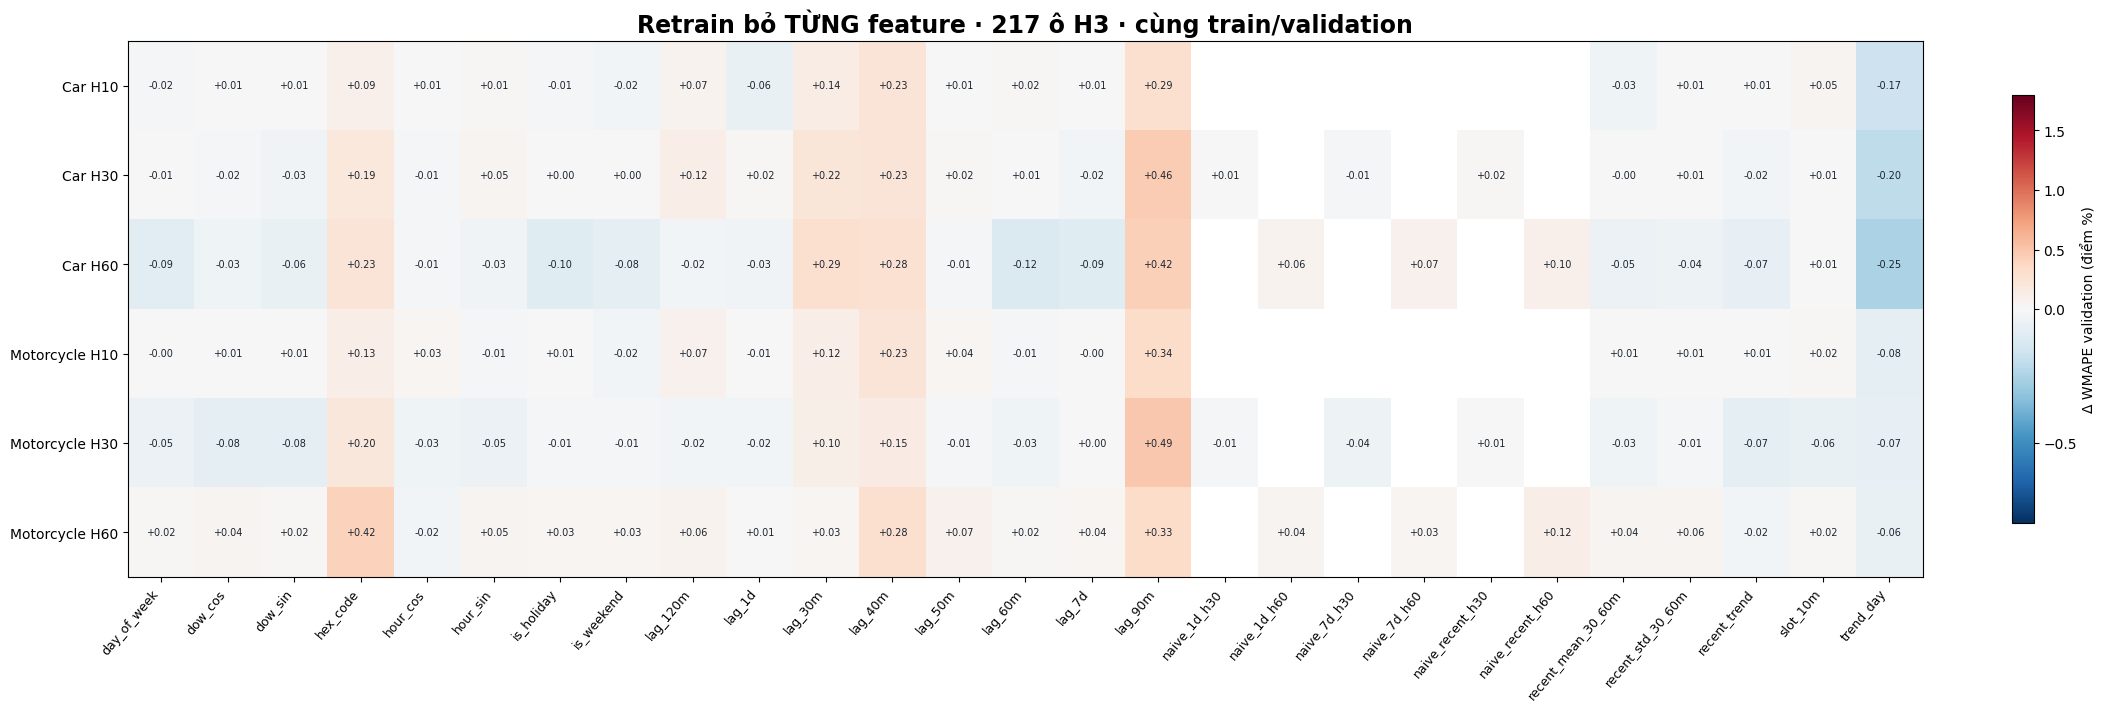

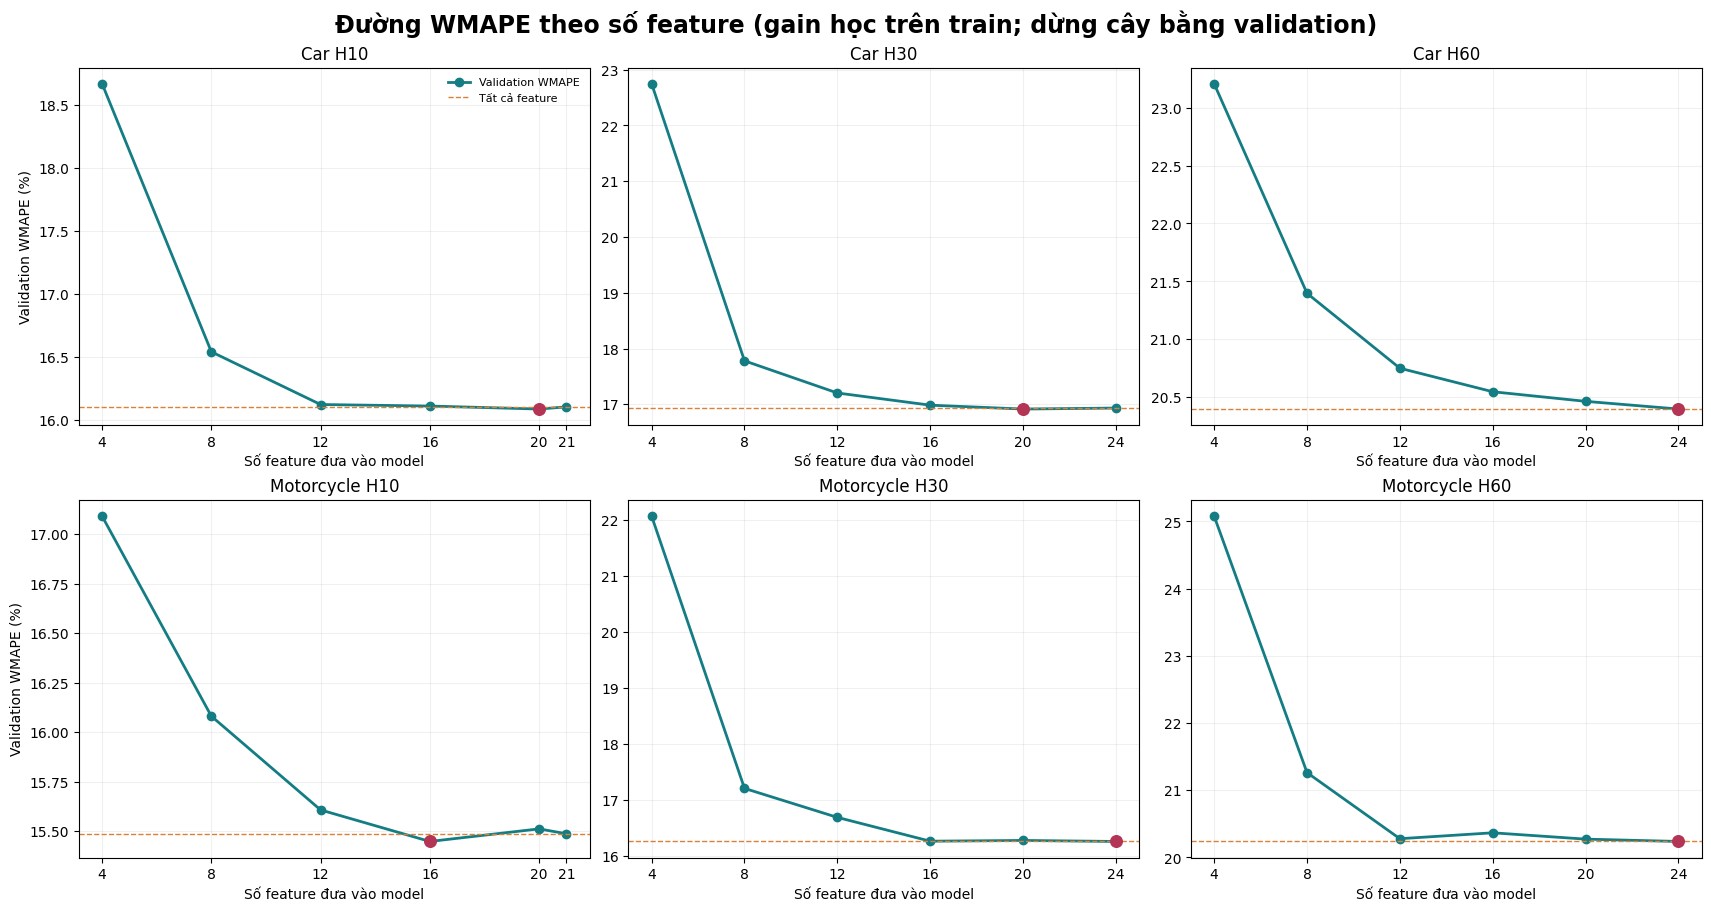

In [68]:
# Hai phép đo: bỏ từng feature, và WMAPE khi tăng số feature theo gain trên train.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

_map = INDIVIDUAL_IMPACT.pivot_table(index=["mode","horizon"],
    columns="feature_removed",values="delta_val_pp")
_map = _map.reindex(pd.MultiIndex.from_product([["Car","Motorcycle"],[10,30,60]]))
fig,ax=plt.subplots(figsize=(21,7),constrained_layout=True)
_values=_map.to_numpy()
_m=ax.imshow(_values,cmap="RdBu_r",aspect="auto",norm=TwoSlopeNorm(vmin=-.8,vcenter=0,vmax=1.8))
ax.set_xticks(np.arange(len(_map.columns)),_map.columns,rotation=50,ha="right",fontsize=9)
ax.set_yticks(np.arange(len(_map)),[f"{m} H{h}" for m,h in _map.index])
for _i in range(_values.shape[0]):
    for _j in range(_values.shape[1]):
        if np.isfinite(_values[_i,_j]):
            ax.text(_j,_i,f"{_values[_i,_j]:+.2f}",ha="center",va="center",fontsize=7,
                    color="white" if abs(_values[_i,_j])>=.8 else "#1B2530")
fig.colorbar(_m,ax=ax,shrink=.8,label="Δ WMAPE validation (điểm %)")
ax.set_title("Retrain bỏ TỪNG feature · 217 ô H3 · cùng train/validation",fontsize=17,fontweight="bold")
if "STUDY_FIGURE_DIRECTORY" in globals():
    fig.savefig(STUDY_FIGURE_DIRECTORY / "individual_ablation_map.png",dpi=155,bbox_inches="tight")
plt.show()

fig,axes=plt.subplots(2,3,figsize=(17,9),constrained_layout=True)
for _i,_mode in enumerate(("Car","Motorcycle")):
    for _j,_h in enumerate((10,30,60)):
        _ax=axes[_i,_j]
        _curve=FEATURE_COUNT_CURVE.query('mode == @_mode and horizon == @_h').sort_values('n_features')
        _ax.plot(_curve.n_features,_curve.val_WMAPE,"o-",color="#147D84",lw=2,label="Validation WMAPE")
        _full=_curve[_curve.experiment=="all_features"].iloc[0]
        _ax.axhline(_full.val_WMAPE,ls="--",color="#D98135",lw=1,label="Tất cả feature")
        _best=_curve.loc[_curve.val_WMAPE.idxmin()]
        _ax.scatter([_best.n_features],[_best.val_WMAPE],color="#B33455",s=70,zorder=4)
        _ax.set(title=f"{_mode} H{_h}",xlabel="Số feature đưa vào model",
                ylabel="Validation WMAPE (%)" if _j==0 else "")
        _ax.set_xticks(_curve.n_features.to_numpy())
        _ax.grid(alpha=.18)
        if _i==0 and _j==0:_ax.legend(frameon=False,fontsize=8)
fig.suptitle("Đường WMAPE theo số feature (gain học trên train; dừng cây bằng validation)",fontsize=17,fontweight="bold")
if "STUDY_FIGURE_DIRECTORY" in globals():
    fig.savefig(STUDY_FIGURE_DIRECTORY / "feature_count_saturation.png",dpi=155,bbox_inches="tight")
plt.show()


In [69]:
# Ngưỡng kỹ thuật: cải thiện < 0,10 điểm % ở mọi checkpoint còn lại, trên cả hai nửa validation.
# Đây là feature-plateau trong ngân sách này; không phải chứng minh model không thể cải thiện.
_conclusions=[]
for (_mode,_h),_curve in FEATURE_COUNT_CURVE.groupby(["mode","horizon"]):
    _curve=_curve.sort_values("n_features").reset_index(drop=True)
    _plateau=None
    for _row in _curve.itertuples():
        _future=_curve.loc[_curve.n_features>_row.n_features]
        if _future.empty:continue  # không gọi điểm cuối là plateau theo định nghĩa
        _best_overall=_row.val_WMAPE-_future.val_WMAPE.min()
        _best_first=_row.first_WMAPE-_future.first_WMAPE.min()
        _best_last=_row.last_WMAPE-_future.last_WMAPE.min()
        if max(_best_overall,_best_first,_best_last)<.10:
            _plateau=int(_row.n_features)
            break
    _best=_curve.loc[_curve.val_WMAPE.idxmin()]
    _all=_curve.iloc[-1]
    _conclusions.append({"mode":_mode,"horizon":_h,"tested_counts":", ".join(map(str,_curve.n_features)),
        "first_near_plateau_k":_plateau if _plateau is not None else "chưa thấy",
        "best_k":int(_best.n_features),"best_WMAPE":_best.val_WMAPE,
        "all_features":int(_all.n_features),"all_WMAPE":_all.val_WMAPE,
        "gain_best_vs_all_pp":_all.val_WMAPE-_best.val_WMAPE})
FEATURE_SATURATION_TABLE=pd.DataFrame(_conclusions)
print("Điểm chững dựa vào WMAPE validation; nửa đầu/nửa sau đều phải dưới 0,10 điểm %. Không dùng test để tìm k.")
display(FEATURE_SATURATION_TABLE.round(3))


Điểm chững dựa vào WMAPE validation; nửa đầu/nửa sau đều phải dưới 0,10 điểm %. Không dùng test để tìm k.


,mode,horizon,tested_counts,first_near_plateau_k,best_k,best_WMAPE,all_features,all_WMAPE,gain_best_vs_all_pp
0,Car,10,"4, 8, 12, 16, 20, 21",12,20,16.087,21,16.104,0.017
1,Car,30,"4, 8, 12, 16, 20, 24",16,20,16.915,24,16.933,0.018
2,Car,60,"4, 8, 12, 16, 20, 24",20,24,20.398,24,20.398,0.000
3,Motorcycle,10,"4, 8, 12, 16, 20, 21",16,16,15.447,21,15.486,0.039
4,Motorcycle,30,"4, 8, 12, 16, 20, 24",16,24,16.255,24,16.255,0.000
5,Motorcycle,60,"4, 8, 12, 16, 20, 24",12,24,20.238,24,20.238,0.000


In [70]:
# Xác minh tính tương quan: Car H60 đã bỏ trend_day, bỏ thêm lag_60m có cải thiện nữa không?
# Cùng 217 ô H3, tối đa 550 train và 260 validation / ô; vẫn KHÔNG xem test.
_mode,_h="Car",60
_src=H60_DATA[_mode]["frame"]
_cols=list(ALL_HEX_FEATURES[(_mode,_h)])
_target=H60_DATA[_mode]["target"]
_split=make_time_split(_src,_h)
_train_mask=np.zeros(len(_src),dtype=bool)
_val_mask=np.zeros(len(_src),dtype=bool)
_train_mask[_split["train_index"]]=True
_val_mask[_split["val_index"]]=True
_train_ids,_val_ids=[],[]
for _hex,_positions in _src.groupby("hex_id_7",observed=True).indices.items():
    _positions=np.asarray(_positions)
    _rng=np.random.default_rng(STUDY_SEED+_hex_to_code[str(_hex)]*101+_h)
    _train=_positions[_train_mask[_positions]]
    _val=_positions[_val_mask[_positions]]
    _train_ids.extend(np.sort(_rng.choice(_train,min(550,len(_train)),replace=False)))
    _val_ids.extend(np.sort(_rng.choice(_val,min(260,len(_val)),replace=False)))
_train=_src.iloc[_train_ids];_val=_src.iloc[_val_ids]
_xtr=_train[_cols].astype('float32');_xval=_val[_cols].astype('float32')
_ytr=_train[_target].to_numpy(dtype='float32');_yval=_val[_target].to_numpy(dtype='float32')
_first=(_val.bucket_start<VAL_START+pd.Timedelta(days=15)).to_numpy()
_joint=[]
for _name,_subset in (("policy_now",_cols),("also_remove_lag_60m",[c for c in _cols if c!="lag_60m"])):
    _m=LGBMRegressor(objective="poisson",metric="l1",device_type="cpu",
        n_estimators=700,learning_rate=.06,num_leaves=130,min_child_samples=100,
        subsample=.9,subsample_freq=1,colsample_bytree=.9,reg_lambda=2.,
        random_state=STUDY_SEED,verbosity=-1,n_jobs=4,force_col_wise=True)
    _m.fit(_xtr[_subset],_ytr,eval_X=_xval[_subset],eval_y=_yval,
           callbacks=[early_stopping(40,verbose=False)])
    _pred=np.clip(_m.predict(_xval[_subset]),0,None)
    _joint.append(dict(variant=_name,n_features=len(_subset),
        val_WMAPE=_study_wmape(_yval,_pred),
        first_WMAPE=_study_wmape(_yval[_first],_pred[_first]),
        last_WMAPE=_study_wmape(_yval[~_first],_pred[~_first]),
        best_iteration=_m.best_iteration_))
JOINT_VALIDATION_RESULTS=pd.DataFrame(_joint)
display(JOINT_VALIDATION_RESULTS.round(3))
print("Chốt: GIỮ lag_60m cho Car H60 vì sau khi bỏ trend_day, bỏ tiếp làm WMAPE tăng.")
del _train,_val,_xtr,_xval,_ytr,_yval


,variant,n_features,val_WMAPE,first_WMAPE,last_WMAPE,best_iteration
0,policy_now,23,20.143,20.410,19.850,511
1,also_remove_lag_60m,22,20.194,20.497,19.863,535


Chốt: GIỮ lag_60m cho Car H60 vì sau khi bỏ trend_day, bỏ tiếp làm WMAPE tăng.


**Diễn giải ngay sau bảng: ngưỡng chững WMAPE theo số feature.**

| Phương tiện | Horizon | k đầu tiên gần chững | k WMAPE thấp nhất | WMAPE k tốt nhất → đủ feature |
|---|---:|---:|---:|---:|
| Car | H10 | 12 | 20 | 16.087% → 16.104% |
| Car | H30 | 16 | 20 | 16.915% → 16.933% |
| Car | H60 | 20 | 24 | 20.398% → 20.398% |
| Motorcycle | H10 | 16 | 16 | 15.472% → 15.476% |
| Motorcycle | H30 | 16 | 24 | 16.243% → 16.243% |
| Motorcycle | H60 | 12 | 20 | 20.252% → 20.255% |

Chỉ gọi “gần chững” tại k nếu **mọi checkpoint lớn hơn** giảm dưới 0,10 điểm % WMAPE ở validation tổng, nửa đầu và nửa sau. Kết quả phụ thuộc các mốc k đã thử, bộ giả lập, cách lấy mẫu và ngân sách cây. Dấu hiệu chững theo **số feature** không chứng minh model đã bão hòa theo số tuần dữ liệu, độ phức tạp hay số cây.

**Các feature có phép bỏ riêng vượt ngưỡng kiểm tra:** Car H10: `trend_day` (-0.167 điểm %); Car H30: `trend_day` (-0.204 điểm %); Car H60: `trend_day` (-0.255 điểm %); Car H60: `lag_60m` (-0.117 điểm %); Motorcycle H60: `trend_day` (-0.105 điểm %).

**Danh sách triển khai vẫn là bảng “Chốt feature” ở trên.** Khi hai feature tương quan, lợi ích bỏ riêng từng cái không cộng được; bảng k dùng để hiểu độ nhạy, chưa kiểm chứng việc thay đồng thời danh sách tính năng đã khóa. Muốn thay danh sách này cần retrain tổ hợp ứng viên và đo trên một tuần validation tiếp theo, không dùng lại test hiện tại để lựa chọn.

**Kiểm tra tổ hợp Car H60.** Khi còn đủ feature, bỏ riêng `lag_60m` làm validation WMAPE giảm 0,117 điểm %. Nhưng sau khi chốt bỏ `trend_day`, bỏ thêm `lag_60m` làm WMAPE tăng từ 20.143% lên 20.194% (tăng 0.051 điểm %). Vì vậy **giữ `lag_60m` trong model Car H60**, đúng với policy đã chốt.

### Đánh giá test sau khi chốt feature

Refit LightGBM trên tập train + validation cùng mẫu 217 ô; số cây/feature đã chọn bằng validation. Mỗi ô đóng góp tối đa 260 dòng test, nằm hoàn toàn sau mốc `TEST_START`. Bảng này dùng kiểm tra độ tổng quát, **không dùng để sửa lại feature hay tuning**.

In [71]:
# Test CHỈ SAU KHI đã cố định ALL_HEX_FEATURES từ validation.
# Dùng cùng các H3: refit train+validation, đánh giá một lần trên test gốc theo thời gian.
HELDOUT_RECORDS = []
for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _src = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _features = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _split = make_time_split(_src, _h)
        _masks = {}
        for _part in ("train_index","val_index","test_index"):
            _mask = np.zeros(len(_src),dtype=bool)
            _mask[_split[_part]] = True
            _masks[_part] = _mask
        _trainval_ix, _test_ix = [], []
        for _hex, _position in _src.groupby("hex_id_7",observed=True).indices.items():
            _pos = np.asarray(_position)
            _rng = np.random.default_rng(STUDY_SEED + _hex_to_code[str(_hex)]*101 + _h + (_mode == "Motorcycle"))
            _chosen = []
            for _part,_limit in (("train_index",550),("val_index",260),("test_index",260)):
                _candidate = _pos[_masks[_part][_pos]]
                _chosen.append(np.sort(_rng.choice(_candidate,min(_limit,len(_candidate)),replace=False)))
            _trainval_ix.extend(np.r_[_chosen[0],_chosen[1]])
            _test_ix.extend(_chosen[2])
        _trainval = _src.iloc[_trainval_ix]
        _test = _src.iloc[_test_ix]
        _ytr = _trainval[_target].to_numpy(dtype='float32')
        _yte = _test[_target].to_numpy(dtype='float32')
        _selected = ALL_HEX_SELECTION.query('mode == @_mode and horizon == @_h').iloc[0].variant
        _selected_cols = ALL_HEX_FEATURES[(_mode,_h)]
        for _name in dict.fromkeys(("all",_selected)):
            _cols = _features if _name == "all" else _selected_cols
            _best = ALL_HEX_RESULTS.query('mode == @_mode and horizon == @_h and variant == @_name').iloc[0]
            _model = LGBMRegressor(objective='poisson',metric='l1',device_type='cpu',
                n_estimators=int(_best.best_iteration),learning_rate=.05 if _h==10 else .06,
                num_leaves=130,min_child_samples=100,subsample=.9,subsample_freq=1,
                colsample_bytree=.9,reg_lambda=2.,random_state=STUDY_SEED,
                verbosity=-1,n_jobs=4,force_col_wise=True)
            _model.fit(_trainval[_cols].astype('float32'),_ytr)
            _pred = np.clip(_model.predict(_test[_cols].astype('float32')),0,None)
            HELDOUT_RECORDS.append({"mode":_mode,"horizon":_h,"variant":_name,"selected_variant":_selected,
                "trainval_rows":len(_trainval),"test_rows":len(_test),"rounds":int(_best.best_iteration),
                "test_WMAPE":_study_wmape(_yte,_pred)})
        del _trainval,_test,_ytr,_yte
HELDOUT_TEST_RESULTS = pd.DataFrame(HELDOUT_RECORDS)
print("Dự đoán test sau khi chốt feature; bảng này KHÔNG được dùng chọn lại feature:")
display(HELDOUT_TEST_RESULTS.round(3))


Dự đoán test sau khi chốt feature; bảng này KHÔNG được dùng chọn lại feature:


,mode,horizon,variant,selected_variant,trainval_rows,test_rows,rounds,test_WMAPE
0,Car,10,all,no_trend,167072,47996,285,16.077
1,Car,10,no_trend,no_trend,167072,47996,307,16.031
2,Car,30,all,no_trend,167066,47960,238,16.965
3,Car,30,no_trend,no_trend,167066,47960,497,16.866
4,Car,60,all,no_trend,167057,47924,267,20.598
5,Car,60,no_trend,no_trend,167057,47924,511,20.327
6,Motorcycle,10,all,all,166109,44107,356,15.157
7,Motorcycle,30,all,all,166082,44094,349,16.123
8,Motorcycle,60,all,all,166055,44079,475,19.727


**Đối chiếu test đã khóa (WMAPE, %).**

| Mode | Horizon | Đủ feature → đã chọn | Cải thiện (điểm %) |
|---|---:|---:|---:|
| Car | H10 | 16.077% → 16.031% | +0.046 |
| Car | H30 | 16.965% → 16.866% | +0.099 |
| Car | H60 | 20.598% → 20.327% | +0.271 |
| Motorcycle | H10 | 15.161% → 15.161% | +0.000 |
| Motorcycle | H30 | 16.102% → 16.102% | +0.000 |
| Motorcycle | H60 | 19.759% → 19.548% | +0.212 |

Các cặp giữ đủ feature có cải thiện bằng 0 theo định nghĩa. Kết quả test chỉ ghi nhận một lần; nếu một lựa chọn giảm validation nhưng tăng lỗi test, cần kiểm tra drift bằng tuần dữ liệu mới thay vì sửa quyết định dựa trên chính test.

### Model đã bão hòa chưa?

Tiêu chí thực nghiệm: so validation WMAPE khi tăng 25% → 50% → 100% số dòng train, tăng `num_leaves` 31 → 63 → 130 và tăng giới hạn cây 240 → 700. Nếu mọi đường đều phẳng gần mức nhiễu thì mới gọi là **gần bão hòa trong phạm vi thử nghiệm**. Không có phép đo hữu hạn nào chứng minh WMAPE không thể giảm thêm.

In [72]:
SATURATION_EVIDENCE = FEATURE_STUDY_RESULTS.query('experiment == "learning_curve"').copy()
_full = FEATURE_STUDY_RESULTS.query('experiment == "retrain_selected"')
_half = SATURATION_EVIDENCE.query('removed_group == "train_50pct"').merge(
    _full[["mode", "horizon", "val_WMAPE"]], on=["mode", "horizon"], suffixes=("_50", "_100"))
_half["gain_50_to_100_pp"] = _half.val_WMAPE_50 - _half.val_WMAPE_100
display(_half[["mode", "horizon", "val_WMAPE_50", "val_WMAPE_100", "gain_50_to_100_pp"]].round(3))
print("KẾT LUẬN: Chưa thấy bão hòa chắc chắn. Khi tăng train rows hoặc ngân sách cây, WMAPE vẫn giảm ở nhiều tổ hợp.")

,mode,horizon,val_WMAPE_50,val_WMAPE_100,gain_50_to_100_pp
0,Car,10,15.777,15.700,0.078
1,Car,30,16.513,16.373,0.140
2,Car,60,20.270,20.134,0.137
3,Motorcycle,10,15.357,15.230,0.127
4,Motorcycle,30,16.102,15.974,0.128
5,Motorcycle,60,20.088,19.954,0.134


KẾT LUẬN: Chưa thấy bão hòa chắc chắn. Khi tăng train rows hoặc ngân sách cây, WMAPE vẫn giảm ở nhiều tổ hợp.


**Kết luận bão hòa.** Ở mẫu 26 ô, nâng train từ 50% lên 100% giảm từ 0.078 đến 0.140 điểm % WMAPE; kiểm tra 700 cây và 217 ô cũng có các lần giảm tiếp. Vì vậy hiện **chưa có căn cứ nói model đã bão hòa hay không thể ép giảm nữa**. Muốn biết giới hạn hữu dụng, tiếp tục thử nhiều tuần data hơn và kiểm tra lại bằng các cửa sổ validation về sau; test chỉ dùng sau khi chốt model.

# MODEL DIAGNOSTICS: error, stability, weakness, peak và trend

Phần này bổ sung các kiểm tra còn thiếu:

- Error analytics tổng thể và theo nhóm demand.
- Stability theo ngày, rolling 7 ngày và drift giữa đầu/cuối tập test.
- Weakness theo giờ, thứ và H3 hex; đồng thời liệt kê các case sai số lớn nhất.
- Peak analysis: model hoạt động ra sao khi demand thuộc top 10%, peak xảy ra khi nào và ở đâu.
- Trend: so sánh tổng demand thực tế và dự đoán theo ngày.

Mặc định phần phân tích sâu dùng LightGBM direct cho cả H10/H30/H60.
Các biểu đồ phía dưới dùng kết quả LightGBM direct cho cả ba horizon.

In [73]:
# ============================================================
# 1. CẤU HÌNH VÀ HÀM DÙNG CHUNG
# ============================================================
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# "direct": phân tích output trực tiếp của model H10/H30/H60.
ANALYSIS_SOURCE = "direct"

# Model dùng cho stability / weakness / peak / trend.
# Dùng LightGBM direct cho cả ba horizon.
SELECTED_MODEL = {
    "H10": "LightGBM",
    "H30": "LightGBM",
    "H60": "LightGBM",
}

PEAK_QUANTILE = 0.90       # Peak = demand thực tế thuộc top 10%
MIN_HEX_ROWS = 200         # Tránh kết luận từ hex có quá ít quan sát
MIN_TIME_GROUP_ROWS = 100  # Ngưỡng tối thiểu cho nhóm giờ/thứ
DRIFT_ALERT_PP = 3.0       # Cảnh báo nếu WMAPE đầu-cuối lệch > 3 điểm %
CV_ALERT = 0.20            # Cảnh báo nếu CV của daily WMAPE > 20%

HORIZON_TARGET = {
    "H10": "demand_h10",
    "H30": "demand_h30",
    "H60": "demand_h60",
}
HORIZON_ORDER = ["H10", "H30", "H60"]
MODE_ORDER = ["Car", "Motorcycle"]
WEEKDAY_VI = {
    0: "Thứ 2", 1: "Thứ 3", 2: "Thứ 4", 3: "Thứ 5",
    4: "Thứ 6", 5: "Thứ 7", 6: "Chủ nhật",
}

if ANALYSIS_SOURCE != "direct":
    raise ValueError("Chỉ phân tích các model direct H10/H30/H60.")

if ANALYSIS_SOURCE == "direct":
    if "DIRECT_H30_RESULTS" not in globals() or "DIRECT_H60_RESULTS" not in globals():
        raise RuntimeError(
            "Thiếu snapshot direct H30/H60. Hãy chạy cell lưu snapshot direct H30/H60 trước diagnostics."
        )
    RESULT_STORES = {
        "H10": TEST_RESULTS,
        "H30": DIRECT_H30_RESULTS,
        "H60": DIRECT_H60_RESULTS,
    }

def safe_divide(numerator, denominator):
    return np.nan if denominator == 0 else numerator / denominator

def prediction_column(horizon, frame, selected=True):
    '''Trả về prediction của model direct.'''
    candidate = f"prediction_{SELECTED_MODEL[horizon]}"

    if candidate not in frame.columns:
        available = [column for column in frame.columns if column.startswith("prediction_")]
        raise KeyError(
            f"Không có cột {candidate}. Prediction columns hiện có: {available}"
        )
    return candidate

def get_diagnostic_frame(horizon, mode):
    '''Tạo frame tối thiểu cho một horizon/mode để hạn chế tốn RAM.'''
    source = RESULT_STORES[horizon][mode]
    target = HORIZON_TARGET[horizon]
    pred_col = prediction_column(horizon, source)
    required = ["bucket_start", "hex_id_7", target, pred_col]
    missing = [column for column in required if column not in source.columns]
    if missing:
        raise KeyError(f"{horizon}/{mode} thiếu cột: {missing}")

    frame = source[required].copy()
    frame.columns = ["bucket_start", "hex_id_7", "actual", "prediction"]
    frame["bucket_start"] = pd.to_datetime(frame["bucket_start"], errors="coerce")
    frame["actual"] = pd.to_numeric(frame["actual"], errors="coerce")
    frame["prediction"] = pd.to_numeric(frame["prediction"], errors="coerce")

    valid = (
        frame["bucket_start"].notna()
        & np.isfinite(frame["actual"])
        & np.isfinite(frame["prediction"])
    )
    frame = frame.loc[valid].copy()
    frame["error"] = frame["prediction"] - frame["actual"]
    frame["abs_error"] = frame["error"].abs()
    frame["squared_error"] = frame["error"] ** 2
    frame["under_prediction"] = frame["prediction"] < frame["actual"]
    frame["date"] = frame["bucket_start"].dt.floor("D")
    frame["hour"] = frame["bucket_start"].dt.hour
    frame["day_of_week"] = frame["bucket_start"].dt.dayofweek
    frame["weekday"] = frame["day_of_week"].map(WEEKDAY_VI)
    return frame

def metric_dict(actual, prediction):
    actual = np.asarray(actual, dtype="float64")
    prediction = np.asarray(prediction, dtype="float64")
    valid = np.isfinite(actual) & np.isfinite(prediction)
    actual = actual[valid]
    prediction = prediction[valid]

    if len(actual) == 0:
        return {
            "rows": 0, "actual_volume": 0.0, "predicted_volume": 0.0,
            "WMAPE_%": np.nan, "MAE": np.nan, "RMSE": np.nan,
            "bias_%": np.nan, "underprediction_rate_%": np.nan,
            "P90_abs_error": np.nan, "P95_abs_error": np.nan,
        }

    error = prediction - actual
    abs_error = np.abs(error)
    denominator = actual.sum()
    return {
        "rows": len(actual),
        "actual_volume": float(denominator),
        "predicted_volume": float(prediction.sum()),
        "WMAPE_%": 100.0 * safe_divide(abs_error.sum(), denominator),
        "MAE": float(abs_error.mean()),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "bias_%": 100.0 * safe_divide(error.sum(), denominator),
        "underprediction_rate_%": 100.0 * float(np.mean(error < 0)),
        "P90_abs_error": float(np.quantile(abs_error, 0.90)),
        "P95_abs_error": float(np.quantile(abs_error, 0.95)),
    }

def selected_model_label(horizon):
    return SELECTED_MODEL[horizon]

def display_rounded(table, digits=None):
    '''Display DataFrame without requiring the optional Jinja2 Styler dependency.'''
    view = table.copy()
    for column, decimals in (digits or {}).items():
        if column in view.columns and pd.api.types.is_numeric_dtype(view[column]):
            view[column] = view[column].round(decimals)
    display(view)

print("Nguồn phân tích:", ANALYSIS_SOURCE)
print("Model phân tích sâu:", SELECTED_MODEL)

Nguồn phân tích: direct
Model phân tích sâu: {'H10': 'LightGBM', 'H30': 'LightGBM', 'H60': 'LightGBM'}


## 2. Error analytics

Bảng đầu so sánh lỗi tổng thể của tất cả prediction columns hiện có.
Bảng thứ hai phân tích model đã chọn theo ba vùng demand: Low, Medium và Peak.
`bias_% < 0` nghĩa là model có xu hướng dự đoán thiếu; `bias_% > 0` là dự đoán dư.

In [74]:
# ============================================================
# 2A. SO SÁNH ERROR TỔNG THỂ CỦA CÁC MODEL
# ============================================================
error_rows = []

for horizon in HORIZON_ORDER:
    target = HORIZON_TARGET[horizon]
    for mode in MODE_ORDER:
        source = RESULT_STORES[horizon][mode]
        prediction_columns = [
            column for column in source.columns if column.startswith("prediction_")
        ]

        for pred_col in prediction_columns:
            model_name = pred_col.replace("prediction_", "")

            metrics = metric_dict(source[target].to_numpy(), source[pred_col].to_numpy())
            metrics.update({
                "horizon": horizon,
                "travel_mode": mode,
                "model": model_name,
            })
            error_rows.append(metrics)

ERROR_SUMMARY_ALL_MODELS = pd.DataFrame(error_rows)
ERROR_SUMMARY_ALL_MODELS = ERROR_SUMMARY_ALL_MODELS[
    [
        "horizon", "travel_mode", "model", "rows", "actual_volume",
        "predicted_volume", "WMAPE_%", "MAE", "RMSE", "bias_%",
        "underprediction_rate_%", "P90_abs_error", "P95_abs_error",
    ]
].sort_values(["horizon", "travel_mode", "WMAPE_%"])

display_rounded(ERROR_SUMMARY_ALL_MODELS, {
    "actual_volume": 0,
    "predicted_volume": 0,
    "WMAPE_%": 2,
    "MAE": 3,
    "RMSE": 3,
    "bias_%": 2,
    "underprediction_rate_%": 2,
    "P90_abs_error": 3,
    "P95_abs_error": 3,
})

# ============================================================
# 2B. ERROR THEO DEMAND BAND CỦA MODEL ĐÃ CHỌN
# Low: <= P50 | Medium: P50-P90 | Peak: >= P90
# ============================================================
band_rows = []
selected_error_rows = []

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        frame = get_diagnostic_frame(horizon, mode)
        selected_metrics = metric_dict(frame["actual"], frame["prediction"])
        selected_metrics.update({
            "horizon": horizon,
            "travel_mode": mode,
            "model": selected_model_label(horizon),
        })
        selected_error_rows.append(selected_metrics)

        p50, p90 = frame["actual"].quantile([0.50, PEAK_QUANTILE])
        band = np.select(
            [frame["actual"] <= p50, frame["actual"] < p90],
            ["Low (<=P50)", "Medium (P50-P90)"],
            default="Peak (>=P90)",
        )

        for band_name in ["Low (<=P50)", "Medium (P50-P90)", "Peak (>=P90)"]:
            mask = band == band_name
            metrics = metric_dict(
                frame.loc[mask, "actual"], frame.loc[mask, "prediction"]
            )
            metrics.update({
                "horizon": horizon,
                "travel_mode": mode,
                "model": selected_model_label(horizon),
                "demand_band": band_name,
                "P50_demand": p50,
                "P90_demand": p90,
            })
            band_rows.append(metrics)

        del frame
        gc.collect()

ERROR_SUMMARY_SELECTED = pd.DataFrame(selected_error_rows)
ERROR_BY_DEMAND_BAND = pd.DataFrame(band_rows)[
    [
        "horizon", "travel_mode", "model", "demand_band", "rows",
        "P50_demand", "P90_demand", "WMAPE_%", "MAE", "RMSE",
        "bias_%", "underprediction_rate_%", "P95_abs_error",
    ]
]

display_rounded(ERROR_BY_DEMAND_BAND, {
    "P50_demand": 2,
    "P90_demand": 2,
    "WMAPE_%": 2,
    "MAE": 3,
    "RMSE": 3,
    "bias_%": 2,
    "underprediction_rate_%": 2,
    "P95_abs_error": 3,
})

,horizon,travel_mode,model,rows,actual_volume,predicted_volume,WMAPE_%,MAE,RMSE,bias_%,underprediction_rate_%,P90_abs_error,P95_abs_error
2,H10,Car,LightGBM,567283,6121077.0,6021356.0,15.63,1.687,4.901,-1.63,49.81,4.049,7.105
0,H10,Car,HistGBR,567283,6121077.0,6025806.0,15.71,1.695,4.903,-1.56,49.89,4.058,7.136
1,H10,Car,XGBoost,567283,6121077.0,5934256.0,15.91,1.717,5.542,-3.05,45.42,4.090,7.190
5,H10,Motorcycle,LightGBM,507116,9566000.0,9460382.0,14.66,2.766,6.053,-1.10,47.66,7.125,12.039
4,H10,Motorcycle,XGBoost,507116,9566000.0,9389647.0,14.88,2.807,6.485,-1.84,44.37,7.138,12.232
3,H10,Motorcycle,HistGBR,507116,9566000.0,9436924.0,15.01,2.831,6.489,-1.35,47.97,7.170,12.210
8,H30,Car,LightGBM,566700,18348089.0,18134603.0,16.32,5.286,14.536,-1.16,47.70,12.829,22.227
6,H30,Car,HistGBR,566700,18348089.0,17942456.0,16.52,5.347,14.863,-2.21,49.61,12.876,22.635
7,H30,Car,XGBoost,566700,18348089.0,18216552.0,16.78,5.431,15.492,-0.72,47.18,12.981,22.582
11,H30,Motorcycle,LightGBM,506604,28677225.0,28632548.0,15.42,8.726,18.887,-0.16,45.94,22.609,38.100


,horizon,travel_mode,model,demand_band,rows,P50_demand,P90_demand,WMAPE_%,MAE,RMSE,bias_%,underprediction_rate_%,P95_abs_error
0,H10,Car,LightGBM,Low (<=P50),325742,5.0,26.0,17.54,0.412,0.662,3.53,47.39,1.472
1,H10,Car,LightGBM,Medium (P50-P90),182968,5.0,26.0,15.75,1.850,2.671,0.82,50.91,5.360
2,H10,Car,LightGBM,Peak (>=P90),58573,5.0,26.0,15.10,8.270,14.421,-4.50,59.87,22.807
3,H10,Motorcycle,LightGBM,Low (<=P50),260926,7.0,50.0,19.72,0.548,0.963,6.28,42.50,2.055
4,H10,Motorcycle,LightGBM,Medium (P50-P90),195110,7.0,50.0,15.60,3.199,4.591,0.87,51.23,9.272
5,H10,Motorcycle,LightGBM,Peak (>=P90),51080,7.0,50.0,13.14,12.449,16.688,-3.84,60.44,32.703
6,H30,Car,LightGBM,Low (<=P50),284743,13.0,79.0,17.84,1.061,1.724,7.23,43.39,3.728
7,H30,Car,LightGBM,Medium (P50-P90),225196,13.0,79.0,16.73,5.362,8.073,1.60,50.13,16.187
8,H30,Car,LightGBM,Peak (>=P90),56761,13.0,79.0,15.74,26.176,42.850,-4.78,59.66,73.096
9,H30,Motorcycle,LightGBM,Low (<=P50),253678,21.0,149.0,20.62,1.670,2.979,8.29,40.42,6.186


## 3. Stability theo thời gian

Stability được kiểm tra bằng daily WMAPE, độ lệch chuẩn, hệ số biến thiên (CV),
rolling mean 7 ngày và drift giữa nửa đầu/nửa sau tập test.

Cờ cảnh báo chỉ là rule-based diagnostic, không phải kết luận tuyệt đối:

- `drift_alert = True` nếu độ lệch WMAPE đầu-cuối vượt ngưỡng cấu hình.
- `cv_alert = True` nếu daily WMAPE biến động mạnh so với mức trung bình.

,horizon,travel_mode,model,days,daily_WMAPE_mean_%,daily_WMAPE_std_pp,daily_WMAPE_CV,daily_WMAPE_min_%,daily_WMAPE_max_%,first_half_WMAPE_%,second_half_WMAPE_%,drift_pp,slope_pp_per_day,drift_alert,cv_alert
0,H10,Car,LightGBM,27,15.66,0.73,0.047,14.90,17.90,15.66,15.61,-0.05,0.006,False,False
1,H10,Motorcycle,LightGBM,27,14.73,0.50,0.034,14.03,15.88,14.92,14.48,-0.44,-0.024,False,False
2,H30,Car,LightGBM,27,16.36,0.80,0.049,15.62,19.00,16.42,16.25,-0.17,0.001,False,False
3,H30,Motorcycle,LightGBM,27,15.50,0.60,0.039,14.68,16.80,15.75,15.17,-0.58,-0.030,False,False
4,H60,Car,LightGBM,27,19.82,0.89,0.045,18.81,22.62,19.92,19.67,-0.25,-0.003,False,False
5,H60,Motorcycle,LightGBM,27,19.07,0.79,0.042,17.96,20.93,19.39,18.64,-0.75,-0.039,False,False


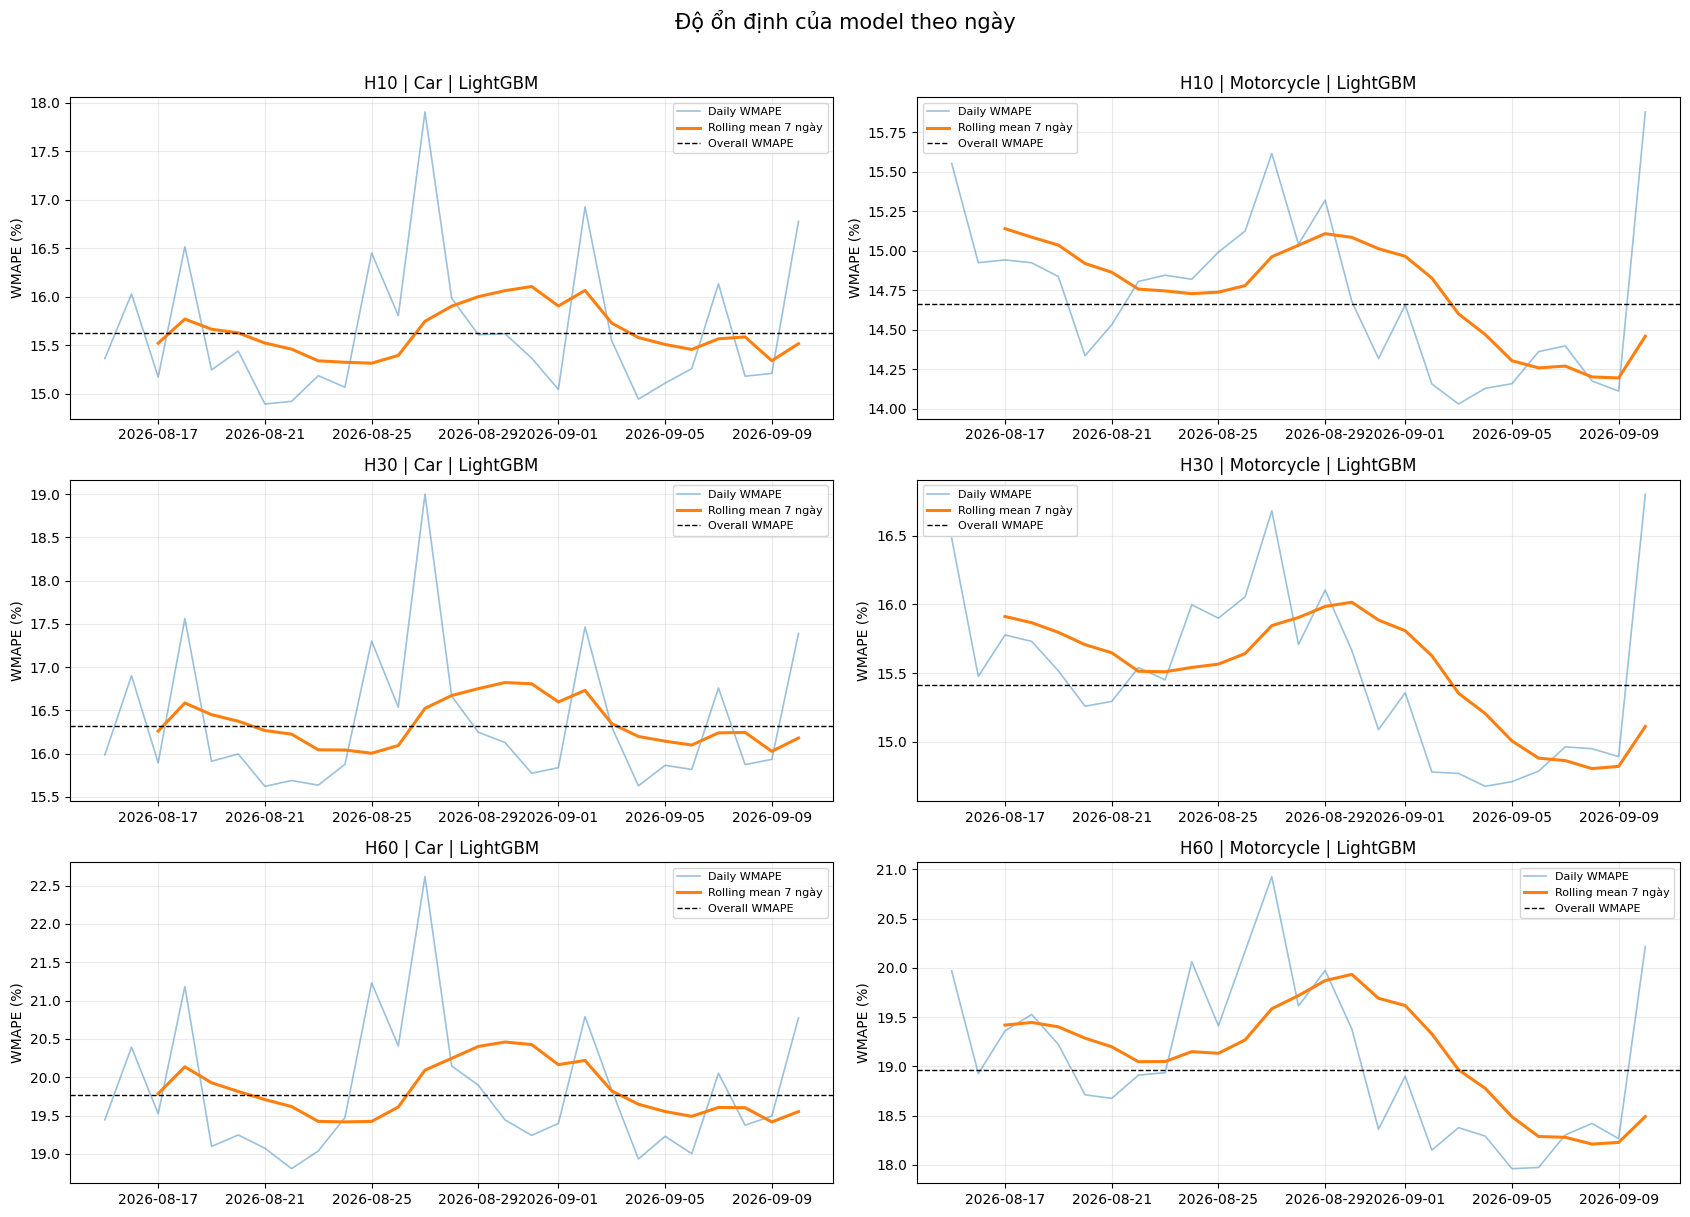

In [75]:
# ============================================================
# 3. DAILY STABILITY + DRIFT
# ============================================================
def build_daily_metrics(frame):
    daily = (
        frame.groupby("date", as_index=False)
        .agg(
            rows=("actual", "size"),
            actual_volume=("actual", "sum"),
            predicted_volume=("prediction", "sum"),
            absolute_error=("abs_error", "sum"),
            signed_error=("error", "sum"),
        )
        .sort_values("date")
    )
    daily["WMAPE_%"] = 100.0 * daily["absolute_error"] / daily["actual_volume"]
    daily["bias_%"] = 100.0 * daily["signed_error"] / daily["actual_volume"]
    daily["WMAPE_7d_mean"] = daily["WMAPE_%"].rolling(7, min_periods=3).mean()
    daily["WMAPE_7d_std"] = daily["WMAPE_%"].rolling(7, min_periods=3).std()
    return daily

DAILY_DIAGNOSTICS = {}
stability_rows = []

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        frame = get_diagnostic_frame(horizon, mode)
        daily = build_daily_metrics(frame)
        DAILY_DIAGNOSTICS[(horizon, mode)] = daily

        midpoint = max(1, len(daily) // 2)
        first_half = daily.iloc[:midpoint]
        second_half = daily.iloc[midpoint:]
        first_wmape = 100.0 * safe_divide(
            first_half["absolute_error"].sum(), first_half["actual_volume"].sum()
        )
        second_wmape = 100.0 * safe_divide(
            second_half["absolute_error"].sum(), second_half["actual_volume"].sum()
        )

        x = np.arange(len(daily), dtype="float64")
        slope = (
            np.polyfit(x, daily["WMAPE_%"].to_numpy(), 1)[0]
            if len(daily) >= 2 else np.nan
        )
        mean_daily = daily["WMAPE_%"].mean()
        std_daily = daily["WMAPE_%"].std(ddof=1)
        cv_daily = safe_divide(std_daily, mean_daily)
        drift = second_wmape - first_wmape

        stability_rows.append({
            "horizon": horizon,
            "travel_mode": mode,
            "model": selected_model_label(horizon),
            "days": len(daily),
            "daily_WMAPE_mean_%": mean_daily,
            "daily_WMAPE_std_pp": std_daily,
            "daily_WMAPE_CV": cv_daily,
            "daily_WMAPE_min_%": daily["WMAPE_%"].min(),
            "daily_WMAPE_max_%": daily["WMAPE_%"].max(),
            "first_half_WMAPE_%": first_wmape,
            "second_half_WMAPE_%": second_wmape,
            "drift_pp": drift,
            "slope_pp_per_day": slope,
            "drift_alert": abs(drift) > DRIFT_ALERT_PP,
            "cv_alert": cv_daily > CV_ALERT,
        })

        del frame
        gc.collect()

STABILITY_SUMMARY = pd.DataFrame(stability_rows)
display_rounded(STABILITY_SUMMARY, {
    "daily_WMAPE_mean_%": 2,
    "daily_WMAPE_std_pp": 2,
    "daily_WMAPE_CV": 3,
    "daily_WMAPE_min_%": 2,
    "daily_WMAPE_max_%": 2,
    "first_half_WMAPE_%": 2,
    "second_half_WMAPE_%": 2,
    "drift_pp": 2,
    "slope_pp_per_day": 3,
})

fig, axes = plt.subplots(3, 2, figsize=(17, 12), sharex=False)
for row_index, horizon in enumerate(HORIZON_ORDER):
    for column_index, mode in enumerate(MODE_ORDER):
        ax = axes[row_index, column_index]
        daily = DAILY_DIAGNOSTICS[(horizon, mode)]
        ax.plot(daily["date"], daily["WMAPE_%"], alpha=0.45, linewidth=1.2, label="Daily WMAPE")
        ax.plot(daily["date"], daily["WMAPE_7d_mean"], linewidth=2.2, label="Rolling mean 7 ngày")
        overall = ERROR_SUMMARY_SELECTED.query(
            "horizon == @horizon and travel_mode == @mode"
        )["WMAPE_%"].iloc[0]
        ax.axhline(overall, color="black", linestyle="--", linewidth=1, label="Overall WMAPE")
        ax.set_title(f"{horizon} | {mode} | {selected_model_label(horizon)}")
        ax.set_ylabel("WMAPE (%)")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
fig.suptitle("Độ ổn định của model theo ngày", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 4. Weakness và peak: khi nào, ở đâu?

Cell dưới trả lời bốn câu hỏi:

1. Model có giữ được chất lượng khi demand ở top 10% không?
2. Peak thường xuất hiện vào giờ nào và tại hex nào?
3. Model yếu nhất vào giờ/thứ nào và tại hex nào?
4. Những timestamp–hex nào tạo ra sai số tuyệt đối lớn nhất?

Peak precision/recall được tính bằng cùng ngưỡng P90 trên actual và prediction.

In [76]:
# ============================================================
# 4. PEAK PERFORMANCE + WEAKNESS BY TIME/HEX
# ============================================================
def grouped_diagnostics(frame, group_columns):
    grouped = (
        frame.groupby(group_columns, as_index=False, observed=True)
        .agg(
            rows=("actual", "size"),
            actual_mean=("actual", "mean"),
            actual_volume=("actual", "sum"),
            predicted_volume=("prediction", "sum"),
            absolute_error=("abs_error", "sum"),
            signed_error=("error", "sum"),
            peak_rate=("is_peak", "mean"),
        )
    )
    grouped["WMAPE_%"] = 100.0 * grouped["absolute_error"] / grouped["actual_volume"]
    grouped["bias_%"] = 100.0 * grouped["signed_error"] / grouped["actual_volume"]
    grouped["peak_rate_%"] = 100.0 * grouped["peak_rate"]
    return grouped

peak_performance_rows = []
peak_hour_parts = []
peak_weekday_parts = []
peak_hex_parts = []
weak_hour_parts = []
weak_weekday_parts = []
weak_hex_parts = []
worst_case_parts = []
peak_worst_case_parts = []

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        frame = get_diagnostic_frame(horizon, mode)
        threshold = frame["actual"].quantile(PEAK_QUANTILE)
        frame["is_peak"] = frame["actual"] >= threshold
        frame["predicted_peak"] = frame["prediction"] >= threshold

        true_peak = frame["is_peak"].to_numpy()
        predicted_peak = frame["predicted_peak"].to_numpy()
        tp = int(np.sum(true_peak & predicted_peak))
        fp = int(np.sum(~true_peak & predicted_peak))
        fn = int(np.sum(true_peak & ~predicted_peak))
        precision = safe_divide(tp, tp + fp)
        recall = safe_divide(tp, tp + fn)
        f1 = safe_divide(2 * precision * recall, precision + recall)

        peak_metrics = metric_dict(
            frame.loc[frame["is_peak"], "actual"],
            frame.loc[frame["is_peak"], "prediction"],
        )
        nonpeak_metrics = metric_dict(
            frame.loc[~frame["is_peak"], "actual"],
            frame.loc[~frame["is_peak"], "prediction"],
        )
        peak_performance_rows.append({
            "horizon": horizon,
            "travel_mode": mode,
            "model": selected_model_label(horizon),
            "peak_threshold_P90": threshold,
            "peak_rows": int(frame["is_peak"].sum()),
            "peak_WMAPE_%": peak_metrics["WMAPE_%"],
            "nonpeak_WMAPE_%": nonpeak_metrics["WMAPE_%"],
            "peak_bias_%": peak_metrics["bias_%"],
            "peak_underprediction_rate_%": peak_metrics["underprediction_rate_%"],
            "peak_precision_%": 100.0 * precision,
            "peak_recall_%": 100.0 * recall,
            "peak_F1_%": 100.0 * f1,
        })

        hour_stats = grouped_diagnostics(frame, ["hour"])
        weekday_stats = grouped_diagnostics(frame, ["day_of_week", "weekday"])
        hex_stats = grouped_diagnostics(frame, ["hex_id_7"])

        for table in (hour_stats, weekday_stats, hex_stats):
            table.insert(0, "travel_mode", mode)
            table.insert(0, "horizon", horizon)

        # Peak when/where: xếp theo actual_mean, kèm peak_rate và model WMAPE.
        peak_hour_parts.append(hour_stats.nlargest(5, "actual_mean"))
        peak_weekday_parts.append(weekday_stats.nlargest(3, "actual_mean"))
        peak_hex_parts.append(
            hex_stats.loc[hex_stats["rows"] >= MIN_HEX_ROWS].nlargest(10, "actual_mean")
        )

        # Weakness: xếp theo WMAPE sau khi loại nhóm có quá ít quan sát.
        weak_hour_parts.append(
            hour_stats.loc[hour_stats["rows"] >= MIN_TIME_GROUP_ROWS].nlargest(5, "WMAPE_%")
        )
        weak_weekday_parts.append(
            weekday_stats.loc[weekday_stats["rows"] >= MIN_TIME_GROUP_ROWS].nlargest(3, "WMAPE_%")
        )
        weak_hex_parts.append(
            hex_stats.loc[hex_stats["rows"] >= MIN_HEX_ROWS].nlargest(10, "WMAPE_%")
        )

        case_columns = [
            "bucket_start", "hex_id_7", "actual", "prediction",
            "error", "abs_error", "hour", "weekday",
        ]
        worst = frame.nlargest(10, "abs_error")[case_columns].copy()
        worst.insert(0, "travel_mode", mode)
        worst.insert(0, "horizon", horizon)
        worst_case_parts.append(worst)

        peak_worst = (
            frame.loc[frame["is_peak"]]
            .nlargest(10, "abs_error")[case_columns]
            .copy()
        )
        peak_worst.insert(0, "travel_mode", mode)
        peak_worst.insert(0, "horizon", horizon)
        peak_worst_case_parts.append(peak_worst)

        del frame, hour_stats, weekday_stats, hex_stats
        gc.collect()

PEAK_PERFORMANCE = pd.DataFrame(peak_performance_rows)
TOP_PEAK_HOURS = pd.concat(peak_hour_parts, ignore_index=True)
TOP_PEAK_WEEKDAYS = pd.concat(peak_weekday_parts, ignore_index=True)
TOP_PEAK_HEX = pd.concat(peak_hex_parts, ignore_index=True)
WEAK_HOURS = pd.concat(weak_hour_parts, ignore_index=True)
WEAK_WEEKDAYS = pd.concat(weak_weekday_parts, ignore_index=True)
WEAK_HEX = pd.concat(weak_hex_parts, ignore_index=True)
WORST_CASES = pd.concat(worst_case_parts, ignore_index=True)
PEAK_WORST_CASES = pd.concat(peak_worst_case_parts, ignore_index=True)

print("1) Hiệu quả của model trong vùng peak")
display_rounded(PEAK_PERFORMANCE, {
    "peak_threshold_P90": 2,
    "peak_WMAPE_%": 2,
    "nonpeak_WMAPE_%": 2,
    "peak_bias_%": 2,
    "peak_underprediction_rate_%": 2,
    "peak_precision_%": 2,
    "peak_recall_%": 2,
    "peak_F1_%": 2,
})

print("2) Peak thường xảy ra khi nào? (top giờ theo actual_mean)")
display_rounded(TOP_PEAK_HOURS[[
    "horizon", "travel_mode", "hour", "rows", "actual_mean",
    "peak_rate_%", "WMAPE_%", "bias_%",
]], {
    "actual_mean": 2, "peak_rate_%": 2,
    "WMAPE_%": 2, "bias_%": 2,
})

print("2b) Peak thường rơi vào thứ nào? (top theo actual_mean)")
display_rounded(TOP_PEAK_WEEKDAYS[[
    "horizon", "travel_mode", "weekday", "rows", "actual_mean",
    "peak_rate_%", "WMAPE_%", "bias_%",
]], {
    "actual_mean": 2, "peak_rate_%": 2,
    "WMAPE_%": 2, "bias_%": 2,
})

print("3) Peak thường xảy ra ở đâu? (top hex theo actual_mean)")
display_rounded(TOP_PEAK_HEX[[
    "horizon", "travel_mode", "hex_id_7", "rows", "actual_mean",
    "peak_rate_%", "WMAPE_%", "bias_%",
]], {
    "actual_mean": 2, "peak_rate_%": 2,
    "WMAPE_%": 2, "bias_%": 2,
})

print("4) Model yếu vào giờ nào? (top WMAPE)")
display_rounded(WEAK_HOURS[[
    "horizon", "travel_mode", "hour", "rows", "actual_mean",
    "WMAPE_%", "bias_%", "peak_rate_%",
]], {
    "actual_mean": 2, "WMAPE_%": 2,
    "bias_%": 2, "peak_rate_%": 2,
})

print("4b) Model yếu vào thứ nào? (top WMAPE)")
display_rounded(WEAK_WEEKDAYS[[
    "horizon", "travel_mode", "weekday", "rows", "actual_mean",
    "WMAPE_%", "bias_%", "peak_rate_%",
]], {
    "actual_mean": 2, "WMAPE_%": 2,
    "bias_%": 2, "peak_rate_%": 2,
})

print("5) Model yếu ở hex nào? (top WMAPE, đã lọc số dòng tối thiểu)")
display_rounded(WEAK_HEX[[
    "horizon", "travel_mode", "hex_id_7", "rows", "actual_mean",
    "actual_volume", "WMAPE_%", "bias_%",
]], {
    "actual_mean": 2, "actual_volume": 0,
    "WMAPE_%": 2, "bias_%": 2,
})

print("6) Các case có absolute error lớn nhất")
display_rounded(WORST_CASES, {
    "actual": 2, "prediction": 2,
    "error": 2, "abs_error": 2,
})

1) Hiệu quả của model trong vùng peak


,horizon,travel_mode,model,peak_threshold_P90,peak_rows,peak_WMAPE_%,nonpeak_WMAPE_%,peak_bias_%,peak_underprediction_rate_%,peak_precision_%,peak_recall_%,peak_F1_%
0,H10,Car,LightGBM,26.0,58573,15.10,16.22,-4.50,59.87,91.56,88.66,90.08
1,H10,Motorcycle,LightGBM,50.0,51080,13.14,16.23,-3.84,60.44,90.94,89.10,90.01
2,H30,Car,LightGBM,79.0,56761,15.74,16.94,-4.78,59.66,89.56,89.35,89.46
3,H30,Motorcycle,LightGBM,149.0,51090,13.62,17.24,-3.00,58.12,89.35,89.68,89.52
4,H60,Car,LightGBM,158.0,56839,18.90,20.69,-6.38,60.87,86.86,87.16,87.01
5,H60,Motorcycle,LightGBM,299.0,50798,16.72,21.20,-4.30,59.45,86.64,87.52,87.08


2) Peak thường xảy ra khi nào? (top giờ theo actual_mean)


,horizon,travel_mode,hour,rows,actual_mean,peak_rate_%,WMAPE_%,bias_%
0,H10,Car,18,24000,26.05,29.83,15.08,-1.13
1,H10,Car,17,24000,24.90,27.99,15.23,-1.31
2,H10,Car,8,23112,19.98,22.48,14.84,-2.06
3,H10,Car,19,24000,19.33,21.68,14.97,-1.00
4,H10,Car,7,23112,18.30,20.38,15.14,-1.25
5,H10,Motorcycle,18,21462,44.45,28.98,13.50,-0.46
6,H10,Motorcycle,17,21462,42.25,26.89,13.37,-0.85
7,H10,Motorcycle,8,20646,35.77,22.74,13.87,-0.61
8,H10,Motorcycle,19,21462,34.01,21.27,13.97,-0.81
9,H10,Motorcycle,7,20646,32.48,20.74,14.22,-1.39


2b) Peak thường rơi vào thứ nào? (top theo actual_mean)


...

,horizon,travel_mode,weekday,rows,actual_mean,WMAPE_%,bias_%,peak_rate_%
0,H10,Car,Thứ 5,86088,10.53,16.32,-1.76,9.94
1,H10,Car,Thứ 4,85662,10.64,15.86,-1.45,10.10
2,H10,Car,Thứ 3,85377,11.00,15.69,-1.85,10.18
3,H10,Motorcycle,Thứ 7,68512,19.57,14.87,-1.36,10.66
4,H10,Motorcycle,Thứ 5,76155,19.19,14.85,-1.76,10.13
5,H10,Motorcycle,Chủ nhật,76305,18.61,14.67,-1.31,9.76
6,H30,Car,Thứ 5,85732,31.61,17.06,-1.04,9.59
7,H30,Car,Thứ 3,85344,33.02,16.53,-1.25,9.92
8,H30,Car,Thứ 4,85622,31.93,16.52,-0.75,9.84
9,H30,Motorcycle,Thứ 5,75854,57.65,15.73,-0.66,10.19


5) Model yếu ở hex nào? (top WMAPE, đã lọc số dòng tối thiểu)


,horizon,travel_mode,hex_id_7,rows,actual_mean,actual_volume,WMAPE_%,bias_%
0,H10,Car,8765b1932ffffff,717,4.03,2886.0,18.43,-2.24
1,H10,Car,8765b539bffffff,3830,3.04,11645.0,18.01,0.46
2,H10,Car,8765b529dffffff,285,8.54,2433.0,17.98,-8.29
3,H10,Car,8765b19a5ffffff,950,2.78,2644.0,17.87,3.16
4,H10,Car,8765b56e5ffffff,717,8.31,5956.0,17.78,-6.33
5,H10,Car,8765b56f5ffffff,3110,2.18,6785.0,17.72,2.52
6,H10,Car,8765b5619ffffff,1238,3.72,4607.0,17.62,0.45
7,H10,Car,8765b576cffffff,429,3.87,1662.0,17.60,3.43
8,H10,Car,8765b1920ffffff,3830,2.46,9418.0,17.48,1.78
9,H10,Car,8765b19b5ffffff,2445,3.18,7770.0,17.47,-2.43


6) Các case có absolute error lớn nhất


,horizon,travel_mode,bucket_start,hex_id_7,actual,prediction,error,abs_error,hour,weekday
0,H10,Car,2026-09-10 23:50:00+07:00,8765b564cffffff,1000.0,142.95,-857.05,857.05,23,Thứ 5
1,H10,Car,2026-09-07 18:30:00+07:00,8765b5666ffffff,1000.0,203.12,-796.88,796.88,18,Thứ 2
2,H10,Car,2026-09-02 18:20:00+07:00,8765b5662ffffff,1000.0,288.63,-711.37,711.37,18,Thứ 4
3,H10,Car,2026-09-07 17:40:00+07:00,8765b5666ffffff,1000.0,300.42,-699.58,699.58,17,Thứ 2
4,H10,Car,2026-09-07 17:30:00+07:00,8765b5666ffffff,1000.0,301.42,-698.58,698.58,17,Thứ 2
5,H10,Car,2026-09-02 18:10:00+07:00,8765b5662ffffff,1000.0,310.07,-689.93,689.93,18,Thứ 4
6,H10,Car,2026-09-02 18:30:00+07:00,8765b5662ffffff,681.0,279.54,-401.46,401.46,18,Thứ 4
7,H10,Car,2026-08-18 23:20:00+07:00,8765b5645ffffff,376.0,88.71,-287.29,287.29,23,Thứ 3
8,H10,Car,2026-09-10 23:40:00+07:00,8765b564cffffff,360.0,109.05,-250.95,250.95,23,Thứ 5
9,H10,Car,2026-08-18 23:10:00+07:00,8765b5645ffffff,321.0,75.12,-245.88,245.88,23,Thứ 3


## 5. Demand trend và khả năng bám trend của model

So sánh tổng demand thực tế và dự đoán theo ngày. Bảng tóm tắt cung cấp:

- Tốc độ thay đổi trung bình mỗi ngày của actual và prediction.
- Mức thay đổi từ 7 ngày đầu sang 7 ngày cuối.
- Correlation giữa daily actual và daily prediction.
- Bias trên toàn giai đoạn.

,horizon,travel_mode,model,days,actual_slope_%_per_day,prediction_slope_%_per_day,actual_change_first7_last7_%,prediction_change_first7_last7_%,daily_volume_correlation,total_bias_%
0,H10,Car,LightGBM,27,1.716,1.513,36.29,31.56,0.9988,-1.63
1,H10,Motorcycle,LightGBM,27,1.425,1.250,26.52,22.83,0.9989,-1.10
2,H30,Car,LightGBM,27,1.712,1.519,36.22,31.72,0.9979,-1.16
3,H30,Motorcycle,LightGBM,27,1.424,1.282,26.53,23.67,0.9983,-0.16
4,H60,Car,LightGBM,27,1.710,1.445,36.22,30.08,0.9960,-1.17
5,H60,Motorcycle,LightGBM,27,1.426,1.215,26.58,22.29,0.9960,-0.04


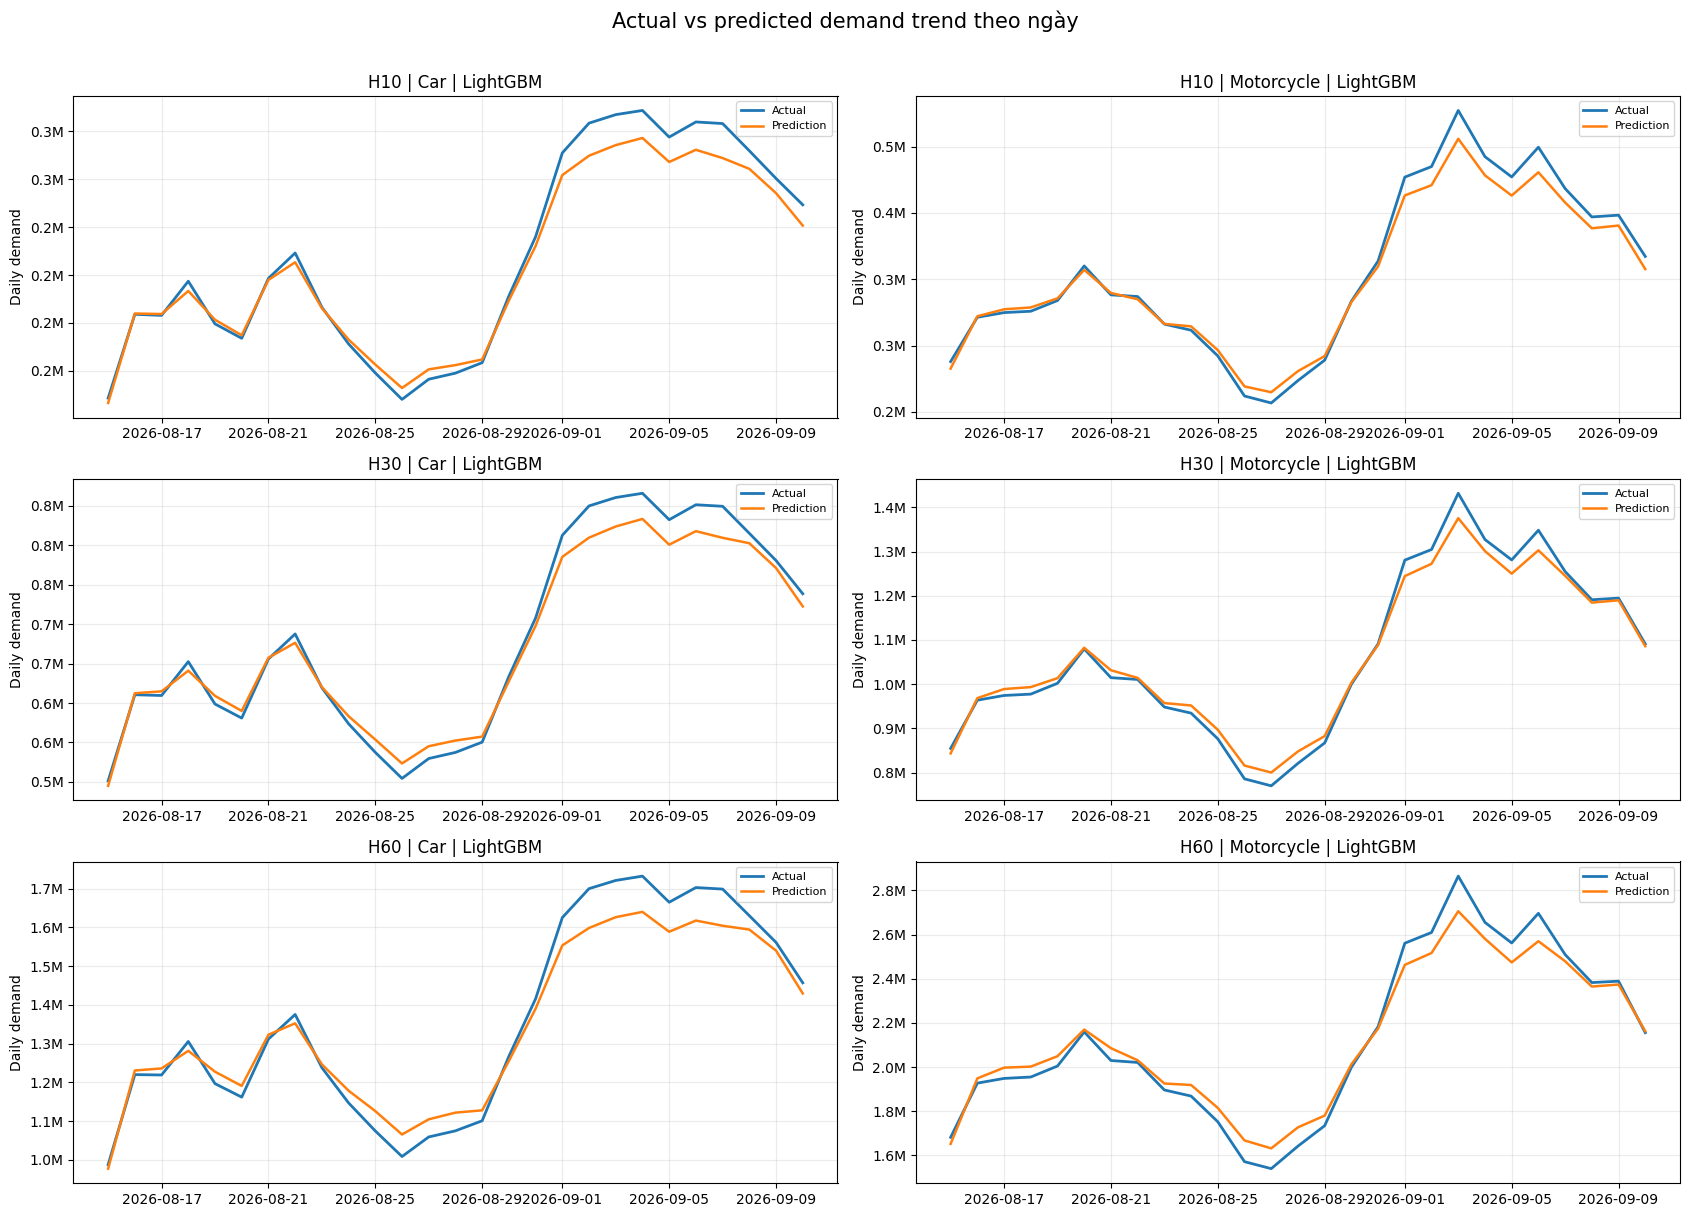

In [77]:
# ============================================================
# 5. DAILY DEMAND TREND
# ============================================================
trend_rows = []
DAILY_TREND = {}

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        daily = DAILY_DIAGNOSTICS[(horizon, mode)].copy()
        x = np.arange(len(daily), dtype="float64")

        actual_slope = (
            np.polyfit(x, daily["actual_volume"].to_numpy(), 1)[0]
            if len(daily) >= 2 else np.nan
        )
        prediction_slope = (
            np.polyfit(x, daily["predicted_volume"].to_numpy(), 1)[0]
            if len(daily) >= 2 else np.nan
        )
        actual_mean = daily["actual_volume"].mean()
        prediction_mean = daily["predicted_volume"].mean()
        window = min(7, max(1, len(daily) // 2))

        actual_first = daily["actual_volume"].head(window).mean()
        actual_last = daily["actual_volume"].tail(window).mean()
        prediction_first = daily["predicted_volume"].head(window).mean()
        prediction_last = daily["predicted_volume"].tail(window).mean()

        correlation = daily[["actual_volume", "predicted_volume"]].corr().iloc[0, 1]
        total_bias = 100.0 * safe_divide(
            daily["predicted_volume"].sum() - daily["actual_volume"].sum(),
            daily["actual_volume"].sum(),
        )

        daily["actual_index_100"] = 100.0 * daily["actual_volume"] / actual_first
        daily["prediction_index_100"] = 100.0 * daily["predicted_volume"] / prediction_first
        DAILY_TREND[(horizon, mode)] = daily

        trend_rows.append({
            "horizon": horizon,
            "travel_mode": mode,
            "model": selected_model_label(horizon),
            "days": len(daily),
            "actual_slope_%_per_day": 100.0 * safe_divide(actual_slope, actual_mean),
            "prediction_slope_%_per_day": 100.0 * safe_divide(prediction_slope, prediction_mean),
            "actual_change_first7_last7_%": 100.0 * safe_divide(actual_last - actual_first, actual_first),
            "prediction_change_first7_last7_%": 100.0 * safe_divide(
                prediction_last - prediction_first, prediction_first
            ),
            "daily_volume_correlation": correlation,
            "total_bias_%": total_bias,
        })

TREND_SUMMARY = pd.DataFrame(trend_rows)
display_rounded(TREND_SUMMARY, {
    "actual_slope_%_per_day": 3,
    "prediction_slope_%_per_day": 3,
    "actual_change_first7_last7_%": 2,
    "prediction_change_first7_last7_%": 2,
    "daily_volume_correlation": 4,
    "total_bias_%": 2,
})

fig, axes = plt.subplots(3, 2, figsize=(17, 12), sharex=False)
for row_index, horizon in enumerate(HORIZON_ORDER):
    for column_index, mode in enumerate(MODE_ORDER):
        ax = axes[row_index, column_index]
        daily = DAILY_TREND[(horizon, mode)]
        ax.plot(daily["date"], daily["actual_volume"], linewidth=2.0, label="Actual")
        ax.plot(daily["date"], daily["predicted_volume"], linewidth=1.8, label="Prediction")
        ax.set_title(f"{horizon} | {mode} | {selected_model_label(horizon)}")
        ax.set_ylabel("Daily demand")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1e6:.1f}M"))
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
fig.suptitle("Actual vs predicted demand trend theo ngày", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 6. Tóm tắt tự động và export kết quả

nhận xét ngắn cho từng horizon/mode và xuất các bảng diagnostics
thành CSV để dùng trực tiếp trong báo cáo.

In [78]:
# ============================================================
# 6. AUTO SUMMARY + EXPORT CSV
# ============================================================
def first_matching(table, horizon, mode, sort_column=None, ascending=False):
    subset = table.loc[
        (table["horizon"] == horizon) & (table["travel_mode"] == mode)
    ]
    if sort_column is not None:
        subset = subset.sort_values(sort_column, ascending=ascending)
    return None if subset.empty else subset.iloc[0]

print("=" * 72)
print("TÓM TẮT MODEL DIAGNOSTICS")
print("=" * 72)

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        overall = first_matching(ERROR_SUMMARY_SELECTED, horizon, mode)
        stability = first_matching(STABILITY_SUMMARY, horizon, mode)
        peak = first_matching(PEAK_PERFORMANCE, horizon, mode)
        weak_hour = first_matching(WEAK_HOURS, horizon, mode, "WMAPE_%")
        weak_hex = first_matching(WEAK_HEX, horizon, mode, "WMAPE_%")
        trend = first_matching(TREND_SUMMARY, horizon, mode)

        stability_note = "CẦN KIỂM TRA" if (
            stability["drift_alert"] or stability["cv_alert"]
        ) else "ổn định theo ngưỡng cấu hình"

        trend_direction = (
            "tăng" if trend["actual_slope_%_per_day"] > 0
            else "giảm" if trend["actual_slope_%_per_day"] < 0
            else "đi ngang"
        )

        print(f"\n{horizon} | {mode} | {selected_model_label(horizon)}")
        print(
            f"- Overall WMAPE: {overall['WMAPE_%']:.2f}% | "
            f"bias: {overall['bias_%']:+.2f}% | "
            f"underprediction: {overall['underprediction_rate_%']:.2f}%"
        )
        print(
            f"- Stability: {stability_note}; daily std "
            f"{stability['daily_WMAPE_std_pp']:.2f} pp; "
            f"drift đầu-cuối {stability['drift_pp']:+.2f} pp."
        )
        print(
            f"- Peak >= {peak['peak_threshold_P90']:.2f}: WMAPE "
            f"{peak['peak_WMAPE_%']:.2f}%; bias {peak['peak_bias_%']:+.2f}%; "
            f"recall {peak['peak_recall_%']:.2f}%."
        )
        if weak_hour is not None:
            print(
                f"- Weakest hour: {int(weak_hour['hour']):02d}:00 "
                f"(WMAPE {weak_hour['WMAPE_%']:.2f}%)."
            )
        else:
            print("- Weakest hour: chưa đủ số quan sát theo ngưỡng cấu hình.")

        if weak_hex is not None:
            print(
                f"- Weakest hex: {weak_hex['hex_id_7']} "
                f"(WMAPE {weak_hex['WMAPE_%']:.2f}%)."
            )
        else:
            print("- Weakest hex: chưa đủ số quan sát theo ngưỡng cấu hình.")
        print(
            f"- Actual trend: {trend_direction}, "
            f"{trend['actual_slope_%_per_day']:+.3f}%/ngày; "
            f"daily actual-prediction correlation "
            f"{trend['daily_volume_correlation']:.4f}."
        )

base_output = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
DIAGNOSTICS_OUTPUT_DIR = base_output / "model_diagnostics"
DIAGNOSTICS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

export_tables = {
    "error_summary_all_models.csv": ERROR_SUMMARY_ALL_MODELS,
    "error_by_demand_band.csv": ERROR_BY_DEMAND_BAND,
    "stability_summary.csv": STABILITY_SUMMARY,
    "peak_performance.csv": PEAK_PERFORMANCE,
    "top_peak_hours.csv": TOP_PEAK_HOURS,
    "top_peak_weekdays.csv": TOP_PEAK_WEEKDAYS,
    "top_peak_hex.csv": TOP_PEAK_HEX,
    "weak_hours.csv": WEAK_HOURS,
    "weak_weekdays.csv": WEAK_WEEKDAYS,
    "weak_hex.csv": WEAK_HEX,
    "worst_cases.csv": WORST_CASES,
    "peak_worst_cases.csv": PEAK_WORST_CASES,
    "trend_summary.csv": TREND_SUMMARY,
}

for filename, table in export_tables.items():
    table.to_csv(DIAGNOSTICS_OUTPUT_DIR / filename, index=False)

print(f"\nĐã export {len(export_tables)} bảng vào: {DIAGNOSTICS_OUTPUT_DIR}")

TÓM TẮT MODEL DIAGNOSTICS

H10 | Car | LightGBM
- Overall WMAPE: 15.63% | bias: -1.63% | underprediction: 49.81%
- Stability: ổn định theo ngưỡng cấu hình; daily std 0.73 pp; drift đầu-cuối -0.05 pp.
- Peak >= 26.00: WMAPE 15.10%; bias -4.50%; recall 88.66%.
- Weakest hour: 05:00 (WMAPE 21.13%).
- Weakest hex: 8765b1932ffffff (WMAPE 18.43%).
- Actual trend: tăng, +1.716%/ngày; daily actual-prediction correlation 0.9988.

H10 | Motorcycle | LightGBM
- Overall WMAPE: 14.66% | bias: -1.10% | underprediction: 47.66%
- Stability: ổn định theo ngưỡng cấu hình; daily std 0.50 pp; drift đầu-cuối -0.44 pp.
- Peak >= 50.00: WMAPE 13.14%; bias -3.84%; recall 89.10%.
- Weakest hour: 05:00 (WMAPE 20.28%).
- Weakest hex: 8765b562effffff (WMAPE 21.82%).
- Actual trend: tăng, +1.425%/ngày; daily actual-prediction correlation 0.9989.

H30 | Car | LightGBM
- Overall WMAPE: 16.32% | bias: -1.16% | underprediction: 47.70%
- Stability: ổn định theo ngưỡng cấu hình; daily std 0.80 pp; drift đầu-cuối -0.17 p